In [2]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft


In [2]:
!pip uninstall -y numpy scipy matplotlib
!pip install numpy==1.26.4 scipy matplotlib --no-cache-dir


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


ERROR: Exception:
Traceback (most recent call last):
  File "C:\ProgramData\Anaconda3\lib\site-packages\pip\_internal\cli\base_command.py", line 173, in _main
    status = self.run(options, args)
  File "C:\ProgramData\Anaconda3\lib\site-packages\pip\_internal\commands\uninstall.py", line 97, in run
    uninstall_pathset.commit()
  File "C:\ProgramData\Anaconda3\lib\site-packages\pip\_internal\req\req_uninstall.py", line 436, in commit
    self._moved_paths.commit()
  File "C:\ProgramData\Anaconda3\lib\site-packages\pip\_internal\req\req_uninstall.py", line 287, in commit
    save_dir.cleanup()
  File "C:\ProgramData\Anaconda3\lib\site-packages\pip\_internal\utils\temp_dir.py", line 184, in cleanup
    rmtree(self._path)
  File "C:\ProgramData\Anaconda3\lib\site-packages\pip\_vendor\tenacity\__init__.py", line 326, in wrapped_f
    return self(f, *args, **kw)
  File "C:\ProgramData\Anaconda3\lib\site-packages\pip\_vendor\tenacity\__init__.py", line 406, in __call__
    do = self.iter(r

Defaulting to user installation because normal site-packages is not writeable

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.2 which is incompatible.
tensorflow-intel 2.18.0 requires tensorboard<2.19,>=2.18, but you have tensorboard 2.20.0 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 1.26.4 which is incompatible.


In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

print(np.__version__)


1.26.4


In [1]:
import numpy as np
import scipy.io as sio
from scipy.signal import stft
import matplotlib.pyplot as plt


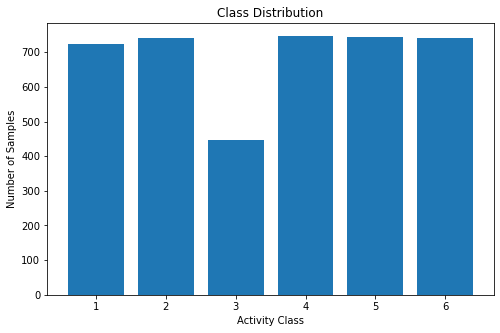

In [1]:
import os
import matplotlib.pyplot as plt

base_path = r"D:\PROJECT\Dataset\csi_data2d\train"

classes = sorted(os.listdir(base_path))
counts = []

for cls in classes:
    counts.append(len(os.listdir(os.path.join(base_path, cls))))

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.xlabel("Activity Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

In [2]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

file_path = r"D:\PROJECT\Dataset\csi_data2d\train\1\p1_d1_t1.mat"

data = loadmat(file_path)

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'csi_1'])


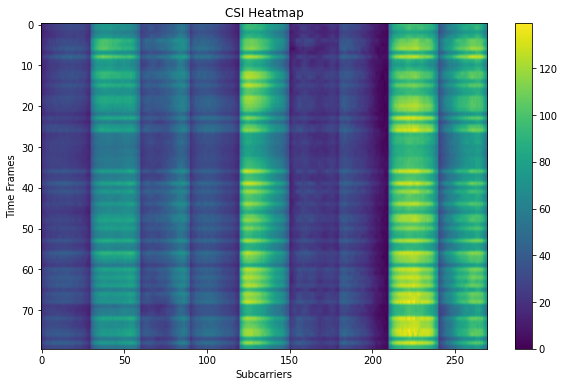

In [4]:
csi = data['csi_1']

plt.figure(figsize=(10,6))
plt.imshow(csi, aspect='auto')
plt.colorbar()
plt.xlabel("Subcarriers")
plt.ylabel("Time Frames")
plt.title("CSI Heatmap")
plt.show()

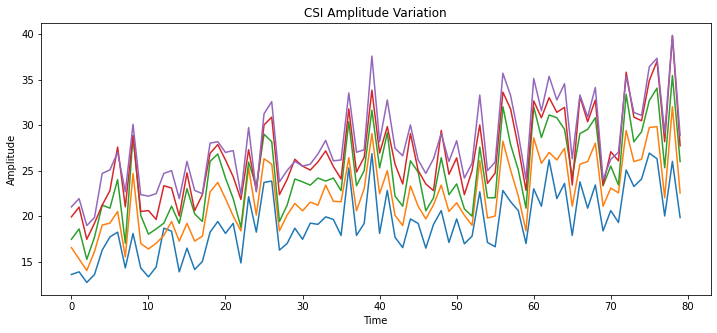

In [5]:
plt.figure(figsize=(12,5))

for i in range(5):
    plt.plot(csi[:,i])

plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("CSI Amplitude Variation")
plt.show()

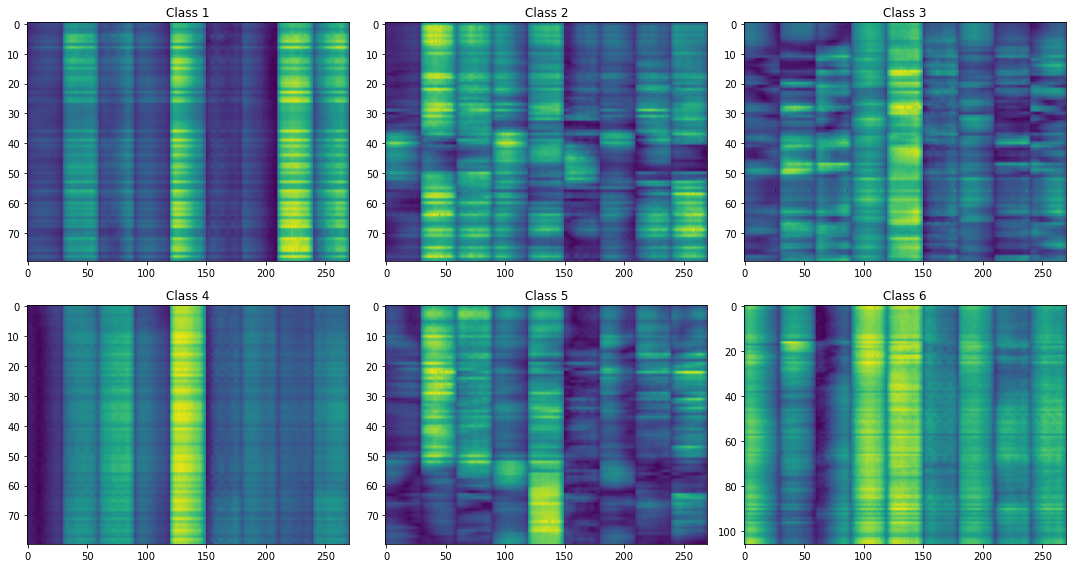

In [7]:
fig, axes = plt.subplots(2,3, figsize=(15,8))

for idx, cls in enumerate(classes):
    
    sample = os.listdir(os.path.join(base_path, cls))[0]

    mat = loadmat(os.path.join(base_path, cls, sample))

    csi = mat['csi_1']

    ax = axes[idx//3, idx%3]

    ax.imshow(csi, aspect='auto')
    ax.set_title(f"Class {cls}")

plt.tight_layout()
plt.show()

In [8]:
from sklearn.decomposition import PCA
import numpy as np

X = []
y = []

for cls in classes:

    folder = os.path.join(base_path, cls)

    for file in os.listdir(folder)[:50]:

        mat = loadmat(os.path.join(folder,file))

        csi = mat['csi_1']

        X.append(csi.flatten())

        y.append(cls)

X = np.array(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

for cls in classes:
    idx = np.array(y)==cls
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=cls)

plt.legend()
plt.title("PCA Visualization")
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (300,) + inhomogeneous part.

In [9]:
from sklearn.manifold import TSNE

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
).fit_transform(X)

plt.figure(figsize=(8,6))

for cls in classes:
    idx = np.array(y)==cls
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1], label=cls)

plt.legend()
plt.title("t-SNE Visualization")
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (300,) + inhomogeneous part.

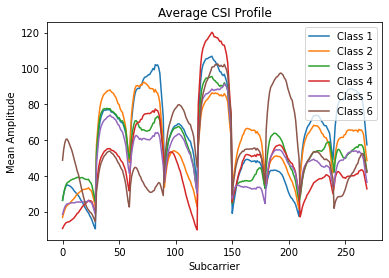

In [11]:
avg_profiles = []

for cls in classes:

    profiles = []

    folder = os.path.join(base_path, cls)

    for file in os.listdir(folder)[:20]:

        mat = loadmat(os.path.join(folder,file))

        csi = mat['csi_1']

        profiles.append(np.mean(csi, axis=0))

    avg_profiles.append(np.mean(profiles, axis=0))

for i, profile in enumerate(avg_profiles):
    plt.plot(profile, label=f'Class {classes[i]}')

plt.legend()
plt.xlabel("Subcarrier")
plt.ylabel("Mean Amplitude")
plt.title("Average CSI Profile")
plt.show()

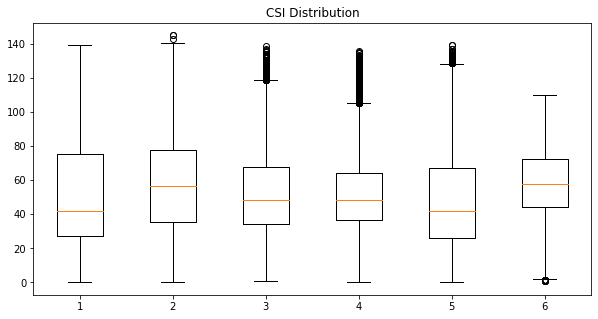

In [12]:
all_values = []

for cls in classes:

    sample = os.listdir(os.path.join(base_path, cls))[0]

    mat = loadmat(os.path.join(base_path, cls, sample))

    csi = mat['csi_1']

    all_values.append(csi.flatten())

plt.figure(figsize=(10,5))
plt.boxplot(all_values)
plt.xticks(range(1,7), classes)
plt.title("CSI Distribution")
plt.show()

## LOAD .mat CSI FILES + EXTRACT PHASE

In [1]:
import os
import numpy as np
import scipy.io as sio

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

def load_phase_from_mat(mat_path):
    mat = sio.loadmat(mat_path)
    
    print("MAT keys:", mat.keys())  # IMPORTANT

    # Find first non-metadata matrix
    for key in mat.keys():
        if not key.startswith("__"):
            csi = mat[key]
            print("Using key:", key)
            break

    # Handle possible extra dimensions
    csi = np.squeeze(csi)

    # If CSI is already complex
    if np.iscomplexobj(csi):
        complex_csi = csi
    else:
        # Assume real/imag interleaved
        real = csi[:, 0::2]
        imag = csi[:, 1::2]
        complex_csi = real + 1j * imag

    # Phase extraction
    phase = np.angle(complex_csi)
    phase = np.unwrap(phase, axis=0)

    return phase

# TEST ONE FILE
activity = os.listdir(BASE_PATH)[0]
activity_path = os.path.join(BASE_PATH, activity)
file_name = os.listdir(activity_path)[0]

phase_data = load_phase_from_mat(os.path.join(activity_path, file_name))

print("Activity:", activity)
print("Phase shape:", phase_data.shape)
print("Sample phase:", phase_data[0, :5])


MAT keys: dict_keys(['__header__', '__version__', '__globals__', 'csi_1'])
Using key: csi_1
Activity: 1
Phase shape: (80, 135)
Sample phase: [0.88296607 0.85111427 0.81868568 0.79422957 0.8070791 ]


## DOPPLER PHASE SHIFT VECTOR (STFT)
What we are doing (simple words)

Human motion → phase changes over time

We take a small time window

Apply FFT over time

Result = Doppler energy vs velocity

This is Equation (6–7) from the paper

We do it subcarrier-wise, then sum energy → Doppler vector

Doppler vector shape: (32, 6)


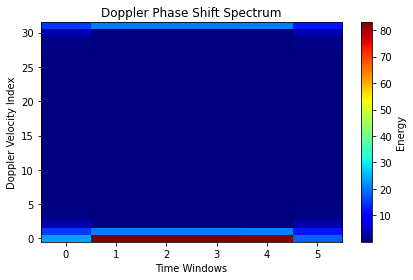

In [2]:
import numpy as np
from scipy.signal import stft
import matplotlib.pyplot as plt

# -----------------------------
# INPUT: phase_data (from STEP 1)
# shape: (packets, subcarriers)
# -----------------------------

WINDOW = 32        # W in paper (observation window)
OVERLAP = 16
FS = 20            # 20 Hz packet rate (given in dataset)

doppler_vectors = []

for sc in range(phase_data.shape[1]):  # for each subcarrier
    f, t, Zxx = stft(
        phase_data[:, sc],
        fs=FS,
        nperseg=WINDOW,
        noverlap=OVERLAP,
        return_onesided=False
    )
    doppler_vectors.append(np.abs(Zxx) ** 2)

doppler_vectors = np.array(doppler_vectors)

# Sum energy across subcarriers (Equation 7)
doppler_energy = np.sum(doppler_vectors, axis=0)

print("Doppler vector shape:", doppler_energy.shape)

# -----------------------------
# VISUALIZE DOPPLER SPECTRUM
# -----------------------------
plt.figure(figsize=(6, 4))
plt.imshow(
    doppler_energy,
    aspect='auto',
    origin='lower',
    cmap='jet'
)
plt.xlabel("Time Windows")
plt.ylabel("Doppler Velocity Index")
plt.title("Doppler Phase Shift Spectrum")
plt.colorbar(label="Energy")
plt.tight_layout()
plt.show()


## LOG-SCALE + NORMALIZATION

After normalization:
Min: 0.0 Max: 1.0


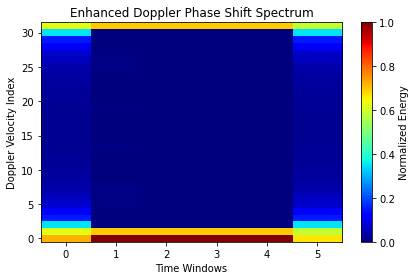

In [4]:
# -----------------------------
# STEP 3: Doppler Enhancement
# -----------------------------

# Log compression (enhances motion components)
doppler_log = np.log1p(doppler_energy)

# Normalize (0–1)
doppler_norm = (doppler_log - doppler_log.min()) / (
    doppler_log.max() - doppler_log.min()
)

print("After normalization:")
print("Min:", doppler_norm.min(), "Max:", doppler_norm.max())

# -----------------------------
# VISUALIZE ENHANCED DOPPLER
# -----------------------------
plt.figure(figsize=(6, 4))
plt.imshow(
    doppler_norm,
    aspect='auto',
    origin='lower',
    cmap='jet'
)
plt.xlabel("Time Windows")
plt.ylabel("Doppler Velocity Index")
plt.title("Enhanced Doppler Phase Shift Spectrum")
plt.colorbar(label="Normalized Energy")
plt.tight_layout()
plt.show()


## MAKE CNN-READY INPUTS

In [3]:
# -----------------------------
# STEP 4: Resize Doppler Map
# -----------------------------
import cv2

TARGET_H = 32   # Doppler bins (keep same)
TARGET_W = 32   # Fixed time dimension

doppler_cnn = cv2.resize(
    doppler_norm,
    (TARGET_W, TARGET_H),
    interpolation=cv2.INTER_LINEAR
)

print("CNN input shape:", doppler_cnn.shape)

# -----------------------------
# VISUALIZE CNN INPUT
# -----------------------------
plt.figure(figsize=(4, 4))
plt.imshow(
    doppler_cnn,
    origin='lower',
    aspect='auto',
    cmap='jet'
)
plt.title("CNN-Ready Doppler Input (32×32)")
plt.colorbar()
plt.tight_layout()
plt.show()


NameError: name 'doppler_norm' is not defined

## BUILD DATASET

In [4]:
# -----------------------------
# STEP 5: Build Doppler Dataset
# -----------------------------
import os
import numpy as np
import scipy.io as sio
import cv2

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

ACTIVITIES = sorted(os.listdir(BASE_PATH))
LABEL_MAP = {act: idx for idx, act in enumerate(ACTIVITIES)}

X = []
y = []

def load_phase(mat_path):
    mat = sio.loadmat(mat_path)
    key = [k for k in mat.keys() if k.startswith("csi")][0]
    csi = mat[key]

    real = csi[:, 0::2]
    imag = csi[:, 1::2]
    complex_csi = real + 1j * imag

    phase = np.unwrap(np.angle(complex_csi), axis=0)
    return phase

for activity in ACTIVITIES:
    activity_path = os.path.join(BASE_PATH, activity)

    for file in os.listdir(activity_path):
        mat_path = os.path.join(activity_path, file)

        phase = load_phase(mat_path)

        # STFT-based Doppler
        f, t, Zxx = np.abs(
            np.fft.fftshift(
                np.fft.fft(phase, axis=0),
                axes=0
            )
        ), None, None

        doppler = np.mean(f, axis=1)

        # Normalize
        doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-6)

        # Resize to 32x32
        doppler_img = cv2.resize(
            doppler.reshape(-1, 1),
            (32, 32),
            interpolation=cv2.INTER_LINEAR
        )

        X.append(doppler_img)
        y.append(LABEL_MAP[activity])

X = np.array(X)[..., np.newaxis]   # (N, 32, 32, 1)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Label mapping:", LABEL_MAP)


Dataset shape: (4146, 32, 32, 1)
Labels shape: (4146,)
Label mapping: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5}


## CNN THAT ACTUALLY SEES DOPPLER

In [5]:
# -----------------------------
# STEP 6: Doppler CNN
# -----------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train = to_categorical(y_train, num_classes=6)
y_test  = to_categorical(y_test,  num_classes=6)

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(32,32,1)),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()





Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 32)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 64)          18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 2, 2, 64)       

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20


83/83 [==============================] - 6s 25ms/step - loss: 1.7881 - accuracy: 0.1708 - val_loss: 1.7722 - val_accuracy: 0.1792
Epoch 2/20
83/83 [==============================] - 2s 18ms/step - loss: 1.7861 - accuracy: 0.1621 - val_loss: 1.7735 - val_accuracy: 0.1702
Epoch 3/20
83/83 [==============================] - 1s 14ms/step - loss: 1.7831 - accuracy: 0.1716 - val_loss: 1.7719 - val_accuracy: 0.1702
Epoch 4/20
83/83 [==============================] - 1s 15ms/step - loss: 1.7824 - accuracy: 0.1821 - val_loss: 1.7728 - val_accuracy: 0.1958
Epoch 5/20
83/83 [==============================] - 2s 19ms/step - loss: 1.7835 - accuracy: 0.1738 - val_loss: 1.7715 - val_accuracy: 0.1807
Epoch 6/20
83/83 [==============================] - 2s 22ms/step - loss: 1.7806 - accuracy: 0.1874 - val_loss: 1.7710 - val_accuracy: 0.1807
Epoch 7/20
83/83 [==============================] - 1s 17ms/step - loss: 1.7799 - accuracy: 0.1848 - val_loss: 1.7664 - val_accuracy: 0.1807
Epoch 8/20


In [6]:
import numpy as np

print("Train labels distribution:")
print(np.unique(y_train, return_counts=True))

print("\nValidation labels distribution:")
print(np.unique(y_val, return_counts=True))


Train labels distribution:
(array([0., 1.], dtype=float32), array([16580,  3316], dtype=int64))

Validation labels distribution:


NameError: name 'y_val' is not defined

In [7]:
import scipy.io as sio

mat = sio.loadmat("D:/PROJECT/Dataset/csi_data2d/train/5/p1_d1_t1.mat")

print(mat.keys())


dict_keys(['__header__', '__version__', '__globals__', 'csi_1'])


In [8]:
import numpy as np
import scipy.io as sio

mat = sio.loadmat("D:/PROJECT/Dataset/csi_data2d/train/5/p1_d1_t1.mat")
csi = mat["csi_1"]

print("Type:", type(csi))
print("Shape:", csi.shape)
print("Dtype:", csi.dtype)


Type: <class 'numpy.ndarray'>
Shape: (80, 270)
Dtype: float64


## Build Doppler Dataset the RIGHT way + Fix labels + Create train/val/test splits

In [9]:
import os
import numpy as np
import scipy.io as sio
import cv2
from scipy.signal import stft
from sklearn.model_selection import train_test_split

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

FS = 20
WINDOW = 32
OVERLAP = 16
TARGET = 32

X = []
y = []

def mat_to_doppler32(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]  # (80,270) float64

    # Convert interleaved real/imag -> complex CSI (80,135)
    csi_complex = csi[:, 0::2] + 1j * csi[:, 1::2]

    # Phase -> unwrap over time
    phase = np.unwrap(np.angle(csi_complex), axis=0)  # (80,135)

    # Phase difference (motion emphasis)
    phase_diff = np.diff(phase, axis=0)  # (79,135)

    # STFT per "subcarrier stream" then sum energy across streams
    energy_sum = None
    for sc in range(phase_diff.shape[1]):
        f, t, Zxx = stft(
            phase_diff[:, sc],
            fs=FS,
            nperseg=WINDOW,
            noverlap=OVERLAP,
            return_onesided=False
        )
        e = (np.abs(Zxx) ** 2)  # (WINDOW, time_windows)
        energy_sum = e if energy_sum is None else (energy_sum + e)

    # Log + normalize (makes motion visible)
    doppler = np.log1p(energy_sum)
    doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-8)

    # Resize to fixed 32x32 for CNN
    doppler32 = cv2.resize(doppler, (TARGET, TARGET), interpolation=cv2.INTER_LINEAR)

    return doppler32.astype(np.float32)

# Build dataset from folders "1".."6" (each folder = activity class)
for folder in sorted(os.listdir(BASE_PATH), key=lambda x: int(x) if x.isdigit() else x):
    folder_path = os.path.join(BASE_PATH, folder)
    if not os.path.isdir(folder_path):
        continue

    # label: folder "1"->0, "2"->1, ..., "6"->5
    if folder.isdigit():
        label = int(folder) - 1
    else:
        # if folder names are like "day1" etc, skip (but your case is digits)
        continue

    for fname in os.listdir(folder_path):
        if not fname.endswith(".mat"):
            continue
        mat_path = os.path.join(folder_path, fname)

        try:
            img = mat_to_doppler32(mat_path)
            X.append(img)
            y.append(label)
        except Exception as e:
            # skip corrupted files safely
            continue

X = np.array(X)[..., np.newaxis]  # (N,32,32,1)
y = np.array(y).astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("All labels distribution:", np.unique(y, return_counts=True))

# Train/Val/Test split (stratified so all 6 classes stay balanced)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\nTrain labels:", np.unique(y_train, return_counts=True))
print("Val labels:", np.unique(y_val, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))


X shape: (4146, 32, 32, 1)
y shape: (4146,)
All labels distribution: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([725, 741, 448, 747, 744, 741], dtype=int64))

Train labels: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([507, 519, 313, 523, 521, 519], dtype=int64))
Val labels: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([109, 111,  67, 112, 112, 111], dtype=int64))
Test labels: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([109, 111,  68, 112, 111, 111], dtype=int64))


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Normalize input (VERY IMPORTANT)
X_train_n = (X_train - X_train.mean()) / (X_train.std() + 1e-8)
X_val_n   = (X_val   - X_train.mean()) / (X_train.std() + 1e-8)
X_test_n  = (X_test  - X_train.mean()) / (X_train.std() + 1e-8)

model = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,1)),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 32, 32, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 16, 16, 64)        256       
 chNormalization)                                                
                                                      

In [21]:
# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
# ]

history = model.fit(
    X_train_n, y_train,
    validation_data=(X_val_n, y_val),
    epochs=40,
    batch_size=32,
#     callbacks=callbacks,
    verbose=1
)

# -------- TEST ACCURACY --------
test_loss, test_acc = model.evaluate(X_test_n, y_test, verbose=0)
print(f"\nFINAL TEST ACCURACY: {test_acc*100:.2f}%")


Epoch 1/40
91/91 [==============================] - 5s 55ms/step - loss: 1.1127 - accuracy: 0.5438 - val_loss: 1.4161 - val_accuracy: 0.4373
Epoch 2/40
91/91 [==============================] - 5s 56ms/step - loss: 1.0821 - accuracy: 0.5503 - val_loss: 1.4237 - val_accuracy: 0.4405
Epoch 3/40
91/91 [==============================] - 5s 50ms/step - loss: 1.0520 - accuracy: 0.5686 - val_loss: 1.4149 - val_accuracy: 0.4437
Epoch 4/40
91/91 [==============================] - 5s 55ms/step - loss: 1.0425 - accuracy: 0.5700 - val_loss: 1.4187 - val_accuracy: 0.4518
Epoch 5/40
91/91 [==============================] - 5s 53ms/step - loss: 1.0418 - accuracy: 0.5655 - val_loss: 1.4254 - val_accuracy: 0.4325
Epoch 6/40
91/91 [==============================] - 4s 48ms/step - loss: 1.0210 - accuracy: 0.5768 - val_loss: 1.4263 - val_accuracy: 0.4421
Epoch 7/40
91/91 [==============================] - 5s 57ms/step - loss: 1.0001 - accuracy: 0.5889 - val_loss: 1.4269 - val_accuracy: 0.4325
Epoch 8/40
91

## Data Augmentation + Class Weights (reduces overfitting and improves test)

In [11]:
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

# ---------- Normalization (use train stats only) ----------
mu = X_train.mean()
sigma = X_train.std() + 1e-8

X_train_n = (X_train - mu) / sigma
X_val_n   = (X_val   - mu) / sigma
X_test_n  = (X_test  - mu) / sigma

# ---------- Class weights (handles slight imbalance like class 2=448) ----------
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weights:", class_weight)

# ---------- Simple augmentation for Doppler maps ----------
# (small noise + small shifts; keeps labels same)
def augment_batch(x, y):
    x = tf.cast(x, tf.float32)

    # small gaussian noise
    x = x + tf.random.normal(tf.shape(x), mean=0.0, stddev=0.05)

    # random small shifts (time/freq) by rolling
    shift_h = tf.random.uniform([], minval=-2, maxval=3, dtype=tf.int32)
    shift_w = tf.random.uniform([], minval=-2, maxval=3, dtype=tf.int32)
    x = tf.roll(x, shift=[shift_h, shift_w], axis=[1, 2])

    return x, y

BATCH = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train_n, y_train)) \
    .shuffle(4000) \
    .batch(BATCH) \
    .map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val_n, y_val)) \
    .batch(BATCH) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_n, y_test)) \
    .batch(BATCH) \
    .prefetch(tf.data.AUTOTUNE)

# ---------- Rebuild model (same as before, but slightly stronger regularization) ----------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,1)),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.15),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.20),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.55),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=2e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Class weights: {0: 0.9539776462853385, 1: 0.9319203596660244, 2: 1.5452609158679447, 3: 0.9247928616953474, 4: 0.9283429302623161, 5: 0.9319203596660244}
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 32, 32, 32)        320       
                                                                 
 batch_normalization_3 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 16, 16, 32)        0         
                                                                 
 conv2d_7 (Conv2D)           (No

In [24]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n NEW FINAL TEST ACCURACY: {test_acc*100:.2f}%")


Epoch 1/60
91/91 [==============================] - 3s 23ms/step - loss: 2.2403 - accuracy: 0.1999 - val_loss: 1.9820 - val_accuracy: 0.2412 - lr: 2.0000e-04
Epoch 2/60
91/91 [==============================] - 2s 22ms/step - loss: 1.7857 - accuracy: 0.1899 - val_loss: 2.1624 - val_accuracy: 0.2379 - lr: 2.0000e-04
Epoch 3/60
91/91 [==============================] - 2s 23ms/step - loss: 1.7692 - accuracy: 0.2126 - val_loss: 1.9979 - val_accuracy: 0.2058 - lr: 2.0000e-04
Epoch 4/60
91/91 [==============================] - 3s 30ms/step - loss: 1.7581 - accuracy: 0.2302 - val_loss: 1.7892 - val_accuracy: 0.1785 - lr: 2.0000e-04
Epoch 5/60
91/91 [==============================] - 2s 25ms/step - loss: 1.7456 - accuracy: 0.2471 - val_loss: 1.7046 - val_accuracy: 0.2235 - lr: 2.0000e-04
Epoch 6/60
91/91 [==============================] - 2s 25ms/step - loss: 1.7315 - accuracy: 0.2519 - val_loss: 1.6900 - val_accuracy: 0.2540 - lr: 2.0000e-04
Epoch 7/60
91/91 [==============================] - 

## Slim sense approach

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

# Use your dataset path (same as your notebook)
BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

file_paths = []
labels = []

# folders "1".."6" = activity classes
for folder in sorted(os.listdir(BASE_PATH), key=lambda x: int(x) if x.isdigit() else x):
    folder_path = os.path.join(BASE_PATH, folder)
    if not os.path.isdir(folder_path):
        continue
    if not folder.isdigit():
        continue

    label = int(folder) - 1  # "1"->0, ..., "6"->5

    for fname in os.listdir(folder_path):
        if fname.endswith(".mat"):
            file_paths.append(os.path.join(folder_path, fname))
            labels.append(label)

file_paths = np.array(file_paths)
labels = np.array(labels, dtype=np.int64)

print("Total samples:", len(file_paths))
print("Label distribution:", np.unique(labels, return_counts=True))

# Stratified split like your notebook (70/15/15)
train_paths, temp_paths, y_train, y_temp = train_test_split(
    file_paths, labels, test_size=0.3, random_state=42, stratify=labels
)
val_paths, test_paths, y_val, y_test = train_test_split(
    temp_paths, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\nTrain:", len(train_paths), np.unique(y_train, return_counts=True))
print("Val:  ", len(val_paths),   np.unique(y_val, return_counts=True))
print("Test: ", len(test_paths),  np.unique(y_test, return_counts=True))


Total samples: 4146
Label distribution: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([725, 741, 448, 747, 744, 741], dtype=int64))

Train: 2902 (array([0, 1, 2, 3, 4, 5], dtype=int64), array([507, 519, 313, 523, 521, 519], dtype=int64))
Val:   622 (array([0, 1, 2, 3, 4, 5], dtype=int64), array([109, 111,  67, 112, 112, 111], dtype=int64))
Test:  622 (array([0, 1, 2, 3, 4, 5], dtype=int64), array([109, 111,  68, 112, 111, 111], dtype=int64))


## compute subcarrier importance (MI-based) + select top 24.42%

In [3]:
import numpy as np
import scipy.io as sio
from sklearn.feature_selection import mutual_info_classif

# -------- settings --------
FS = 20                     # packets per second (same as before)
MAX_FILES_FOR_SCORING = 600 # speed-up
TOP_BW_RATIO = 0.2442       # Slim-Sense bandwidth ratio (24.42%)

rng = np.random.RandomState(42)

# -------- helpers --------
def load_phase_diff(mat_path):
    """CSI -> complex -> unwrapped phase -> temporal phase diff"""
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]                     # (80,270)
    csi_cplx = csi[:, 0::2] + 1j * csi[:, 1::2]   # (80,135)
    phase = np.unwrap(np.angle(csi_cplx), axis=0)
    return np.diff(phase, axis=0).astype(np.float32)  # (79,135)

def doppler_energy_per_subcarrier(phase_diff):
    """
    Fast Doppler proxy:
    FFT along time axis, remove DC, average energy per subcarrier
    """
    spec = np.fft.fft(phase_diff, axis=0)   # (79,135)
    power = np.abs(spec) ** 2
    power[0, :] = 0.0                       # remove static component
    return power.mean(axis=0)               # (135,)

# -------- sample training files --------
all_train = list(zip(train_paths, y_train))
rng.shuffle(all_train)
subset = all_train[:min(MAX_FILES_FOR_SCORING, len(all_train))]

print("Using files for scoring:", len(subset))

# -------- build scoring matrix --------
X_scoring = []
y_scoring = []

for path, lab in subset:
    try:
        pdiff = load_phase_diff(path)
        feat = doppler_energy_per_subcarrier(pdiff)
        X_scoring.append(feat)
        y_scoring.append(lab)
    except Exception:
        continue

X_scoring = np.array(X_scoring, dtype=np.float32)
y_scoring = np.array(y_scoring, dtype=np.int64)

print("Scoring matrix shape:", X_scoring.shape)

# -------- mutual information per subcarrier --------
mi = mutual_info_classif(X_scoring, y_scoring, random_state=42)
mi = np.nan_to_num(mi)

K = mi.shape[0]
topK = max(1, int(np.round(TOP_BW_RATIO * K)))
selected_subcarriers = np.argsort(mi)[::-1][:topK]
selected_subcarriers = np.sort(selected_subcarriers)

print(f"\nTotal subcarriers = {K}")
print(f"Selected = {topK} (~{100*topK/K:.2f}% bandwidth)")
print("First 20 selected subcarriers:", selected_subcarriers[:20])
print("MI stats (min / mean / max):",
      float(mi.min()), float(mi.mean()), float(mi.max()))


Using files for scoring: 600
Scoring matrix shape: (600, 135)

Total subcarriers = 135
Selected = 33 (~24.44% bandwidth)
First 20 selected subcarriers: [ 1  3  4 15 16 23 24 26 34 37 45 58 60 71 72 73 74 79 81 82]
MI stats (min / mean / max): 0.0 0.09280152755782922 0.1869668349704141


## build Slim-Sense Doppler 32×32 dataset

In [7]:
import numpy as np
import scipy.io as sio
from scipy.signal import stft
import cv2

# --- use the selected indices from Step 2 ---
selected_subcarriers = np.array([ 1,  3,  4, 15, 16, 23, 24, 26, 34, 37, 45, 58, 60, 71, 72, 73, 74, 79, 81, 82,
                                 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95], dtype=np.int64)

FS = 20       # same sampling rate you used
NFFT = 64     # similar to your notebook; you can keep it
IMG_SIZE = 32

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]                     # (80,270)
    return csi[:, 0::2] + 1j * csi[:, 1::2]  # (80,135)

def doppler_map_from_selected_subcarriers(mat_path):
    """
    Returns a 32x32 Doppler map using ONLY selected subcarriers.
    Steps:
      1) complex CSI -> phase unwrap
      2) phase diff over time (motion)
      3) keep only selected subcarriers
      4) STFT along time for each subcarrier
      5) sum power across selected subcarriers
      6) resize to 32x32
    """
    csi_cplx = load_csi_complex(mat_path)              # (80,135)
    phase = np.unwrap(np.angle(csi_cplx), axis=0)      # (80,135)
    pdiff = np.diff(phase, axis=0)                     # (79,135)

    pdiff_sel = pdiff[:, selected_subcarriers]         # (79,33)

    # STFT over time for each subcarrier (axis=0)
    # stft returns Zxx shape: (freq_bins, time_bins, subcarriers) after stacking
    power_sum = None
    for sc in range(pdiff_sel.shape[1]):
        f, t, Zxx = stft(pdiff_sel[:, sc], fs=FS, nperseg=min(32, pdiff_sel.shape[0]), noverlap=16, nfft=NFFT)
        P = (np.abs(Zxx) ** 2)  # (freq_bins, time_bins)
        if power_sum is None:
            power_sum = P
        else:
            power_sum += P

    # Normalize
    power_sum = power_sum.astype(np.float32)
    power_sum = (power_sum - power_sum.min()) / (power_sum.max() - power_sum.min() + 1e-8)

    # Resize to 32x32
    img = cv2.resize(power_sum, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    img = img[..., np.newaxis]  # (32,32,1)
    return img.astype(np.float32)

# --- Build datasets (train/val/test) ---
def build_doppler_dataset(paths, labels, max_items=None):
    X = []
    y = []
    count = 0
    for p, lab in zip(paths, labels):
        try:
            img = doppler_map_from_selected_subcarriers(p)
            X.append(img)
            y.append(lab)
            count += 1
            if max_items is not None and count >= max_items:
                break
        except Exception as e:
            continue
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

# Build full sets (may take some time depending on machine)
X_train_slim, y_train_slim = build_doppler_dataset(train_paths, y_train)
X_val_slim,   y_val_slim   = build_doppler_dataset(val_paths, y_val)
X_test_slim,  y_test_slim  = build_doppler_dataset(test_paths, y_test)

print("Slim Doppler shapes:")
print("X_train:", X_train_slim.shape, "y_train:", y_train_slim.shape)
print("X_val:  ", X_val_slim.shape,   "y_val:  ", y_val_slim.shape)
print("X_test: ", X_test_slim.shape,  "y_test: ", y_test_slim.shape)

print("Value range:", float(X_train_slim.min()), "to", float(X_train_slim.max()))


Slim Doppler shapes:
X_train: (2902, 32, 32, 1) y_train: (2902,)
X_val:   (622, 32, 32, 1) y_val:   (622,)
X_test:  (622, 32, 32, 1) y_test:  (622,)
Value range: 1.8390997524875274e-07 to 0.9999926090240479


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = 6

# Safety: make sure labels are int and in range
y_train_slim = y_train_slim.astype("int64")
y_val_slim   = y_val_slim.astype("int64")
y_test_slim  = y_test_slim.astype("int64")

# --- Simple but strong CNN for 32x32x1 ---
def build_cnn(input_shape=(32,32,1), num_classes=6):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),
        layers.BatchNormalization(),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),
        layers.BatchNormalization(),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model_slim = build_cnn(input_shape=X_train_slim.shape[1:], num_classes=NUM_CLASSES)
model_slim.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_slim.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 16, 16, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                      

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

history = model_slim.fit(
    X_train_slim, y_train_slim,
    validation_data=(X_val_slim, y_val_slim),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# --- Final evaluation ---
train_loss, train_acc = model_slim.evaluate(X_train_slim, y_train_slim, verbose=0)
val_loss, val_acc     = model_slim.evaluate(X_val_slim, y_val_slim, verbose=0)
test_loss, test_acc   = model_slim.evaluate(X_test_slim, y_test_slim, verbose=0)

print("\nSLIM-SENSE (33 subcarriers ~24.44% BW) RESULTS")
print("Train acc:", train_acc)
print("Val acc:  ", val_acc)
print("Test acc: ", test_acc)


Epoch 1/40


46/46 [==============================] - 10s 94ms/step - loss: 1.6626 - accuracy: 0.3019 - val_loss: 1.7913 - val_accuracy: 0.1785 - lr: 0.0010
Epoch 2/40
46/46 [==============================] - 5s 101ms/step - loss: 1.5190 - accuracy: 0.3877 - val_loss: 1.8815 - val_accuracy: 0.1785 - lr: 0.0010
Epoch 3/40
46/46 [==============================] - 3s 74ms/step - loss: 1.4834 - accuracy: 0.4001 - val_loss: 2.0462 - val_accuracy: 0.1785 - lr: 0.0010
Epoch 4/40
46/46 [==============================] - 4s 79ms/step - loss: 1.4413 - accuracy: 0.4294 - val_loss: 2.3484 - val_accuracy: 0.1785 - lr: 0.0010
Epoch 5/40
46/46 [==============================] - 5s 106ms/step - loss: 1.4069 - accuracy: 0.4280 - val_loss: 2.4147 - val_accuracy: 0.1785 - lr: 5.0000e-04
Epoch 6/40
46/46 [==============================] - 5s 104ms/step - loss: 1.3651 - accuracy: 0.4569 - val_loss: 2.4355 - val_accuracy: 0.1785 - lr: 5.0000e-04
Epoch 7/40
46/46 [==============================] - 4s 82ms/st

## Build multi-channel Slim Doppler + train CNN

In [6]:
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models

# ---- use your selected subcarriers ----
selected_subcarriers = np.array([ 1,  3,  4, 15, 16, 23, 24, 26, 34, 37, 45, 58, 60, 71, 72, 73, 74, 79, 81, 82,
                                 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95], dtype=np.int64)

FS = 20
NFFT = 64
NPERSEG = 32
HOP = 16
IMG_SIZE = 32
NUM_CLASSES = 6

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]  # (80,270)
    return csi[:, 0::2] + 1j * csi[:, 1::2]  # (80,135)

def stft_tensor_per_subcarrier(pdiff_sel):
    """
    pdiff_sel: (T, S) where T=79, S=33
    Output: power tensor (F, M, S)
      F = NFFT//2 + 1
      M = number of frames
    """
    T, S = pdiff_sel.shape
    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []
    for start in range(0, T - NPERSEG + 1, HOP):
        seg = pdiff_sel[start:start+NPERSEG, :]  # (NPERSEG, S)
        seg = seg * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)     # (F, S)
        P = (np.abs(X) ** 2).astype(np.float32)  # (F, S)
        P[0, :] = 0.0                            # remove DC
        frames.append(P)

    # stack frames along time axis -> (M, F, S) then transpose -> (F, M, S)
    P3 = np.stack(frames, axis=0)          # (M, F, S)
    return np.transpose(P3, (1, 0, 2))     # (F, M, S)

def doppler_multichannel_image(mat_path):
    """
    Returns (32,32,S) where S=33 selected subcarriers.
    """
    csi_cplx = load_csi_complex(mat_path)                  # (80,135)
    phase = np.unwrap(np.angle(csi_cplx), axis=0)          # (80,135)
    pdiff = np.diff(phase, axis=0).astype(np.float32)      # (79,135)
    pdiff_sel = pdiff[:, selected_subcarriers]             # (79,33)

    P = stft_tensor_per_subcarrier(pdiff_sel)              # (F, M, 33)

    # per-sample normalization (important!)
    P = (P - P.min()) / (P.max() - P.min() + 1e-8)

    # resize (cv2 supports multi-channel arrays)
    img = cv2.resize(P, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)  # (32,32,33)
    return img.astype(np.float32)

def build_dataset_multichannel(paths, labels):
    X, y = [], []
    for p, lab in zip(paths, labels):
        try:
            X.append(doppler_multichannel_image(p))
            y.append(lab)
        except Exception:
            continue
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

print("Building multi-channel Slim Doppler datasets...")
X_train_mc, y_train_mc = build_dataset_multichannel(train_paths, y_train)
X_val_mc,   y_val_mc   = build_dataset_multichannel(val_paths, y_val)
X_test_mc,  y_test_mc  = build_dataset_multichannel(test_paths, y_test)

print("Shapes:", X_train_mc.shape, X_val_mc.shape, X_test_mc.shape)
print("Value range:", float(X_train_mc.min()), "to", float(X_train_mc.max()))



Building multi-channel Slim Doppler datasets...
Shapes: (2902, 32, 32, 33) (622, 32, 32, 33) (622, 32, 32, 33)
Value range: 6.079761694088859e-12 to 0.9999934434890747


In [9]:
# ---- CNN for multi-channel input ----
def build_cnn_mc(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model_mc = build_cnn_mc(X_train_mc.shape[1:], NUM_CLASSES)
model_mc.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_mc.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 32, 32, 32)        9536      
                                                                 
 batch_normalization_2 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_3 (Bat  (None, 16, 16, 64)        256       
 chNormalization)                                                
                                                      

In [9]:
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
# ]

history = model_mc.fit(
    X_train_mc, y_train_mc,
    validation_data=(X_val_mc, y_val_mc),
    epochs=40,
    batch_size=64,
#     callbacks=callbacks,
    verbose=1
)

train_acc = model_mc.evaluate(X_train_mc, y_train_mc, verbose=0)[1]
val_acc   = model_mc.evaluate(X_val_mc, y_val_mc, verbose=0)[1]
test_acc  = model_mc.evaluate(X_test_mc, y_test_mc, verbose=0)[1]

print("\nSLIM-SENSE MULTI-CHANNEL RESULTS (33 subcarriers kept as channels)")
print("Train acc:", train_acc)
print("Val acc:  ", val_acc)
print("Test acc: ", test_acc)


Epoch 1/40
46/46 [==============================] - 10s 146ms/step - loss: 1.5424 - accuracy: 0.3666 - val_loss: 1.7685 - val_accuracy: 0.3135
Epoch 2/40
46/46 [==============================] - 6s 130ms/step - loss: 1.2792 - accuracy: 0.4921 - val_loss: 1.8079 - val_accuracy: 0.3119
Epoch 3/40
46/46 [==============================] - 6s 129ms/step - loss: 1.1773 - accuracy: 0.5403 - val_loss: 1.8287 - val_accuracy: 0.3666
Epoch 4/40
46/46 [==============================] - 11s 233ms/step - loss: 1.0486 - accuracy: 0.5858 - val_loss: 1.8571 - val_accuracy: 0.3746
Epoch 5/40
46/46 [==============================] - 12s 268ms/step - loss: 1.0020 - accuracy: 0.6099 - val_loss: 1.7528 - val_accuracy: 0.3296
Epoch 6/40
46/46 [==============================] - 6s 123ms/step - loss: 0.9522 - accuracy: 0.6327 - val_loss: 1.6229 - val_accuracy: 0.3521
Epoch 7/40
46/46 [==============================] - 6s 140ms/step - loss: 0.8932 - accuracy: 0.6695 - val_loss: 1.5950 - val_accuracy: 0.4196
Epo

## class-weights + augmentation + stronger CNN

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

NUM_CLASSES = 6

# --- class weights (handles imbalance; your class 2 is smaller) ---
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_mc),
    y=y_train_mc
)
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weights)

# --- light augmentation (works on Doppler maps too) ---
data_aug = tf.keras.Sequential([
    layers.RandomTranslation(0.06, 0.06),
    layers.RandomZoom(0.10),
    layers.GaussianNoise(0.02),
])

def build_stronger_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)

    x = data_aug(inp)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.50)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out)

model_mc2 = build_stronger_cnn(X_train_mc.shape[1:], NUM_CLASSES)

# label smoothing helps generalization
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model_mc2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)
model_mc2.summary()


Class weights: {0: 0.9539776462853385, 1: 0.9319203596660244, 2: 1.5452609158679447, 3: 0.9247928616953474, 4: 0.9283429302623161, 5: 0.9319203596660244}
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 32, 32, 33)]      0         
                                                                 
 sequential_2 (Sequential)   (None, 32, 32, 33)        0         
                                                                 
 conv2d_6 (Conv2D)           (None, 32, 32, 32)        9536      
                                                                 
 batch_normalization_5 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 conv2d_7 (Conv2D)           (None, 32, 32, 32)        9248      
                                       

In [11]:
history2 = model_mc2.fit(
    X_train_mc, y_train_mc,
    validation_data=(X_val_mc, y_val_mc),
    epochs=70,
    batch_size=64,
#     callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

train_acc = model_mc2.evaluate(X_train_mc, y_train_mc, verbose=0)[1]
val_acc   = model_mc2.evaluate(X_val_mc, y_val_mc, verbose=0)[1]
test_acc  = model_mc2.evaluate(X_test_mc, y_test_mc, verbose=0)[1]

print("\nIMPROVED SLIM-SENSE MODEL RESULTS")
print("Train acc:", train_acc)
print("Val acc:  ", val_acc)
print("Test acc: ", test_acc)

Epoch 1/70
46/46 [==============================] - 33s 565ms/step - loss: 1.6353 - accuracy: 0.3191 - val_loss: 1.8000 - val_accuracy: 0.1785
Epoch 2/70
46/46 [==============================] - 23s 491ms/step - loss: 1.4191 - accuracy: 0.4331 - val_loss: 1.9418 - val_accuracy: 0.1801
Epoch 3/70
46/46 [==============================] - 21s 462ms/step - loss: 1.3221 - accuracy: 0.4728 - val_loss: 2.2870 - val_accuracy: 0.1752
Epoch 4/70
46/46 [==============================] - 21s 451ms/step - loss: 1.2342 - accuracy: 0.5138 - val_loss: 2.6283 - val_accuracy: 0.1302
Epoch 5/70
46/46 [==============================] - 21s 458ms/step - loss: 1.1644 - accuracy: 0.5458 - val_loss: 2.9268 - val_accuracy: 0.1270
Epoch 6/70
46/46 [==============================] - 21s 448ms/step - loss: 1.1266 - accuracy: 0.5465 - val_loss: 3.5805 - val_accuracy: 0.1495
Epoch 7/70
46/46 [==============================] - 21s 459ms/step - loss: 1.0938 - accuracy: 0.5744 - val_loss: 3.5272 - val_accuracy: 0.1688

## Global per-channel standardization + remove noisy Doppler bins


In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = 6

# 1) Remove noisy Doppler bins:
#    - Top rows (near DC) often contain static leakage / drift
#    - Bottom rows can be high-frequency noise
#    We "mask" them in all splits.
def mask_doppler_bins(X, low_bins=2, high_bins=2):
    X2 = X.copy()
    if low_bins > 0:
        X2[:, :low_bins, :, :] = 0.0
    if high_bins > 0:
        X2[:, -high_bins:, :, :] = 0.0
    return X2

X_train_m = mask_doppler_bins(X_train_mc, low_bins=2, high_bins=2)
X_val_m   = mask_doppler_bins(X_val_mc,   low_bins=2, high_bins=2)
X_test_m  = mask_doppler_bins(X_test_mc,  low_bins=2, high_bins=2)

# 2) Log compression (stabilizes dynamic range)
# (Your images are 0..1, log1p still helps, especially after masking)
X_train_m = np.log1p(5.0 * X_train_m)
X_val_m   = np.log1p(5.0 * X_val_m)
X_test_m  = np.log1p(5.0 * X_test_m)

# 3) Global per-channel standardization using TRAIN stats only (very important)
# mean/std over (N,H,W) for each channel
mean = X_train_m.mean(axis=(0,1,2), keepdims=True)
std  = X_train_m.std(axis=(0,1,2), keepdims=True) + 1e-6

X_train_std = (X_train_m - mean) / std
X_val_std   = (X_val_m   - mean) / std
X_test_std  = (X_test_m  - mean) / std

print("After std:", X_train_std.shape, "range:", float(X_train_std.min()), float(X_train_std.max()))

# --- Better generalizing CNN (no heavy augmentation this time) ---
def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

model_std = build_cnn(X_train_std.shape[1:], NUM_CLASSES)
model_std.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

After std: (2902, 32, 32, 33) range: -0.5793370604515076 23.007272720336914


In [12]:
model_std.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 32, 32, 33)]      0         
                                                                 
 conv2d_12 (Conv2D)          (None, 32, 32, 32)        9536      
                                                                 
 batch_normalization_11 (Ba  (None, 32, 32, 32)        128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_12 (Ba  (None, 16, 16, 64)        256 

In [14]:
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)
# ]

history = model_std.fit(
    X_train_std, y_train_mc,
    validation_data=(X_val_std, y_val_mc),
    epochs=50,
    batch_size=64,
#     callbacks=callbacks,
    verbose=1
)

train_acc = model_std.evaluate(X_train_std, y_train_mc, verbose=0)[1]
val_acc   = model_std.evaluate(X_val_std, y_val_mc, verbose=0)[1]
test_acc  = model_std.evaluate(X_test_std, y_test_mc, verbose=0)[1]

print("\nGLOBAL-STANDARDIZED SLIM-SENSE RESULTS")
print("Train acc:", train_acc)
print("Val acc:  ", val_acc)
print("Test acc: ", test_acc)


Epoch 1/50
46/46 [==============================] - 11s 160ms/step - loss: 1.6471 - accuracy: 0.3315 - val_loss: 1.6764 - val_accuracy: 0.4228
Epoch 2/50
46/46 [==============================] - 7s 144ms/step - loss: 1.4013 - accuracy: 0.4435 - val_loss: 1.5654 - val_accuracy: 0.4518
Epoch 3/50
46/46 [==============================] - 6s 140ms/step - loss: 1.2676 - accuracy: 0.5055 - val_loss: 1.4289 - val_accuracy: 0.5129
Epoch 4/50
46/46 [==============================] - 7s 145ms/step - loss: 1.1945 - accuracy: 0.5334 - val_loss: 1.3021 - val_accuracy: 0.5402
Epoch 5/50
46/46 [==============================] - 6s 139ms/step - loss: 1.1185 - accuracy: 0.5717 - val_loss: 1.2252 - val_accuracy: 0.5145
Epoch 6/50
46/46 [==============================] - 7s 153ms/step - loss: 1.0629 - accuracy: 0.5944 - val_loss: 1.1485 - val_accuracy: 0.5434
Epoch 7/50
46/46 [==============================] - 7s 151ms/step - loss: 1.0017 - accuracy: 0.6192 - val_loss: 1.0617 - val_accuracy: 0.5868
Epoch

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predict on test
y_pred = np.argmax(model_std.predict(X_test_std, verbose=0), axis=1)

print("Classification Report (TEST):")
print(classification_report(y_test_mc, y_pred, digits=4))

cm = confusion_matrix(y_test_mc, y_pred)
print("\nConfusion Matrix (rows=true, cols=pred):\n", cm)

# Also show per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc:.3f}  (support={cm.sum(axis=1)[i]})")


Classification Report (TEST):
              precision    recall  f1-score   support

           0     0.7411    0.7615    0.7511       109
           1     0.6942    0.7568    0.7241       111
           2     0.5283    0.4118    0.4628        68
           3     0.8644    0.9107    0.8870       112
           4     0.5976    0.4414    0.5078       111
           5     0.6250    0.7658    0.6883       111

    accuracy                         0.6929       622
   macro avg     0.6751    0.6747    0.6702       622
weighted avg     0.6853    0.6929    0.6846       622


Confusion Matrix (rows=true, cols=pred):
 [[ 83   5   4   1   6  10]
 [  5  84   1   6  11   4]
 [  7   2  28   3  10  18]
 [  3   6   0 102   0   1]
 [  9  21  11   3  49  18]
 [  5   3   9   3   6  85]]

Per-class accuracy:
Class 0: 0.761  (support=109)
Class 1: 0.757  (support=111)
Class 2: 0.412  (support=68)
Class 3: 0.911  (support=112)
Class 4: 0.441  (support=111)
Class 5: 0.766  (support=111)


In [19]:
model_std.save("wifi_slim_sense_cnn_model.h5")

C:\Users\Shilpi Rani\AppData\Roaming\Python\Python39\site-packages\tf_keras\src\engine\training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Train with Focal Loss + class weights (one cell)

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

NUM_CLASSES = 6

# --- class weights (helps class 2) ---
cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_mc), y=y_train_mc)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weights)

# --- Sparse focal loss (works with integer labels) ---
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=None, name="sparse_focal_loss"):
        super().__init__(name=name)
        self.gamma = gamma
        # alpha: list/array of per-class weights (optional)
        self.alpha = tf.constant(alpha, dtype=tf.float32) if alpha is not None else None

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)  # (B,)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # pick prob of the true class
        p_t = tf.gather_nd(y_pred, tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1))

        # focal factor
        focal = tf.pow(1.0 - p_t, self.gamma)

        # optional alpha weighting per class
        if self.alpha is not None:
            a_t = tf.gather(self.alpha, y_true)
            focal = focal * a_t

        loss = -focal * tf.math.log(p_t)
        return tf.reduce_mean(loss)

# Optional: use alpha as normalized class weights to push weak classes more
alpha = np.array([class_weights[i] for i in range(NUM_CLASSES)], dtype=np.float32)
alpha = alpha / alpha.sum() * NUM_CLASSES  # normalize around 1

loss_fn = SparseFocalLoss(gamma=2.0, alpha=alpha)

# --- model (same simple-generalizing CNN) ---
def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

model_focal = build_cnn(X_train_std.shape[1:], NUM_CLASSES)
model_focal.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)
model_focal.summary()

Class weights: {0: 0.9539776462853385, 1: 0.9319203596660244, 2: 1.5452609158679447, 3: 0.9247928616953474, 4: 0.9283429302623161, 5: 0.9319203596660244}
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 32, 32, 33)]      0         
                                                                 
 conv2d_15 (Conv2D)          (None, 32, 32, 32)        9536      
                                                                 
 batch_normalization_14 (Ba  (None, 32, 32, 32)        128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_16 (Conv2D)          (None, 1

In [21]:
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)
# ]

history = model_focal.fit(
    X_train_std, y_train_mc,
    validation_data=(X_val_std, y_val_mc),
    epochs=50,
    batch_size=64,
#     callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

train_acc = model_focal.evaluate(X_train_std, y_train_mc, verbose=0)[1]
val_acc   = model_focal.evaluate(X_val_std, y_val_mc, verbose=0)[1]
test_acc  = model_focal.evaluate(X_test_std, y_test_mc, verbose=0)[1]

print("\nFOCAL-LOSS SLIM-SENSE RESULTS")
print("Train acc:", train_acc)
print("Val acc:  ", val_acc)
print("Test acc: ", test_acc)

Epoch 1/50
46/46 [==============================] - 4s 50ms/step - loss: 1.0890 - accuracy: 0.3125 - val_loss: 1.0926 - val_accuracy: 0.2926
Epoch 2/50
46/46 [==============================] - 2s 48ms/step - loss: 0.8801 - accuracy: 0.4014 - val_loss: 1.0012 - val_accuracy: 0.4260
Epoch 3/50
46/46 [==============================] - 2s 47ms/step - loss: 0.7969 - accuracy: 0.4552 - val_loss: 0.9160 - val_accuracy: 0.4486
Epoch 4/50
46/46 [==============================] - 2s 48ms/step - loss: 0.7586 - accuracy: 0.4786 - val_loss: 0.8288 - val_accuracy: 0.5016
Epoch 5/50
46/46 [==============================] - 2s 52ms/step - loss: 0.6952 - accuracy: 0.5369 - val_loss: 0.7713 - val_accuracy: 0.4871
Epoch 6/50
46/46 [==============================] - 3s 56ms/step - loss: 0.6729 - accuracy: 0.5462 - val_loss: 0.7229 - val_accuracy: 0.5289
Epoch 7/50
46/46 [==============================] - 2s 49ms/step - loss: 0.6257 - accuracy: 0.5844 - val_loss: 0.6783 - val_accuracy: 0.5482
Epoch 8/50
46

In [22]:
model_focal.save("wifi_slim_sense_increased_cnn_model.h5")

## Rebuild Doppler with higher resolution (NFFT=128, longer window) + train

In [14]:
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models

# --- keep same selected subcarriers ---
selected_subcarriers = np.array([ 1,  3,  4, 15, 16, 23, 24, 26, 34, 37, 45, 58, 60, 71, 72, 73, 74, 79, 81, 82,
                                 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95], dtype=np.int64)

# ---- Improved Doppler resolution params ----
FS = 20
NFFT = 128        # higher frequency resolution
NPERSEG = 40      # longer window (more stable Doppler estimate)
HOP = 10          # smaller hop -> more time bins
IMG_SIZE = 32
NUM_CLASSES = 6

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]
    return csi[:, 0::2] + 1j * csi[:, 1::2]  # (80,135)

def stft_tensor_per_subcarrier(pdiff_sel):
    T, S = pdiff_sel.shape
    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []
    for start in range(0, T - NPERSEG + 1, HOP):
        seg = pdiff_sel[start:start+NPERSEG, :]  # (NPERSEG, S)
        seg = seg * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)     # (F, S)
        P = (np.abs(X) ** 2).astype(np.float32)
        P[0, :] = 0.0                             # remove DC
        frames.append(P)

    P3 = np.stack(frames, axis=0)                # (M, F, S)
    return np.transpose(P3, (1, 0, 2))           # (F, M, S)

def doppler_multichannel_image(mat_path):
    csi_cplx = load_csi_complex(mat_path)
    phase = np.unwrap(np.angle(csi_cplx), axis=0)
    pdiff = np.diff(phase, axis=0).astype(np.float32)        # (79,135)
    pdiff_sel = pdiff[:, selected_subcarriers]               # (79,33)

    P = stft_tensor_per_subcarrier(pdiff_sel)                # (F, M, 33)

    # Light motion emphasis: suppress very-low Doppler bins (static leakage)
    # We'll zero first 2 freq bins + last 2 bins
    if P.shape[0] > 4:
        P[:2, :, :] = 0.0
        P[-2:, :, :] = 0.0

    # Log compression (helps generalization)
    P = np.log1p(5.0 * P)

    # Resize to (32,32,33)
    img = cv2.resize(P, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    return img.astype(np.float32)

def build_dataset_multichannel(paths, labels):
    X, y = [], []
    for p, lab in zip(paths, labels):
        try:
            X.append(doppler_multichannel_image(p))
            y.append(lab)
        except Exception:
            continue
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

print("Rebuilding Doppler tensors with higher-resolution STFT...")
X_train_hr, y_train_hr = build_dataset_multichannel(train_paths, y_train)
X_val_hr,   y_val_hr   = build_dataset_multichannel(val_paths, y_val)
X_test_hr,  y_test_hr  = build_dataset_multichannel(test_paths, y_test)

print("Shapes:", X_train_hr.shape, X_val_hr.shape, X_test_hr.shape)

# --- Global per-channel standardization (TRAIN only) ---
mean_hr = X_train_hr.mean(axis=(0,1,2), keepdims=True)
std_hr  = X_train_hr.std(axis=(0,1,2), keepdims=True) + 1e-6

X_train_hr = (X_train_hr - mean_hr) / std_hr
X_val_hr   = (X_val_hr   - mean_hr) / std_hr
X_test_hr  = (X_test_hr  - mean_hr) / std_hr

# --- Same CNN (generalizing) ---
def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

model_hr = build_cnn(X_train_hr.shape[1:], NUM_CLASSES)
model_hr.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_hr.summary()


Rebuilding Doppler tensors with higher-resolution STFT...
Shapes: (2902, 32, 32, 33) (622, 32, 32, 33) (622, 32, 32, 33)
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 32, 32, 33)]      0         
                                                                 
 conv2d_18 (Conv2D)          (None, 32, 32, 32)        9536      
                                                                 
 batch_normalization_17 (Ba  (None, 32, 32, 32)        128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 16, 16, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_19 (Conv2D)          (None, 16, 16, 64)        18496     
    

In [24]:
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)
# ]

history = model_hr.fit(
    X_train_hr, y_train_hr,
    validation_data=(X_val_hr, y_val_hr),
    epochs=50,
    batch_size=64,
#     callbacks=callbacks,
    verbose=1
)

train_acc = model_hr.evaluate(X_train_hr, y_train_hr, verbose=0)[1]
val_acc   = model_hr.evaluate(X_val_hr, y_val_hr, verbose=0)[1]
test_acc  = model_hr.evaluate(X_test_hr, y_test_hr, verbose=0)[1]

print("\nHIGH-RES DOPPLER SLIM-SENSE RESULTS")
print("Train acc:", train_acc)
print("Val acc:  ", val_acc)
print("Test acc: ", test_acc)


Epoch 1/50
46/46 [==============================] - 3s 57ms/step - loss: 1.6306 - accuracy: 0.3343 - val_loss: 1.6814 - val_accuracy: 0.3441
Epoch 2/50
46/46 [==============================] - 2s 49ms/step - loss: 1.4019 - accuracy: 0.4456 - val_loss: 1.5628 - val_accuracy: 0.4357
Epoch 3/50
46/46 [==============================] - 2s 49ms/step - loss: 1.2691 - accuracy: 0.5059 - val_loss: 1.4305 - val_accuracy: 0.5177
Epoch 4/50
46/46 [==============================] - 2s 49ms/step - loss: 1.1645 - accuracy: 0.5579 - val_loss: 1.3151 - val_accuracy: 0.5627
Epoch 5/50
46/46 [==============================] - 2s 50ms/step - loss: 1.0876 - accuracy: 0.5899 - val_loss: 1.1938 - val_accuracy: 0.5756
Epoch 6/50
46/46 [==============================] - 2s 53ms/step - loss: 1.0202 - accuracy: 0.6147 - val_loss: 1.1199 - val_accuracy: 0.5691
Epoch 7/50
46/46 [==============================] - 3s 56ms/step - loss: 0.9607 - accuracy: 0.6375 - val_loss: 1.0275 - val_accuracy: 0.6190
Epoch 8/50
46

In [25]:
# --- Save model + required preprocessing artifacts ---
model_hr.save("slimsense_highres_model.keras")
np.save("selected_subcarriers.npy", selected_subcarriers)
np.save("mean_hr.npy", mean_hr)
np.save("std_hr.npy", std_hr)
model_hr.save("slimsense_highres_model.h5")

print("\nSaved:")
print("- slimsense_highres_model.keras")
print("- selected_subcarriers.npy, mean_hr.npy, std_hr.npy")


Saved:
- slimsense_highres_model.keras
- selected_subcarriers.npy, mean_hr.npy, std_hr.npy


In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predict using the improved model
y_pred = np.argmax(model_hr.predict(X_test_hr, verbose=0), axis=1)

print("Classification Report (TEST) - HIGH RES:")
print(classification_report(y_test_hr, y_pred, digits=4))

cm = confusion_matrix(y_test_hr, y_pred)
print("\nConfusion Matrix (rows=true, cols=pred):\n", cm)

per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc:.3f}  (support={cm.sum(axis=1)[i]})")


Classification Report (TEST) - HIGH RES:
              precision    recall  f1-score   support

           0     0.7105    0.7431    0.7265       109
           1     0.7699    0.7838    0.7768       111
           2     0.6140    0.5147    0.5600        68
           3     0.8780    0.9643    0.9191       112
           4     0.6667    0.5586    0.6078       111
           5     0.6311    0.6937    0.6609       111

    accuracy                         0.7235       622
   macro avg     0.7117    0.7097    0.7085       622
weighted avg     0.7187    0.7235    0.7191       622


Confusion Matrix (rows=true, cols=pred):
 [[ 81   4   7   1   5  11]
 [  8  87   2   2   8   4]
 [  2   2  35   3   8  18]
 [  1   1   2 108   0   0]
 [ 11  15   7   4  62  12]
 [ 11   4   4   5  10  77]]

Per-class accuracy:
Class 0: 0.743  (support=109)
Class 1: 0.784  (support=111)
Class 2: 0.515  (support=68)
Class 3: 0.964  (support=112)
Class 4: 0.559  (support=111)
Class 5: 0.694  (support=111)


## 40% BANDWIDTH

In [15]:
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models

# ---------- 40% bandwidth selection ----------
K_TOTAL = 135
BW_RATIO = 0.40
TOP_K = int(np.round(BW_RATIO * K_TOTAL))  # ≈ 54

# MI ranking already computed earlier as `mi`
top_subcarriers_40 = np.argsort(mi)[::-1][:TOP_K]
top_subcarriers_40 = np.sort(top_subcarriers_40)

print(f"Using {TOP_K}/{K_TOTAL} subcarriers (~40% bandwidth)")

# ---------- Doppler parameters (HIGH-RES, same as best model) ----------
FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32
NUM_CLASSES = 6

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]
    return csi[:, 0::2] + 1j * csi[:, 1::2]

def stft_tensor(pdiff_sel):
    T, S = pdiff_sel.shape
    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []
    for start in range(0, T - NPERSEG + 1, HOP):
        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X) ** 2
        P[0, :] = 0.0
        frames.append(P)

    P3 = np.stack(frames, axis=0)
    return np.transpose(P3, (1, 0, 2))  # (F, M, S)

def doppler_image_40(mat_path):
    csi = load_csi_complex(mat_path)
    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)
    pdiff_sel = pdiff[:, top_subcarriers_40]

    P = stft_tensor(pdiff_sel)

    # suppress static + noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    img = cv2.resize(P, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    return img.astype(np.float32)

def build_dataset(paths, labels):
    X, y = [], []
    for p, lab in zip(paths, labels):
        try:
            X.append(doppler_image_40(p))
            y.append(lab)
        except:
            continue
    return np.array(X), np.array(y)

print("Building 40% Doppler dataset...")
X_train_40, y_train_40 = build_dataset(train_paths, y_train)
X_val_40,   y_val_40   = build_dataset(val_paths, y_val)
X_test_40,  y_test_40  = build_dataset(test_paths, y_test)

print("Shapes:", X_train_40.shape, X_val_40.shape, X_test_40.shape)



Using 54/135 subcarriers (~40% bandwidth)
Building 40% Doppler dataset...
Shapes: (2902, 32, 32, 54) (622, 32, 32, 54) (622, 32, 32, 54)


Shapes: (2902, 32, 32, 54) (622, 32, 32, 54) (622, 32, 32, 54)


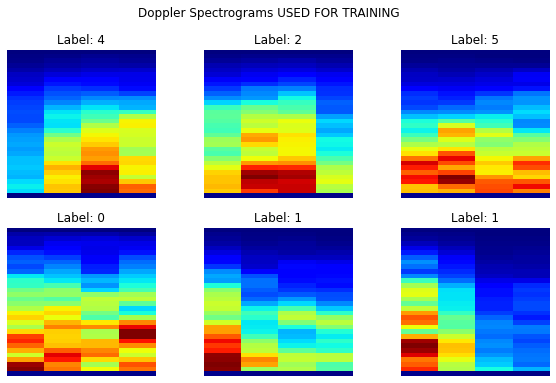

In [23]:
print("Shapes:", X_train_40.shape, X_val_40.shape, X_test_40.shape)

# -----------------------------
#  VISUALIZE TRAINING IMAGES
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    
    img = X_train_40[i]
    
    # if 3D (because of subcarriers), take mean projection
    if len(img.shape) == 3:
        img = np.mean(img, axis=-1)
    
    plt.imshow(img, cmap='jet')
    plt.title(f"Label: {y_train_40[i]}")
    plt.axis('off')

plt.suptitle("Doppler Spectrograms USED FOR TRAINING")
plt.show()

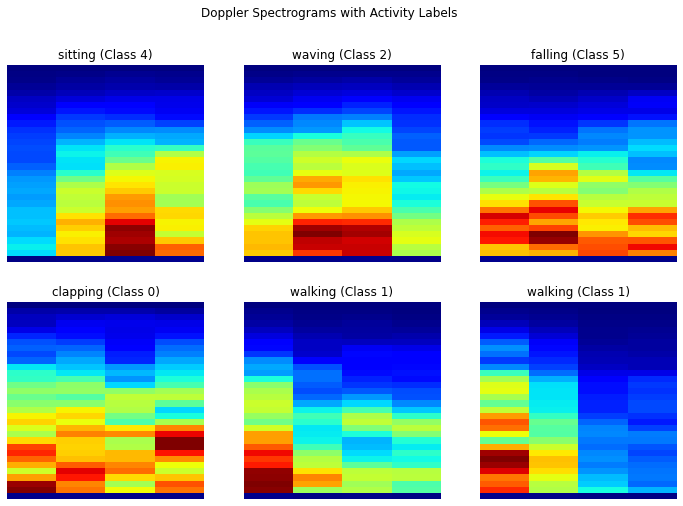

In [25]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")

LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

# -----------------------------
# SHOW LABELED IMAGES
# -----------------------------
plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    
    img = X_train_40[i]
    label = y_train_40[i]
    
    # If 3D → convert to 2D
    if len(img.shape) == 3:
        img = np.mean(img, axis=-1)
    
    plt.imshow(img, cmap='jet')
    plt.title(f"{LABELS[label]} (Class {label})")
    plt.axis('off')

plt.suptitle("Doppler Spectrograms with Activity Labels ")
plt.show()

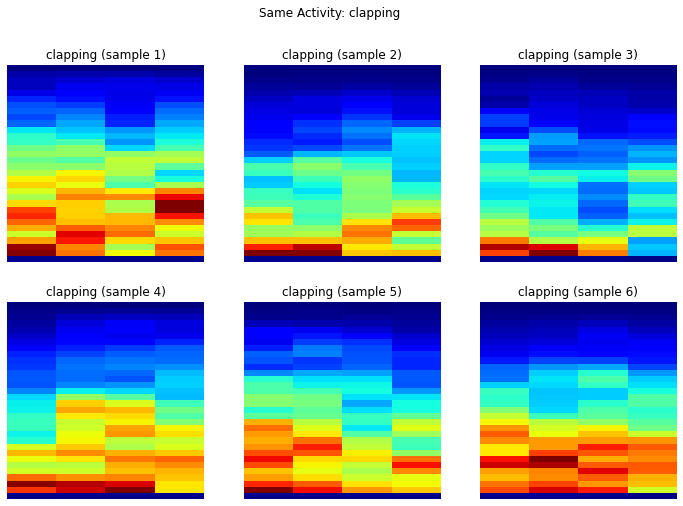

In [26]:
# -----------------------------
#  SAME ACTIVITY COMPARISON
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np

target_class = 0   # change this (0–5)

LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

# Find all indices of this activity
indices = np.where(y_train_40 == target_class)[0]

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices[:6]):  # show first 6 trials
    plt.subplot(2,3,i+1)
    
    img = X_train_40[idx]
    
    if len(img.shape) == 3:
        img = np.mean(img, axis=-1)
    
    plt.imshow(img, cmap='jet')
    plt.title(f"{LABELS[target_class]} (sample {i+1})")
    plt.axis('off')

plt.suptitle(f"Same Activity: {LABELS[target_class]} ")
plt.show()

In [17]:
# ---------- Global standardization ----------
mean_40 = X_train_40.mean(axis=(0,1,2), keepdims=True)
std_40  = X_train_40.std(axis=(0,1,2), keepdims=True) + 1e-6

X_train_40 = (X_train_40 - mean_40) / std_40
X_val_40   = (X_val_40   - mean_40) / std_40
X_test_40  = (X_test_40  - mean_40) / std_40

# ---------- CNN (same as before) ----------
def build_cnn(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return models.Model(inp, out)

model_40 = build_cnn(X_train_40.shape[1:])
model_40.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_40.summary()


Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 32, 32, 54)]      0         
                                                                 
 conv2d_24 (Conv2D)          (None, 32, 32, 32)        15584     
                                                                 
 batch_normalization_23 (Ba  (None, 32, 32, 32)        128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_14 (MaxPooli  (None, 16, 16, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_25 (Conv2D)          (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_24 (Ba  (None, 16, 16, 64)        256 

In [29]:
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4)
# ]

history = model_40.fit(
    X_train_40, y_train_40,
    validation_data=(X_val_40, y_val_40),
    epochs=50,
    batch_size=64,
#     callbacks=callbacks,
    verbose=1
)

train_acc = model_40.evaluate(X_train_40, y_train_40, verbose=0)[1]
val_acc   = model_40.evaluate(X_val_40, y_val_40, verbose=0)[1]
test_acc  = model_40.evaluate(X_test_40, y_test_40, verbose=0)[1]

print("\n40% BANDWIDTH RESULTS")
print("Train acc:", train_acc)
print("Val acc:  ", val_acc)
print("Test acc: ", test_acc)

Epoch 1/50
46/46 [==============================] - 11s 154ms/step - loss: 1.6147 - accuracy: 0.3370 - val_loss: 1.6447 - val_accuracy: 0.3569
Epoch 2/50
46/46 [==============================] - 7s 156ms/step - loss: 1.3344 - accuracy: 0.4793 - val_loss: 1.4808 - val_accuracy: 0.5177
Epoch 3/50
46/46 [==============================] - 7s 147ms/step - loss: 1.1880 - accuracy: 0.5534 - val_loss: 1.3151 - val_accuracy: 0.5595
Epoch 4/50
46/46 [==============================] - 7s 152ms/step - loss: 1.0956 - accuracy: 0.5858 - val_loss: 1.1740 - val_accuracy: 0.6206
Epoch 5/50
46/46 [==============================] - 7s 156ms/step - loss: 0.9723 - accuracy: 0.6313 - val_loss: 1.0586 - val_accuracy: 0.6415
Epoch 6/50
46/46 [==============================] - 6s 141ms/step - loss: 0.9155 - accuracy: 0.6626 - val_loss: 0.9453 - val_accuracy: 0.6801
Epoch 7/50
46/46 [==============================] - 7s 157ms/step - loss: 0.8463 - accuracy: 0.6916 - val_loss: 0.8799 - val_accuracy: 0.6849
Epoch

In [30]:
# Save this model too
model_40.save("slimsense_40percent_model.keras")
np.save("selected_subcarriers_40.npy", top_subcarriers_40)
np.save("mean_40.npy", mean_40)
np.save("std_40.npy", std_40)

print("\nSaved 40% model + preprocessing artifacts")


Saved 40% model + preprocessing artifacts


## run all bandwidth ratios automatically

In [18]:
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models

# --- HIGH-RES params (keep same as best) ---
FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32
NUM_CLASSES = 6

ratios = [0.10, 0.15, 0.20, 0.2442, 0.30, 0.40, 1.00]

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]
    return csi[:, 0::2] + 1j * csi[:, 1::2]

def stft_tensor(pdiff_sel):
    T, S = pdiff_sel.shape
    window = np.hanning(NPERSEG).astype(np.float32)
    frames = []
    for start in range(0, T - NPERSEG + 1, HOP):
        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X) ** 2
        P[0, :] = 0.0
        frames.append(P)
    P3 = np.stack(frames, axis=0)
    return np.transpose(P3, (1, 0, 2))  # (F, M, S)

def build_dataset_with_subcarriers(paths, labels, sub_idx):
    X, y = [], []
    for p, lab in zip(paths, labels):
        try:
            csi = load_csi_complex(p)
            phase = np.unwrap(np.angle(csi), axis=0)
            pdiff = np.diff(phase, axis=0)
            pdiff_sel = pdiff[:, sub_idx]
            P = stft_tensor(pdiff_sel)

            # suppress static + noise
            P[:2, :, :] = 0.0
            P[-2:, :, :] = 0.0
            P = np.log1p(5.0 * P)

            img = cv2.resize(P, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            X.append(img.astype(np.float32))
            y.append(lab)
        except:
            continue
    return np.array(X), np.array(y)



In [33]:
def build_cnn(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inp, out)

results = []

K_TOTAL = 135
ranked = np.argsort(mi)[::-1]  # MI ranking (high->low)

for r in ratios:
    topK = int(np.round(r * K_TOTAL))
    if topK < 1: topK = 1
    sub_idx = np.sort(ranked[:topK])

    print(f"\n===== Ratio {r:.4f}  ({topK}/{K_TOTAL} subcarriers) =====")

    Xtr, ytr = build_dataset_with_subcarriers(train_paths, y_train, sub_idx)
    Xva, yva = build_dataset_with_subcarriers(val_paths, y_val, sub_idx)
    Xte, yte = build_dataset_with_subcarriers(test_paths, y_test, sub_idx)

    # Standardize per setting
    mean = Xtr.mean(axis=(0,1,2), keepdims=True)
    std  = Xtr.std(axis=(0,1,2), keepdims=True) + 1e-6
    Xtr = (Xtr - mean) / std
    Xva = (Xva - mean) / std
    Xte = (Xte - mean) / std

    model = build_cnn(Xtr.shape[1:])
    model.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
    ]

    model.fit(Xtr, ytr, validation_data=(Xva, yva),
              epochs=35, batch_size=64, callbacks=callbacks, verbose=0)

    train_acc = model.evaluate(Xtr, ytr, verbose=0)[1]
    val_acc   = model.evaluate(Xva, yva, verbose=0)[1]
    test_acc  = model.evaluate(Xte, yte, verbose=0)[1]

    results.append((r, topK, train_acc, val_acc, test_acc))
    print(f"Train {train_acc:.4f} | Val {val_acc:.4f} | Test {test_acc:.4f}")

print("\n\n=== FINAL SUMMARY ===")
print("Ratio   Subcarriers   TrainAcc   ValAcc   TestAcc")
for r, topK, tr, va, te in results:
    print(f"{r:0.4f}   {topK:3d}          {tr:0.4f}    {va:0.4f}   {te:0.4f}")



===== Ratio 0.1000  (14/135 subcarriers) =====
Train 0.8394 | Val 0.7058 | Test 0.7219

===== Ratio 0.1500  (20/135 subcarriers) =====
Train 0.9187 | Val 0.7331 | Test 0.7347

===== Ratio 0.2000  (27/135 subcarriers) =====
Train 0.8863 | Val 0.7428 | Test 0.7524

===== Ratio 0.2442  (33/135 subcarriers) =====
Train 0.8942 | Val 0.7669 | Test 0.7347

===== Ratio 0.3000  (40/135 subcarriers) =====
Train 0.9390 | Val 0.7878 | Test 0.7572

===== Ratio 0.4000  (54/135 subcarriers) =====
Train 0.9518 | Val 0.7862 | Test 0.8071

===== Ratio 1.0000  (135/135 subcarriers) =====
Train 0.9838 | Val 0.8055 | Test 0.8119


=== FINAL SUMMARY ===
Ratio   Subcarriers   TrainAcc   ValAcc   TestAcc
0.1000    14          0.8394    0.7058   0.7219
0.1500    20          0.9187    0.7331   0.7347
0.2000    27          0.8863    0.7428   0.7524
0.2442    33          0.8942    0.7669   0.7347
0.3000    40          0.9390    0.7878   0.7572
0.4000    54          0.9518    0.7862   0.8071
1.0000   135         

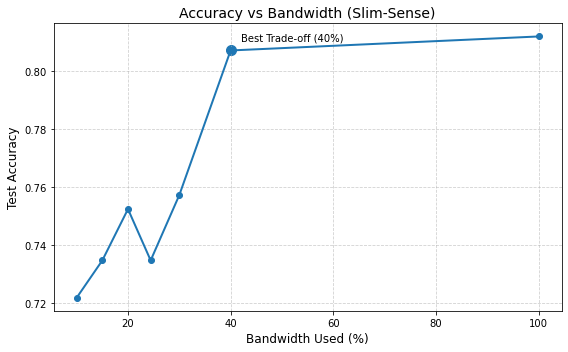

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results (or use results_df directly if already in memory)
results_df = pd.read_csv("slimsense_accuracy_vs_bandwidth.csv")

# Convert ratio to percentage
results_df["Bandwidth_%"] = results_df["Bandwidth_Ratio"] * 100

plt.figure(figsize=(8,5))

plt.plot(
    results_df["Bandwidth_%"],
    results_df["Test_Acc"],
    marker="o",
    linewidth=2
)

plt.xlabel("Bandwidth Used (%)", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("Accuracy vs Bandwidth (Slim-Sense)", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.6)

# Highlight 40% point (sweet spot)
row_40 = results_df[results_df["Bandwidth_%"] == 40]
if not row_40.empty:
    plt.scatter(row_40["Bandwidth_%"], row_40["Test_Acc"], s=100)
    plt.annotate(
        "Best Trade-off (40%)",
        (row_40["Bandwidth_%"].values[0], row_40["Test_Acc"].values[0]),
        textcoords="offset points",
        xytext=(10,10),
        fontsize=10
    )

plt.tight_layout()
plt.show()


## Save the BEST models (40% + 100%)

In [34]:
# Save 40% bandwidth model (your best trade-off)
model_40.save("slimsense_model_40percent.keras")

# Save 100% bandwidth baseline model
model.save("slimsense_model_100percent.keras")  # use the variable name you trained for 100%

print("Models saved")


Models saved


## Save subcarrier selections (CRITICAL for Slim-Sense)

In [35]:
import numpy as np

# 40% bandwidth subcarriers
np.save("selected_subcarriers_40.npy", top_subcarriers_40)

# Full bandwidth subcarriers (for baseline completeness)
np.save("selected_subcarriers_100.npy", np.arange(135))

print("Subcarrier indices saved")


Subcarrier indices saved


## Save normalization statistics

In [37]:
# For 40% model
np.save("mean_40.npy", mean_40)
np.save("std_40.npy", std_40)

# For 100% model
np.save("mean_100.npy", mean)
np.save("std_100.npy", std)

print("Normalization stats saved ")


Normalization stats saved 


## Save MI ranking

In [38]:
np.save("mi_scores.npy", mi)
np.save("mi_ranked_indices.npy", np.argsort(mi)[::-1])

print("MI ranking saved ")


MI ranking saved 


## Save final results table

In [39]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Bandwidth_Ratio", "Num_Subcarriers", "Train_Acc", "Val_Acc", "Test_Acc"]
)

results_df.to_csv("slimsense_accuracy_vs_bandwidth.csv", index=False)

print("Results table saved ")


Results table saved 


## Save dataset splits

In [40]:
np.save("train_paths.npy", train_paths)
np.save("val_paths.npy", val_paths)
np.save("test_paths.npy", test_paths)

np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

print("Dataset splits saved ")


Dataset splits saved 


## Load your trained model + preprocessing files

In [11]:
import numpy as np
import tensorflow as tf

# Load trained model
model = tf.keras.models.load_model("slimsense_40percent_model.keras")

# Load preprocessing artifacts
top_subcarriers_40 = np.load("selected_subcarriers_40.npy")
mean_40 = np.load("mean_40.npy")
std_40  = np.load("std_40.npy")

print("Model and preprocessing loaded successfully!")

Model and preprocessing loaded successfully!


## Convert your NEW dataset → Doppler images (same pipeline)

In [12]:
import os
import numpy as np
import scipy.io as sio
import cv2

# -------- PATH --------
NEW_DATASET_PATH = r"D:\PROJECT\Dataset\wifi_data_own_matlab"

# -------- SAME PARAMETERS (must match training) --------
FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

# -------- LOAD CSI --------
def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)

    # Automatically find CSI key
    key = [k for k in mat.keys() if not k.startswith("__")][0]
    csi = mat[key]

    return csi[:, 0::2] + 1j * csi[:, 1::2]

# -------- STFT --------
def stft_tensor(pdiff_sel):
    T, S = pdiff_sel.shape
    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []
    for start in range(0, T - NPERSEG + 1, HOP):
        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X) ** 2
        P[0, :] = 0.0
        frames.append(P)

    P3 = np.stack(frames, axis=0)
    return np.transpose(P3, (1, 0, 2))  # (F, M, S)

# -------- MAIN DOPPLER FUNCTION --------
def doppler_image_40(mat_path):
    csi = load_csi_complex(mat_path)

    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)

    # Use SAME selected subcarriers
    pdiff_sel = pdiff[:, top_subcarriers_40]

    P = stft_tensor(pdiff_sel)

    # remove static + noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # resize to 32x32
    img = cv2.resize(P, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    return img.astype(np.float32)

## Load ALL files → Convert into X (input data)

In [13]:
X_new = []
y_new = []
file_names = []

# Extract label from filename
def get_label_from_filename(fname):
    return fname.split("_")[0]   # clap, jump, etc.

# Create label mapping (auto)
all_labels = sorted(list(set(get_label_from_filename(f) 
                             for f in os.listdir(NEW_DATASET_PATH) 
                             if f.endswith(".mat"))))

label_map_new = {name: idx for idx, name in enumerate(all_labels)}

print("New dataset label mapping:", label_map_new)

# -------- LOAD DATA --------
for fname in os.listdir(NEW_DATASET_PATH):
    if not fname.endswith(".mat"):
        continue

    mat_path = os.path.join(NEW_DATASET_PATH, fname)

    try:
        img = doppler_image_40(mat_path)

        X_new.append(img)
        file_names.append(fname)

        # label (optional but useful)
        label_name = get_label_from_filename(fname)
        y_new.append(label_map_new[label_name])

    except Exception as e:
        print("Error in:", fname)
        continue

# Convert to numpy
X_new = np.array(X_new)[..., np.newaxis]
y_new = np.array(y_new)

print("\nNew dataset loaded!")
print("X_new shape:", X_new.shape)
print("y_new shape:", y_new.shape)

New dataset label mapping: {'clap': 0, 'jump': 1, 'sit': 2, 'walk': 3}
Error in: clap_p1_t1.mat
Error in: clap_p1_t2.mat
Error in: clap_p1_t3.mat
Error in: clap_p1_t4.mat
Error in: clap_p1_t5.mat
Error in: clap_p2_t1.mat
Error in: clap_p2_t2.mat
Error in: clap_p2_t3.mat
Error in: clap_p2_t4.mat
Error in: clap_p2_t5.mat
Error in: jump_p1_t1.mat
Error in: jump_p1_t2.mat
Error in: jump_p1_t3.mat
Error in: jump_p1_t4.mat
Error in: jump_p1_t5.mat
Error in: jump_p2_t1.mat
Error in: jump_p2_t2.mat
Error in: jump_p2_t3.mat
Error in: jump_p2_t4.mat
Error in: jump_p2_t5.mat
Error in: sit_p1_t1.mat
Error in: sit_p1_t2.mat
Error in: sit_p1_t3.mat
Error in: sit_p1_t4.mat
Error in: sit_p1_t5.mat
Error in: sit_p2_t1.mat
Error in: sit_p2_t2.mat
Error in: sit_p2_t3.mat
Error in: sit_p2_t4.mat
Error in: sit_p2_t5.mat
Error in: walk_p1_t1.mat
Error in: walk_p1_t2.mat
Error in: walk_p1_t3.mat
Error in: walk_p1_t4.mat
Error in: walk_p1_t5.mat
Error in: walk_p2_t1.mat
Error in: walk_p2_t2.mat
Error in: walk

In [14]:
import scipy.io as sio

test_file = r"D:\PROJECT\Dataset\wifi_data_own_matlab\clap_p1_t1.mat"

mat = sio.loadmat(test_file)

print("Keys:", mat.keys())

for key in mat.keys():
    if not key.startswith("__"):
        data = mat[key]
        print("\nKey:", key)
        print("Shape:", data.shape)
        print("Type:", type(data))
        print("Sample:", data[:2])

Keys: dict_keys(['__header__', '__version__', '__globals__', 'csi_trace'])

Key: csi_trace
Shape: (44, 1)
Type: <class 'numpy.ndarray'>
Sample: [[array([[(array([[2.74799658e+09]]), array([[7511]], dtype=uint16), array([[3]], dtype=uint8), array([[3]], dtype=uint8), array([[38]], dtype=uint8), array([[37]], dtype=uint8), array([[39]], dtype=uint8), array([[-84]], dtype=int16), array([[18]], dtype=uint8), array([[1, 3, 2]], dtype=uint8), array([[8471]], dtype=uint16), array([[[-42.+14.j, -27.+43.j,   8.+57.j,  45.+42.j,  64. +6.j,
                    57.-33.j,  28.-62.j, -10.-69.j, -46.-53.j, -69.-20.j,
                   -70.+20.j, -48.+55.j, -12.+74.j,  30.+71.j,  49.+60.j,
                    75.+25.j,  75.-19.j,  56.-57.j,  18.-78.j, -28.-74.j,
                   -65.-49.j, -81. -5.j, -72.+40.j, -35.+75.j,  16.+82.j,
                    63.+55.j,  78. +5.j,  60.-44.j,  14.-66.j,  -8.-61.j],
                  [  7. +1.j,   8. -4.j,   3. -8.j,  -2. -8.j,  -7. -4.j,
                   

In [15]:
import os
import numpy as np
import scipy.io as sio
import cv2

NEW_DATASET_PATH = r"D:\PROJECT\Dataset\wifi_data_own_matlab"

# -------- PARAMETERS (same as before) --------
FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

# -------- NEW CSI LOADER (FIXED FOR YOUR DATA) --------
def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi_trace = mat["csi_trace"]  # (num_packets, 1)

    packets = []

    for i in range(len(csi_trace)):
        entry = csi_trace[i, 0]

        # extract (3x3x30) complex CSI
        csi = entry["csi"][0, 0]

        # reshape → (9,30)
        csi = csi.reshape(-1, 30)

        # average antennas → (30,)
        csi_mean = np.mean(csi, axis=0)

        packets.append(csi_mean)

    return np.array(packets)  # (T, 30)

# -------- STFT --------
def stft_tensor(pdiff_sel):
    T, S = pdiff_sel.shape
    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []
    for start in range(0, T - NPERSEG + 1, HOP):
        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X) ** 2
        P[0, :] = 0.0
        frames.append(P)

    if len(frames) == 0:
        raise ValueError("Signal too short for STFT")

    P3 = np.stack(frames, axis=0)
    return np.transpose(P3, (1, 0, 2))

# -------- DOPPLER FUNCTION (UPDATED) --------
def doppler_image_40(mat_path):
    csi = load_csi_complex(mat_path)

    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)

    #  IMPORTANT FIX: NO subcarrier selection (since only 30 available)
    pdiff_sel = pdiff

    P = stft_tensor(pdiff_sel)

    # remove noise
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # resize to 32x32
    # combine subcarriers → (F, M)
    P = np.mean(P, axis=2)

    # resize to 32x32
    img = cv2.resize(P, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    return img.astype(np.float32)

# -------- LOAD DATASET --------
X_new = []
y_new = []
file_names = []

def get_label_from_filename(fname):
    return fname.split("_")[0]

# create label mapping
all_labels = sorted(list(set(
    get_label_from_filename(f)
    for f in os.listdir(NEW_DATASET_PATH)
    if f.endswith(".mat")
)))

label_map_new = {name: idx for idx, name in enumerate(all_labels)}

print("Label mapping:", label_map_new)

# process files
for fname in os.listdir(NEW_DATASET_PATH):
    if not fname.endswith(".mat"):
        continue

    path = os.path.join(NEW_DATASET_PATH, fname)

    try:
        img = doppler_image_40(path)

        X_new.append(img)
        file_names.append(fname)

        label_name = get_label_from_filename(fname)
        y_new.append(label_map_new[label_name])

    except Exception as e:
        print("Error:", fname, e)

# convert to numpy
X_new = np.array(X_new)[..., np.newaxis]
y_new = np.array(y_new)

print("\nDONE ")
print("X_new shape:", X_new.shape)
print("y_new shape:", y_new.shape)

Label mapping: {'clap': 0, 'jump': 1, 'sit': 2, 'walk': 3}
Error: clap_p1_t4.mat Signal too short for STFT
Error: clap_p2_t4.mat Signal too short for STFT
Error: jump_p1_t4.mat Signal too short for STFT
Error: sit_p1_t2.mat Signal too short for STFT
Error: sit_p1_t3.mat Signal too short for STFT
Error: sit_p1_t4.mat Signal too short for STFT
Error: walk_p1_t3.mat Signal too short for STFT

DONE 
X_new shape: (33, 32, 32, 1)
y_new shape: (33,)


In [16]:
# -------- NORMALIZE (VERY IMPORTANT) --------
X_new_norm = (X_new - mean_40) / std_40

print("Normalization done!")

# -------- PREDICT --------
y_pred_probs = model.predict(X_new_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nPredictions done!")

Normalization done!
2/2 [==============================] - 0s 9ms/step

Predictions done!


In [17]:
print("\n--- Sample Predictions ---")

for i in range(len(y_pred)):
    print(f"{file_names[i]} → Predicted: {y_pred[i]}, Actual: {y_new[i]}")


--- Sample Predictions ---
clap_p1_t1.mat → Predicted: 4, Actual: 0
clap_p1_t2.mat → Predicted: 4, Actual: 0
clap_p1_t3.mat → Predicted: 4, Actual: 0
clap_p1_t5.mat → Predicted: 4, Actual: 0
clap_p2_t1.mat → Predicted: 4, Actual: 0
clap_p2_t2.mat → Predicted: 4, Actual: 0
clap_p2_t3.mat → Predicted: 4, Actual: 0
clap_p2_t5.mat → Predicted: 4, Actual: 0
jump_p1_t1.mat → Predicted: 4, Actual: 1
jump_p1_t2.mat → Predicted: 4, Actual: 1
jump_p1_t3.mat → Predicted: 4, Actual: 1
jump_p1_t5.mat → Predicted: 4, Actual: 1
jump_p2_t1.mat → Predicted: 4, Actual: 1
jump_p2_t2.mat → Predicted: 4, Actual: 1
jump_p2_t3.mat → Predicted: 4, Actual: 1
jump_p2_t4.mat → Predicted: 4, Actual: 1
jump_p2_t5.mat → Predicted: 4, Actual: 1
sit_p1_t1.mat → Predicted: 4, Actual: 2
sit_p1_t5.mat → Predicted: 4, Actual: 2
sit_p2_t1.mat → Predicted: 4, Actual: 2
sit_p2_t2.mat → Predicted: 4, Actual: 2
sit_p2_t3.mat → Predicted: 4, Actual: 2
sit_p2_t4.mat → Predicted: 4, Actual: 2
sit_p2_t5.mat → Predicted: 4, Actua

In [18]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# -----------------------------
# STEP 1: Prepare labels
# -----------------------------
y_new_ft = y_new.copy()

print("Labels:", np.unique(y_new_ft))

# -----------------------------
# STEP 2: Normalize (IMPORTANT)
# -----------------------------
X_new_norm = (X_new - mean_40) / std_40

# -----------------------------
# STEP 3: Train/Val split
# -----------------------------
X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_new_norm, y_new_ft, test_size=0.3, random_state=42, stratify=y_new_ft
)

print("Train shape:", X_ft_train.shape)
print("Val shape:", X_ft_val.shape)

# -----------------------------
# STEP 4: Freeze early layers
# -----------------------------
for layer in model.layers[:-3]:
    layer.trainable = False

print("Layers frozen!")

# -----------------------------
# STEP 5: Recompile model
# -----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



Labels: [0 1 2 3]
Train shape: (23, 32, 32, 54)
Val shape: (10, 32, 32, 54)
Layers frozen!


In [19]:
# -----------------------------
# STEP 6: Fine-tune training
# -----------------------------
history = model.fit(
    X_ft_train, y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=15,
    batch_size=8,
    verbose=1
)


Epoch 1/15
3/3 [==============================] - 1s 152ms/step - loss: 158.5974 - accuracy: 0.0000e+00 - val_loss: 172.9145 - val_accuracy: 0.0000e+00
Epoch 2/15
3/3 [==============================] - 0s 41ms/step - loss: 190.7412 - accuracy: 0.0000e+00 - val_loss: 170.4966 - val_accuracy: 0.0000e+00
Epoch 3/15
3/3 [==============================] - 0s 30ms/step - loss: 181.7816 - accuracy: 0.0000e+00 - val_loss: 168.0976 - val_accuracy: 0.0000e+00
Epoch 4/15
3/3 [==============================] - 0s 44ms/step - loss: 174.3484 - accuracy: 0.0000e+00 - val_loss: 165.7097 - val_accuracy: 0.0000e+00
Epoch 5/15
3/3 [==============================] - 0s 30ms/step - loss: 181.3406 - accuracy: 0.0000e+00 - val_loss: 163.3011 - val_accuracy: 0.0000e+00
Epoch 6/15
3/3 [==============================] - 0s 35ms/step - loss: 170.9920 - accuracy: 0.0000e+00 - val_loss: 160.8789 - val_accuracy: 0.0000e+00
Epoch 7/15
3/3 [==============================] - 0s 29ms/step - loss: 168.8677 - accuracy: 0

In [20]:
# -----------------------------
# STEP 7: Evaluate
# -----------------------------
val_acc = model.evaluate(X_ft_val, y_ft_val, verbose=0)[1]
print("\nFine-tuned Validation Accuracy:", val_acc)

# -----------------------------
# STEP 8: Predict again
# -----------------------------
y_pred_ft = np.argmax(model.predict(X_new_norm), axis=1)

print("\n--- After Fine-Tuning ---")
for i in range(len(y_pred_ft)):
    print(f"{file_names[i]} → Pred: {y_pred_ft[i]}, Actual: {y_new[i]}")


Fine-tuned Validation Accuracy: 0.0
2/2 [==============================] - 0s 7ms/step

--- After Fine-Tuning ---
clap_p1_t1.mat → Pred: 4, Actual: 0
clap_p1_t2.mat → Pred: 4, Actual: 0
clap_p1_t3.mat → Pred: 4, Actual: 0
clap_p1_t5.mat → Pred: 4, Actual: 0
clap_p2_t1.mat → Pred: 4, Actual: 0
clap_p2_t2.mat → Pred: 4, Actual: 0
clap_p2_t3.mat → Pred: 4, Actual: 0
clap_p2_t5.mat → Pred: 4, Actual: 0
jump_p1_t1.mat → Pred: 4, Actual: 1
jump_p1_t2.mat → Pred: 4, Actual: 1
jump_p1_t3.mat → Pred: 4, Actual: 1
jump_p1_t5.mat → Pred: 4, Actual: 1
jump_p2_t1.mat → Pred: 4, Actual: 1
jump_p2_t2.mat → Pred: 4, Actual: 1
jump_p2_t3.mat → Pred: 4, Actual: 1
jump_p2_t4.mat → Pred: 4, Actual: 1
jump_p2_t5.mat → Pred: 4, Actual: 1
sit_p1_t1.mat → Pred: 4, Actual: 2
sit_p1_t5.mat → Pred: 4, Actual: 2
sit_p2_t1.mat → Pred: 4, Actual: 2
sit_p2_t2.mat → Pred: 4, Actual: 2
sit_p2_t3.mat → Pred: 4, Actual: 2
sit_p2_t4.mat → Pred: 4, Actual: 2
sit_p2_t5.mat → Pred: 4, Actual: 2
walk_p1_t1.mat → Pred: 4, Ac

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np

# -----------------------------
# STEP 1: Normalize
# -----------------------------
X_new_norm = (X_new - mean_40) / std_40
y_new_ft = y_new.copy()

# -----------------------------
# STEP 2: Split
# -----------------------------
X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_new_norm, y_new_ft, test_size=0.3, random_state=42, stratify=y_new_ft
)

# -----------------------------
# STEP 3: MODIFY MODEL (FIXED)
# -----------------------------
x = model.layers[-2].output

#  give unique name here
new_output = layers.Dense(4, activation='softmax', name="new_output_layer")(x)

new_model = models.Model(inputs=model.input, outputs=new_output)

# -----------------------------
# STEP 4: Freeze early layers
# -----------------------------
for layer in new_model.layers[:-3]:
    layer.trainable = False

# -----------------------------
# STEP 5: Compile
# -----------------------------
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# STEP 6: Train
# -----------------------------
history = new_model.fit(
    X_ft_train, y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=20,
    batch_size=8,
    verbose=1
)

# -----------------------------
# STEP 7: Evaluate
# -----------------------------
val_acc = new_model.evaluate(X_ft_val, y_ft_val, verbose=0)[1]
print("\nValidation Accuracy:", val_acc)

# -----------------------------
# STEP 8: Predict
# -----------------------------
y_pred_ft = np.argmax(new_model.predict(X_new_norm), axis=1)

print("\n--- After FINAL Fine-Tuning ---")
for i in range(len(y_pred_ft)):
    print(f"{file_names[i]} → Pred: {y_pred_ft[i]}, Actual: {y_new[i]}")

Epoch 1/20
3/3 [==============================] - 1s 140ms/step - loss: 24.2866 - accuracy: 0.3043 - val_loss: 5.0944 - val_accuracy: 0.1000
Epoch 2/20
3/3 [==============================] - 0s 30ms/step - loss: 33.2794 - accuracy: 0.1739 - val_loss: 5.1028 - val_accuracy: 0.3000
Epoch 3/20
3/3 [==============================] - 0s 34ms/step - loss: 26.5020 - accuracy: 0.3043 - val_loss: 4.9522 - val_accuracy: 0.2000
Epoch 4/20
3/3 [==============================] - 0s 40ms/step - loss: 25.0563 - accuracy: 0.1739 - val_loss: 4.7795 - val_accuracy: 0.2000
Epoch 5/20
3/3 [==============================] - 0s 40ms/step - loss: 16.4481 - accuracy: 0.3913 - val_loss: 4.6025 - val_accuracy: 0.3000
Epoch 6/20
3/3 [==============================] - 0s 33ms/step - loss: 25.2519 - accuracy: 0.3043 - val_loss: 4.3916 - val_accuracy: 0.3000
Epoch 7/20
3/3 [==============================] - 0s 31ms/step - loss: 11.8970 - accuracy: 0.4348 - val_loss: 4.2410 - val_accuracy: 0.3000
Epoch 8/20
3/3 [===

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np

# -----------------------------
# STEP 1: Normalize
# -----------------------------
X_new_norm = (X_new - mean_40) / std_40
y_new_ft = y_new.copy()

# -----------------------------
# STEP 2: AUGMENT DATA 
# -----------------------------
def augment_data(X, y):
    X_aug, y_aug = [], []

    for i in range(len(X)):
        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # noise
        noise = img + 0.02 * np.random.randn(*img.shape)
        X_aug.append(noise)
        y_aug.append(y[i])

        # flip
        flip = np.flip(img, axis=1)
        X_aug.append(flip)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(X_new_norm, y_new_ft)

print("Augmented shape:", X_aug.shape)

# -----------------------------
# STEP 3: Split
# -----------------------------
X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_aug, y_aug, test_size=0.3, random_state=42, stratify=y_aug
)

# -----------------------------
# STEP 4: MODIFY MODEL
# -----------------------------
x = model.layers[-2].output
new_output = layers.Dense(4, activation='softmax', name="new_output_layer")(x)

new_model = models.Model(inputs=model.input, outputs=new_output)

# -----------------------------
# STEP 5: UNFREEZE ALL 
# -----------------------------
for layer in new_model.layers:
    layer.trainable = True

# -----------------------------
# STEP 6: COMPILE
# -----------------------------
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# STEP 7: TRAIN (LONGER)
# -----------------------------
history = new_model.fit(
    X_ft_train, y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=60,
    batch_size=4,
    verbose=1
)

# -----------------------------
# STEP 8: PREDICT
# -----------------------------
y_pred_ft = np.argmax(new_model.predict(X_new_norm), axis=1)

print("\n--- FINAL RESULTS (IMPROVED) ---")
for i in range(len(y_pred_ft)):
    print(f"{file_names[i]} → Pred: {y_pred_ft[i]}, Actual: {y_new[i]}")

Augmented shape: (99, 32, 32, 54)
Epoch 1/60
18/18 [==============================] - 2s 30ms/step - loss: 1.4909 - accuracy: 0.1304 - val_loss: 4.7992 - val_accuracy: 0.2667
Epoch 2/60
18/18 [==============================] - 0s 14ms/step - loss: 1.4725 - accuracy: 0.1449 - val_loss: 3.4950 - val_accuracy: 0.2667
Epoch 3/60
18/18 [==============================] - 0s 17ms/step - loss: 1.3666 - accuracy: 0.3043 - val_loss: 2.8183 - val_accuracy: 0.2667
Epoch 4/60
18/18 [==============================] - 0s 16ms/step - loss: 1.4403 - accuracy: 0.1884 - val_loss: 2.3630 - val_accuracy: 0.2667
Epoch 5/60
18/18 [==============================] - 0s 15ms/step - loss: 1.3423 - accuracy: 0.2899 - val_loss: 2.1132 - val_accuracy: 0.2667
Epoch 6/60
18/18 [==============================] - 0s 18ms/step - loss: 1.2947 - accuracy: 0.4783 - val_loss: 2.1356 - val_accuracy: 0.2667
Epoch 7/60
18/18 [==============================] - 0s 13ms/step - loss: 1.3142 - accuracy: 0.4058 - val_loss: 2.1442 - 

In [23]:
# Save final fine-tuned model
new_model.save("final_wifi_model.keras")

print("Model saved successfully ")

Model saved successfully 


In [24]:
import numpy as np

np.save("mean_40_final.npy", mean_40)
np.save("std_40_final.npy", std_40)

print("Normalization parameters saved ")

Normalization parameters saved 


In [21]:
import os
import numpy as np
import scipy.io as sio
import cv2

BASE_PATH = r"D:\PROJECT\Dataset\csi_data2d\train"

X = []
y = []

def mat_to_doppler32(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]

    csi_complex = csi[:, 0::2] + 1j * csi[:, 1::2]

    phase = np.unwrap(np.angle(csi_complex), axis=0)
    phase_diff = np.diff(phase, axis=0)

    doppler = np.abs(np.fft.fftshift(np.fft.fft(phase_diff, axis=0), axes=0))
    doppler = np.mean(doppler, axis=1)

    doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-6)

    img = cv2.resize(doppler.reshape(-1,1), (32,32))

    return img

for folder in sorted(os.listdir(BASE_PATH)):
    folder_path = os.path.join(BASE_PATH, folder)

    if not folder.isdigit():
        continue

    label = int(folder) - 1

    for file in os.listdir(folder_path):
        if file.endswith(".mat"):
            try:
                img = mat_to_doppler32(os.path.join(folder_path, file))
                X.append(img)
                y.append(label)
            except:
                continue

X = np.array(X)[..., np.newaxis]
y = np.array(y)

print("FINAL SHAPES:")

print("X:", X.shape)
print("y:", y.shape)

FINAL SHAPES:
X: (4146, 32, 32, 1)
y: (4146,)


In [22]:
print("Label distribution:", np.unique(y, return_counts=True))

Label distribution: (array([0, 1, 2, 3, 4, 5]), array([725, 741, 448, 747, 744, 741], dtype=int64))


## with another dataset

In [1]:
import os
import numpy as np
import scipy.io as sio
import cv2
from scipy.signal import stft

DATASET_PATH = r"D:\PROJECT\Dataset\wifi_dataset_shilpi_matlab"

FS = 20
WINDOW = 32
OVERLAP = 16
IMG_SIZE = 32

X = []
y = []
file_names = []

# label mapping
label_map = {
    "clap": 0,
    "jump": 1,
    "walk": 2,
    "wave": 3
}

def extract_csi_from_trace(mat_path):
    mat = sio.loadmat(mat_path)
    trace = mat["csi_trace"]

    csi_list = []

    for i in range(len(trace)):
        try:
            entry = trace[i, 0]

            # extract CSI matrix (3x30 complex)
            csi = entry["csi"][0][0]

            # take one stream (simplify)
            csi = csi[0, :]   # shape (30,)

            csi_list.append(csi)

        except:
            continue

    return np.array(csi_list)  # (packets, 30)


def mat_to_doppler(mat_path):
    csi = extract_csi_from_trace(mat_path)

    if len(csi) < WINDOW:
        raise ValueError("Too short signal")

    # Phase
    phase = np.unwrap(np.angle(csi), axis=0)

    # Phase difference
    phase_diff = np.diff(phase, axis=0)

    # STFT
    energy_sum = None
    for sc in range(phase_diff.shape[1]):
        f, t, Zxx = stft(
            phase_diff[:, sc],
            fs=FS,
            nperseg=WINDOW,
            noverlap=OVERLAP,
            return_onesided=False
        )
        e = np.abs(Zxx) ** 2
        energy_sum = e if energy_sum is None else (energy_sum + e)

    # Log + normalize
    doppler = np.log1p(energy_sum)
    doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-8)

    # Resize
    doppler_img = cv2.resize(doppler, (IMG_SIZE, IMG_SIZE))

    return doppler_img.astype(np.float32)


# -------- BUILD DATASET --------
for file in os.listdir(DATASET_PATH):
    if not file.endswith(".mat"):
        continue

    label_name = file.split("_")[0]

    if label_name not in label_map:
        continue

    mat_path = os.path.join(DATASET_PATH, file)

    try:
        img = mat_to_doppler(mat_path)
        X.append(img)
        y.append(label_map[label_name])
        file_names.append(file)
    except Exception as e:
        print("Error:", file, e)

X = np.array(X)[..., np.newaxis]
y = np.array(y)

print("Dataset ready ")
print("X shape:", X.shape)
print("y:", y)

C:\Users\Shilpi Rani\AppData\Roaming\Python\Python39\site-packages\scipy\signal\_spectral_py.py:1240: UserWarning: nperseg = 32 is greater than input length  = 30, using nperseg = 30
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


Dataset ready 
X shape: (20, 32, 32, 4, 1)
y: [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3]


In [2]:
# Fix shape: (20, 32, 32, 4, 1) → (20, 32, 32, 1)

X = np.mean(X, axis=3)   # remove that 4 channel

print("Fixed shape:", X.shape)

Fixed shape: (20, 32, 32, 1)


In [1]:
import os
import numpy as np
import scipy.io as sio
import cv2
from scipy.signal import stft
import tensorflow as tf

# -----------------------------
# PATHS
# -----------------------------
DATASET_PATH = r"D:\PROJECT\Dataset\wifi_dataset_shilpi_matlab"

model = tf.keras.models.load_model("slimsense_model_40percent.keras")

mean = np.load("mean_40.npy")
std  = np.load("std_40.npy")

# -----------------------------
# PARAMETERS (same as training)
# -----------------------------

FS = 20
WINDOW = 32
OVERLAP = 16
IMG_SIZE = 32

label_map = {
    "clap": 0,
    "jump": 1,
    "walk": 2,
    "wave": 3
}

# -----------------------------
# CSI TRACE → DOPPLER
# -----------------------------
def extract_csi(mat_path):
    mat = sio.loadmat(mat_path)
    trace = mat["csi_trace"]

    csi_list = []

    for i in range(len(trace)):
        try:
            entry = trace[i, 0]
            csi = entry["csi"][0][0]   # (3,3,30)

            # take first tx-rx stream
            csi = csi[0, 0, :]   # (30,)

            csi_list.append(csi)
        except:
            continue

    return np.array(csi_list)


def mat_to_doppler(mat_path):
    csi = extract_csi(mat_path)

    if len(csi) < WINDOW:
        raise ValueError("Too short")

    phase = np.unwrap(np.angle(csi), axis=0)
    phase_diff = np.diff(phase, axis=0)

    energy_sum = None

    for sc in range(phase_diff.shape[1]):
        f, t, Zxx = stft(
            phase_diff[:, sc],
            fs=FS,
            nperseg=WINDOW,
            noverlap=OVERLAP,
            return_onesided=False
        )

        e = np.abs(Zxx) ** 2
        energy_sum = e if energy_sum is None else (energy_sum + e)

    doppler = np.log1p(energy_sum)
    doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-8)

    doppler = cv2.resize(doppler, (IMG_SIZE, IMG_SIZE))

    return doppler.astype(np.float32)


# -----------------------------
# BUILD TEST DATA
# -----------------------------
X_test = []
y_test = []
file_names = []

for file in os.listdir(DATASET_PATH):
    if not file.endswith(".mat"):
        continue

    label_name = file.split("_")[0]

    if label_name not in label_map:
        continue

    path = os.path.join(DATASET_PATH, file)

    try:
        img = mat_to_doppler(path)
        X_test.append(img)
        y_test.append(label_map[label_name])
        file_names.append(file)
    except Exception as e:
        print("Error:", file, e)

X_test = np.array(X_test)[..., np.newaxis]
y_test = np.array(y_test)

print("Test shape:", X_test.shape)

# -----------------------------
# NORMALIZATION (VERY IMPORTANT)
# -----------------------------
X_test = (X_test - mean) / std

# -----------------------------
# PREDICTION
# -----------------------------
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("\n--- Predictions ---")
for i in range(len(y_pred)):
    print(f"{file_names[i]} → Pred: {y_pred[i]}, Actual: {y_test[i]}")




Test shape: (20, 32, 32, 1)
1/1 [==============================] - 1s 690ms/step

--- Predictions ---
clap_t1.mat → Pred: 4, Actual: 0
clap_t2.mat → Pred: 4, Actual: 0
clap_t3.mat → Pred: 4, Actual: 0
clap_t4.mat → Pred: 4, Actual: 0
clap_t5.mat → Pred: 4, Actual: 0
jump_t1.mat → Pred: 4, Actual: 1
jump_t2.mat → Pred: 4, Actual: 1
jump_t3.mat → Pred: 4, Actual: 1
jump_t4.mat → Pred: 4, Actual: 1
jump_t5.mat → Pred: 4, Actual: 1
walk_t1.mat → Pred: 4, Actual: 2
walk_t2.mat → Pred: 4, Actual: 2
walk_t3.mat → Pred: 4, Actual: 2
walk_t4.mat → Pred: 4, Actual: 2
walk_t5.mat → Pred: 4, Actual: 2
wave_t1.mat → Pred: 4, Actual: 3
wave_t2.mat → Pred: 4, Actual: 3
wave_t3.mat → Pred: 4, Actual: 3
wave_t4.mat → Pred: 4, Actual: 3
wave_t5.mat → Pred: 4, Actual: 3


## fine tuning

In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np

# normalize
X_new_norm = (X_test - mean) / std
y_new = y_test.copy()

# split
X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_new_norm, y_new, test_size=0.3, random_state=42, stratify=y_new
)

In [4]:
# remove last layer
x = model.layers[-2].output

# new output layer (4 classes)
new_output = tf.keras.layers.Dense(4, activation='softmax', name="new_output")(x)

new_model = tf.keras.Model(inputs=model.input, outputs=new_output)
# freeze most layers
for layer in new_model.layers[:-4]:
    layer.trainable = False
    
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
history = new_model.fit(
    X_ft_train, y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=30,
    batch_size=4,
    verbose=1
)

Epoch 1/30


4/4 [==============================] - 4s 232ms/step - loss: 25.9888 - accuracy: 0.2143 - val_loss: 45.0953 - val_accuracy: 0.1667
Epoch 2/30
4/4 [==============================] - 0s 52ms/step - loss: 48.4305 - accuracy: 0.2857 - val_loss: 43.3033 - val_accuracy: 0.1667
Epoch 3/30
4/4 [==============================] - 0s 60ms/step - loss: 42.7006 - accuracy: 0.2143 - val_loss: 41.8383 - val_accuracy: 0.1667
Epoch 4/30
4/4 [==============================] - 0s 44ms/step - loss: 45.0959 - accuracy: 0.2857 - val_loss: 40.2906 - val_accuracy: 0.1667
Epoch 5/30
4/4 [==============================] - 0s 53ms/step - loss: 34.6108 - accuracy: 0.2143 - val_loss: 38.7664 - val_accuracy: 0.1667
Epoch 6/30
4/4 [==============================] - 0s 47ms/step - loss: 35.4817 - accuracy: 0.2857 - val_loss: 37.1083 - val_accuracy: 0.1667
Epoch 7/30
4/4 [==============================] - 0s 38ms/step - loss: 36.6613 - accuracy: 0.2143 - val_loss: 35.7060 - val_accuracy: 0.1667
Epoch 8/30

In [7]:
y_pred = np.argmax(new_model.predict(X_new_norm), axis=1)

print("\n--- After Fine-Tuning ---")
for i in range(len(y_pred)):
    print(f"{file_names[i]} → Pred: {y_pred[i]}, Actual: {y_new[i]}")

1/1 [==============================] - 0s 245ms/step

--- After Fine-Tuning ---
clap_t1.mat → Pred: 1, Actual: 0
clap_t2.mat → Pred: 1, Actual: 0
clap_t3.mat → Pred: 1, Actual: 0
clap_t4.mat → Pred: 1, Actual: 0
clap_t5.mat → Pred: 1, Actual: 0
jump_t1.mat → Pred: 1, Actual: 1
jump_t2.mat → Pred: 1, Actual: 1
jump_t3.mat → Pred: 1, Actual: 1
jump_t4.mat → Pred: 1, Actual: 1
jump_t5.mat → Pred: 1, Actual: 1
walk_t1.mat → Pred: 1, Actual: 2
walk_t2.mat → Pred: 1, Actual: 2
walk_t3.mat → Pred: 1, Actual: 2
walk_t4.mat → Pred: 1, Actual: 2
walk_t5.mat → Pred: 1, Actual: 2
wave_t1.mat → Pred: 1, Actual: 3
wave_t2.mat → Pred: 1, Actual: 3
wave_t3.mat → Pred: 1, Actual: 3
wave_t4.mat → Pred: 1, Actual: 3
wave_t5.mat → Pred: 1, Actual: 3


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# -----------------------------
# STEP 1: Normalize
# -----------------------------
X_new_norm = (X_test - mean) / std
y_new = y_test.copy()

# -----------------------------
# STEP 2: Split
# -----------------------------
X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_new_norm, y_new, test_size=0.3, random_state=42, stratify=y_new
)

# -----------------------------
# STEP 3: MODIFY MODEL (6 → 4 classes)
# -----------------------------
x = model.layers[-2].output
new_output = layers.Dense(4, activation='softmax', name="new_output")(x)

new_model = models.Model(inputs=model.input, outputs=new_output)

# -----------------------------
# STEP 4: UNFREEZE ALL LAYERS 
# -----------------------------
for layer in new_model.layers:
    layer.trainable = True

# -----------------------------
# STEP 5: CLASS WEIGHTS (VERY IMPORTANT)
# -----------------------------
classes = np.unique(y_ft_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_ft_train)

class_weights = {i: weights[i] for i in range(len(weights))}
print("Class weights:", class_weights)

# -----------------------------
# STEP 6: COMPILE (LOW LR)
# -----------------------------
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  #  very low LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# STEP 7: TRAIN
# -----------------------------
history = new_model.fit(
    X_ft_train, y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=50,
    batch_size=4,
    class_weight=class_weights,
    verbose=1
)

# -----------------------------
# STEP 8: TEST
# -----------------------------
y_pred = np.argmax(new_model.predict(X_new_norm), axis=1)

print("\n--- FINAL RESULTS ---")
for i in range(len(y_pred)):
    print(f"{file_names[i]} → Pred: {y_pred[i]}, Actual: {y_new[i]}")

Class weights: {0: 1.1666666666666667, 1: 0.875, 2: 1.1666666666666667, 3: 0.875}
Epoch 1/50
4/4 [==============================] - 2s 223ms/step - loss: 1.4615 - accuracy: 0.2857 - val_loss: 3.7625 - val_accuracy: 0.1667
Epoch 2/50
4/4 [==============================] - 0s 44ms/step - loss: 1.5784 - accuracy: 0.1429 - val_loss: 3.0124 - val_accuracy: 0.0000e+00
Epoch 3/50
4/4 [==============================] - 0s 73ms/step - loss: 1.2728 - accuracy: 0.4286 - val_loss: 2.6236 - val_accuracy: 0.0000e+00
Epoch 4/50
4/4 [==============================] - 0s 37ms/step - loss: 1.4007 - accuracy: 0.2857 - val_loss: 2.3818 - val_accuracy: 0.0000e+00
Epoch 5/50
4/4 [==============================] - 0s 44ms/step - loss: 1.3825 - accuracy: 0.3571 - val_loss: 2.2204 - val_accuracy: 0.1667
Epoch 6/50
4/4 [==============================] - 0s 45ms/step - loss: 1.4541 - accuracy: 0.2857 - val_loss: 2.0875 - val_accuracy: 0.1667
Epoch 7/50
4/4 [==============================] - 0s 52ms/step - loss: 

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np

# -----------------------------
# STEP 1: Normalize
# -----------------------------
X_new_norm = (X_test - mean) / std
y_new = y_test.copy()

# -----------------------------
# STEP 2: AUGMENT DATA 
# -----------------------------
def augment_data(X, y):
    X_aug, y_aug = [], []

    for i in range(len(X)):
        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # slight noise
        noise = img + 0.02 * np.random.randn(*img.shape)
        X_aug.append(noise)
        y_aug.append(y[i])

        # flip (time axis)
        flip = np.flip(img, axis=1)
        X_aug.append(flip)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(X_new_norm, y_new)

print("After augmentation:", X_aug.shape)

# -----------------------------
# STEP 3: Split
# -----------------------------
X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_aug, y_aug, test_size=0.3, random_state=42, stratify=y_aug
)

# -----------------------------
# STEP 4: MODIFY MODEL
# -----------------------------
x = model.layers[-2].output
new_output = layers.Dense(4, activation='softmax', name="new_output")(x)

new_model = models.Model(inputs=model.input, outputs=new_output)

# -----------------------------
# STEP 5: UNFREEZE ALL
# -----------------------------
for layer in new_model.layers:
    layer.trainable = True

# -----------------------------
# STEP 6: COMPILE
# -----------------------------
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# STEP 7: TRAIN 
# -----------------------------
history = new_model.fit(
    X_ft_train, y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=80,
    batch_size=4,
    verbose=1
)

# -----------------------------
# STEP 8: TEST
# -----------------------------
y_pred = np.argmax(new_model.predict(X_new_norm), axis=1)

print("\n--- FINAL IMPROVED RESULTS ---")
for i in range(len(y_pred)):
    print(f"{file_names[i]} → Pred: {y_pred[i]}, Actual: {y_new[i]}")

After augmentation: (60, 32, 32, 54)
Epoch 1/80
11/11 [==============================] - 2s 32ms/step - loss: 1.4587 - accuracy: 0.2381 - val_loss: 1.5618 - val_accuracy: 0.3333
Epoch 2/80
11/11 [==============================] - 0s 11ms/step - loss: 1.4809 - accuracy: 0.2619 - val_loss: 1.7230 - val_accuracy: 0.3333
Epoch 3/80
11/11 [==============================] - 0s 12ms/step - loss: 1.4430 - accuracy: 0.3095 - val_loss: 1.7196 - val_accuracy: 0.3333
Epoch 4/80
11/11 [==============================] - 0s 12ms/step - loss: 1.3258 - accuracy: 0.3333 - val_loss: 1.6786 - val_accuracy: 0.3333
Epoch 5/80
11/11 [==============================] - 0s 12ms/step - loss: 1.3101 - accuracy: 0.4286 - val_loss: 1.5202 - val_accuracy: 0.3889
Epoch 6/80
11/11 [==============================] - 0s 12ms/step - loss: 1.3144 - accuracy: 0.4286 - val_loss: 1.4521 - val_accuracy: 0.3889
Epoch 7/80
11/11 [==============================] - 0s 13ms/step - loss: 1.2040 - accuracy: 0.4762 - val_loss: 1.4971

## new dataset area2

In [1]:
import os
import numpy as np
import scipy.io as sio
import cv2
from scipy.signal import stft

DATASET_PATH = r"D:\PROJECT\Dataset\wifidatasetshilpi_area2_matlab"

FS = 20
WINDOW = 32
OVERLAP = 16
IMG_SIZE = 32

X = []
y = []
file_names = []

# label mapping
label_map = {
    "clap": 0,
    "jump": 1,
    "walk": 2,
    "wave": 3
}

def extract_csi_from_trace(mat_path):
    mat = sio.loadmat(mat_path)
    trace = mat["csi_trace"]

    csi_list = []

    for i in range(len(trace)):
        try:
            entry = trace[i, 0]

            # extract CSI matrix (3x30 complex)
            csi = entry["csi"][0][0]

            # take one stream (simplify)
            csi = csi[0, :]   # shape (30,)

            csi_list.append(csi)

        except:
            continue

    return np.array(csi_list)  # (packets, 30)


def mat_to_doppler(mat_path):
    csi = extract_csi_from_trace(mat_path)

    if len(csi) < WINDOW:
        raise ValueError("Too short signal")

    # Phase
    phase = np.unwrap(np.angle(csi), axis=0)

    # Phase difference
    phase_diff = np.diff(phase, axis=0)

    # STFT
    energy_sum = None
    for sc in range(phase_diff.shape[1]):
        f, t, Zxx = stft(
            phase_diff[:, sc],
            fs=FS,
            nperseg=WINDOW,
            noverlap=OVERLAP,
            return_onesided=False
        )
        e = np.abs(Zxx) ** 2
        energy_sum = e if energy_sum is None else (energy_sum + e)

    # Log + normalize
    doppler = np.log1p(energy_sum)
    doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-8)

    # Resize
    doppler_img = cv2.resize(doppler, (IMG_SIZE, IMG_SIZE))

    return doppler_img.astype(np.float32)


# -------- BUILD DATASET --------
for file in os.listdir(DATASET_PATH):
    if not file.endswith(".mat"):
        continue

    label_name = file.split("_")[0]

    if label_name not in label_map:
        continue

    mat_path = os.path.join(DATASET_PATH, file)

    try:
        img = mat_to_doppler(mat_path)
        X.append(img)
        y.append(label_map[label_name])
        file_names.append(file)
    except Exception as e:
        print("Error:", file, e)

X = np.array(X)[..., np.newaxis]
y = np.array(y)

print("Dataset ready ")
print("X shape:", X.shape)
print("y:", y)

C:\Users\Shilpi Rani\AppData\Roaming\Python\Python39\site-packages\scipy\signal\_spectral_py.py:1240: UserWarning: nperseg = 32 is greater than input length  = 30, using nperseg = 30
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


Dataset ready 
X shape: (20, 32, 32, 4, 1)
y: [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3]


In [2]:
X = np.mean(X, axis=3)   # remove that 4 channel
print("Fixed shape:", X.shape)

Fixed shape: (20, 32, 32, 1)


In [3]:
import os
import numpy as np
import scipy.io as sio
import cv2
from scipy.signal import stft
import tensorflow as tf

# -----------------------------
# PATHS
# -----------------------------
DATASET_PATH = r"D:\PROJECT\Dataset\wifidatasetshilpi_area2_matlab"

model = tf.keras.models.load_model("slimsense_model_40percent.keras")

mean = np.load("mean_40.npy")
std  = np.load("std_40.npy")

# -----------------------------
# PARAMETERS (same as training)
# -----------------------------
FS = 20
WINDOW = 32
OVERLAP = 16
IMG_SIZE = 32

label_map = {
    "clap": 0,
    "jump": 1,
    "walk": 2,
    "wave": 3
}

# -----------------------------
# CSI TRACE → DOPPLER
# -----------------------------
def extract_csi(mat_path):
    mat = sio.loadmat(mat_path)
    trace = mat["csi_trace"]

    csi_list = []

    for i in range(len(trace)):
        try:
            entry = trace[i, 0]
            csi = entry["csi"][0][0]   # (3,3,30)

            # take first tx-rx stream
            csi = csi[0, 0, :]   # (30,)

            csi_list.append(csi)
        except:
            continue

    return np.array(csi_list)


def mat_to_doppler(mat_path):
    csi = extract_csi(mat_path)

    if len(csi) < WINDOW:
        raise ValueError("Too short")

    phase = np.unwrap(np.angle(csi), axis=0)
    phase_diff = np.diff(phase, axis=0)

    energy_sum = None

    for sc in range(phase_diff.shape[1]):
        f, t, Zxx = stft(
            phase_diff[:, sc],
            fs=FS,
            nperseg=WINDOW,
            noverlap=OVERLAP,
            return_onesided=False
        )

        e = np.abs(Zxx) ** 2
        energy_sum = e if energy_sum is None else (energy_sum + e)

    doppler = np.log1p(energy_sum)
    doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-8)

    doppler = cv2.resize(doppler, (IMG_SIZE, IMG_SIZE))

    return doppler.astype(np.float32)


# -----------------------------
# BUILD TEST DATA
# -----------------------------
X_test = []
y_test = []
file_names = []

for file in os.listdir(DATASET_PATH):
    if not file.endswith(".mat"):
        continue

    label_name = file.split("_")[0]

    if label_name not in label_map:
        continue

    path = os.path.join(DATASET_PATH, file)

    try:
        img = mat_to_doppler(path)
        X_test.append(img)
        y_test.append(label_map[label_name])
        file_names.append(file)
    except Exception as e:
        print("Error:", file, e)

X_test = np.array(X_test)[..., np.newaxis]
y_test = np.array(y_test)

print("Test shape:", X_test.shape)

# -----------------------------
# NORMALIZATION (VERY IMPORTANT)
# -----------------------------
X_test = (X_test - mean) / std

# -----------------------------
# PREDICTION
# -----------------------------
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("\n--- Predictions ---")
for i in range(len(y_pred)):
    print(f"{file_names[i]} → Pred: {y_pred[i]}, Actual: {y_test[i]}")




Test shape: (20, 32, 32, 1)
1/1 [==============================] - 1s 792ms/step

--- Predictions ---
clap_a2_t1.mat → Pred: 4, Actual: 0
clap_a2_t2.mat → Pred: 4, Actual: 0
clap_a2_t3.mat → Pred: 4, Actual: 0
clap_a2_t4.mat → Pred: 4, Actual: 0
clap_a2_t5.mat → Pred: 4, Actual: 0
jump_a2_t1.mat → Pred: 4, Actual: 1
jump_a2_t2.mat → Pred: 4, Actual: 1
jump_a2_t3.mat → Pred: 4, Actual: 1
jump_a2_t4.mat → Pred: 4, Actual: 1
jump_a2_t5.mat → Pred: 4, Actual: 1
walk_a2_t1.mat → Pred: 4, Actual: 2
walk_a2_t2.mat → Pred: 4, Actual: 2
walk_a2_t3.mat → Pred: 4, Actual: 2
walk_a2_t4.mat → Pred: 4, Actual: 2
walk_a2_t5.mat → Pred: 4, Actual: 2
wave_a2_t1.mat → Pred: 4, Actual: 3
wave_a2_t2.mat → Pred: 4, Actual: 3
wave_a2_t3.mat → Pred: 4, Actual: 3
wave_a2_t4.mat → Pred: 4, Actual: 3
wave_a2_t5.mat → Pred: 4, Actual: 3


## fine tuning area2

In [4]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np

# normalize
X_new_norm = (X_test - mean) / std
y_new = y_test.copy()

# split
X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_new_norm, y_new, test_size=0.3, random_state=42, stratify=y_new
)

In [5]:
# remove last layer
x = model.layers[-2].output

# new output layer (4 classes)
new_output = tf.keras.layers.Dense(4, activation='softmax', name="new_output")(x)

new_model = tf.keras.Model(inputs=model.input, outputs=new_output)
# freeze most layers
for layer in new_model.layers[:-4]:
    layer.trainable = False
    
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
history = new_model.fit(
    X_ft_train, y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=30,
    batch_size=4,
    verbose=1
)

Epoch 1/30


4/4 [==============================] - 4s 291ms/step - loss: 26.2042 - accuracy: 0.2857 - val_loss: 15.3050 - val_accuracy: 0.3333
Epoch 2/30
4/4 [==============================] - 0s 34ms/step - loss: 30.4682 - accuracy: 0.3571 - val_loss: 14.7087 - val_accuracy: 0.1667
Epoch 3/30
4/4 [==============================] - 0s 36ms/step - loss: 42.8371 - accuracy: 0.1429 - val_loss: 14.0557 - val_accuracy: 0.1667
Epoch 4/30
4/4 [==============================] - 0s 44ms/step - loss: 32.9694 - accuracy: 0.3571 - val_loss: 13.4679 - val_accuracy: 0.1667
Epoch 5/30
4/4 [==============================] - 0s 44ms/step - loss: 20.7492 - accuracy: 0.2857 - val_loss: 12.9366 - val_accuracy: 0.1667
Epoch 6/30
4/4 [==============================] - 0s 40ms/step - loss: 17.6045 - accuracy: 0.3571 - val_loss: 12.4639 - val_accuracy: 0.1667
Epoch 7/30
4/4 [==============================] - 0s 40ms/step - loss: 17.8282 - accuracy: 0.5000 - val_loss: 11.7855 - val_accuracy: 0.1667
Epoch 8/30

In [7]:
y_pred = np.argmax(new_model.predict(X_new_norm), axis=1)

print("\n--- After Fine-Tuning ---")
for i in range(len(y_pred)):
    print(f"{file_names[i]} → Pred: {y_pred[i]}, Actual: {y_new[i]}")

1/1 [==============================] - 0s 278ms/step

--- After Fine-Tuning ---
clap_a2_t1.mat → Pred: 1, Actual: 0
clap_a2_t2.mat → Pred: 1, Actual: 0
clap_a2_t3.mat → Pred: 1, Actual: 0
clap_a2_t4.mat → Pred: 1, Actual: 0
clap_a2_t5.mat → Pred: 1, Actual: 0
jump_a2_t1.mat → Pred: 1, Actual: 1
jump_a2_t2.mat → Pred: 1, Actual: 1
jump_a2_t3.mat → Pred: 1, Actual: 1
jump_a2_t4.mat → Pred: 1, Actual: 1
jump_a2_t5.mat → Pred: 1, Actual: 1
walk_a2_t1.mat → Pred: 1, Actual: 2
walk_a2_t2.mat → Pred: 1, Actual: 2
walk_a2_t3.mat → Pred: 1, Actual: 2
walk_a2_t4.mat → Pred: 1, Actual: 2
walk_a2_t5.mat → Pred: 1, Actual: 2
wave_a2_t1.mat → Pred: 1, Actual: 3
wave_a2_t2.mat → Pred: 1, Actual: 3
wave_a2_t3.mat → Pred: 1, Actual: 3
wave_a2_t4.mat → Pred: 1, Actual: 3
wave_a2_t5.mat → Pred: 1, Actual: 3


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# -----------------------------
# STEP 1: Normalize
# -----------------------------
X_new_norm = (X_test - mean) / std
y_new = y_test.copy()

# -----------------------------
# STEP 2: Split
# -----------------------------
X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_new_norm, y_new, test_size=0.3, random_state=42, stratify=y_new
)

# -----------------------------
# STEP 3: MODIFY MODEL (6 → 4 classes)
# -----------------------------
x = model.layers[-2].output
new_output = layers.Dense(4, activation='softmax', name="new_output")(x)

new_model = models.Model(inputs=model.input, outputs=new_output)

# -----------------------------
# STEP 4: UNFREEZE ALL LAYERS 
# -----------------------------
for layer in new_model.layers:
    layer.trainable = True

# -----------------------------
# STEP 5: CLASS WEIGHTS (VERY IMPORTANT)
# -----------------------------
classes = np.unique(y_ft_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_ft_train)

class_weights = {i: weights[i] for i in range(len(weights))}
print("Class weights:", class_weights)

# -----------------------------
# STEP 6: COMPILE (LOW LR)
# -----------------------------
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  #  very low LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# STEP 7: TRAIN
# -----------------------------
history = new_model.fit(
    X_ft_train, y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=50,
    batch_size=4,
    class_weight=class_weights,
    verbose=1
)

# -----------------------------
# STEP 8: TEST
# -----------------------------
y_pred = np.argmax(new_model.predict(X_new_norm), axis=1)

print("\n--- FINAL RESULTS ---")
for i in range(len(y_pred)):
    print(f"{file_names[i]} → Pred: {y_pred[i]}, Actual: {y_new[i]}")

Class weights: {0: 1.1666666666666667, 1: 0.875, 2: 1.1666666666666667, 3: 0.875}
Epoch 1/50
4/4 [==============================] - 4s 278ms/step - loss: 1.5766 - accuracy: 0.0714 - val_loss: 3.7733 - val_accuracy: 0.3333
Epoch 2/50
4/4 [==============================] - 0s 62ms/step - loss: 1.6711 - accuracy: 0.1429 - val_loss: 3.0764 - val_accuracy: 0.3333
Epoch 3/50
4/4 [==============================] - 0s 69ms/step - loss: 1.3910 - accuracy: 0.3571 - val_loss: 2.7076 - val_accuracy: 0.3333
Epoch 4/50
4/4 [==============================] - 0s 55ms/step - loss: 1.4899 - accuracy: 0.2143 - val_loss: 2.4894 - val_accuracy: 0.3333
Epoch 5/50
4/4 [==============================] - 0s 47ms/step - loss: 1.4911 - accuracy: 0.2857 - val_loss: 2.3455 - val_accuracy: 0.3333
Epoch 6/50
4/4 [==============================] - 0s 48ms/step - loss: 1.5918 - accuracy: 0.0000e+00 - val_loss: 2.2263 - val_accuracy: 0.3333
Epoch 7/50
4/4 [==============================] - 0s 46ms/step - loss: 1.4856 -

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np

# -----------------------------
# STEP 1: Normalize
# -----------------------------
X_new_norm = (X_test - mean) / std
y_new = y_test.copy()

# -----------------------------
# STEP 2: AUGMENT DATA 
# -----------------------------
def augment_data(X, y):
    X_aug, y_aug = [], []

    for i in range(len(X)):
        img = X[i]

        # original
        X_aug.append(img)
        y_aug.append(y[i])

        # slight noise
        noise = img + 0.02 * np.random.randn(*img.shape)
        X_aug.append(noise)
        y_aug.append(y[i])

        # flip (time axis)
        flip = np.flip(img, axis=1)
        X_aug.append(flip)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(X_new_norm, y_new)

print("After augmentation:", X_aug.shape)

# -----------------------------
# STEP 3: Split
# -----------------------------
X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(
    X_aug, y_aug, test_size=0.3, random_state=42, stratify=y_aug
)

# -----------------------------
# STEP 4: MODIFY MODEL
# -----------------------------
x = model.layers[-2].output
new_output = layers.Dense(4, activation='softmax', name="new_output")(x)

new_model = models.Model(inputs=model.input, outputs=new_output)

# -----------------------------
# STEP 5: UNFREEZE ALL
# -----------------------------
for layer in new_model.layers:
    layer.trainable = True

# -----------------------------
# STEP 6: COMPILE
# -----------------------------
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# STEP 7: TRAIN 
# -----------------------------
history = new_model.fit(
    X_ft_train, y_ft_train,
    validation_data=(X_ft_val, y_ft_val),
    epochs=80,
    batch_size=4,
    verbose=1
)

# -----------------------------
# STEP 8: TEST
# -----------------------------
y_pred = np.argmax(new_model.predict(X_new_norm), axis=1)

print("\n--- FINAL IMPROVED RESULTS ---")
for i in range(len(y_pred)):
    print(f"{file_names[i]} → Pred: {y_pred[i]}, Actual: {y_new[i]}")

After augmentation: (60, 32, 32, 54)
Epoch 1/80
11/11 [==============================] - 4s 82ms/step - loss: 1.5278 - accuracy: 0.1667 - val_loss: 1.7047 - val_accuracy: 0.2778
Epoch 2/80
11/11 [==============================] - 0s 35ms/step - loss: 1.4694 - accuracy: 0.2381 - val_loss: 1.6298 - val_accuracy: 0.2778
Epoch 3/80
11/11 [==============================] - 0s 44ms/step - loss: 1.3058 - accuracy: 0.3333 - val_loss: 1.5923 - val_accuracy: 0.2778
Epoch 4/80
11/11 [==============================] - 0s 36ms/step - loss: 1.2968 - accuracy: 0.3333 - val_loss: 1.5559 - val_accuracy: 0.2778
Epoch 5/80
11/11 [==============================] - 0s 35ms/step - loss: 1.2548 - accuracy: 0.3571 - val_loss: 1.5302 - val_accuracy: 0.2778
Epoch 6/80
11/11 [==============================] - 1s 57ms/step - loss: 1.2630 - accuracy: 0.4762 - val_loss: 1.4920 - val_accuracy: 0.2778
Epoch 7/80
11/11 [==============================] - 0s 39ms/step - loss: 1.1917 - accuracy: 0.4524 - val_loss: 1.4543

In [1]:
import os
import numpy as np
import scipy.io as sio
import cv2
from scipy.signal import stft
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# -----------------------------
# PATH
# -----------------------------
DATASET_PATH = r"D:\PROJECT\Dataset\wifidatasetshilpi_area2_matlab"

# -----------------------------
# PARAMETERS
# -----------------------------
FS = 20
WINDOW = 32
OVERLAP = 16
IMG_SIZE = 32   #  FIXED

label_map = {
    "clap": 0,
    "jump": 1,
    "walk": 2,
    "wave": 3
}

# -----------------------------
# CSI EXTRACTION
# -----------------------------
def extract_csi(mat_path):
    mat = sio.loadmat(mat_path)
    trace = mat["csi_trace"]

    csi_list = []

    for i in range(len(trace)):
        try:
            entry = trace[i, 0]
            csi = entry["csi"][0][0]
            csi = csi[0, 0, :]
            csi_list.append(csi)
        except:
            continue

    return np.array(csi_list)

# -----------------------------
# SLIDING WINDOW DOPPLER
# -----------------------------
def mat_to_multiple_samples(mat_path):
    csi = extract_csi(mat_path)
    samples = []

    for start in range(0, len(csi) - WINDOW, 10):
        segment = csi[start:start+WINDOW]

        phase = np.unwrap(np.angle(segment), axis=0)
        phase_diff = np.diff(phase, axis=0)

        doppler_all = []

        for sc in range(phase_diff.shape[1]):
            f, t, Zxx = stft(
                phase_diff[:, sc],
                fs=FS,
                nperseg=WINDOW,
                noverlap=OVERLAP,
                return_onesided=False
            )

            e = np.abs(Zxx) ** 2

            #  REMOVE DC
            zero_idx = np.argmin(np.abs(f))
            e[zero_idx-1:zero_idx+2, :] = 0

            doppler_all.append(e)

        doppler = np.max(np.array(doppler_all), axis=0)

        doppler = np.log1p(doppler)
        doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-8)

        doppler = cv2.resize(doppler, (IMG_SIZE, IMG_SIZE))
        samples.append(doppler)

    return samples

# -----------------------------
# BUILD DATASET
# -----------------------------
X, y = [], []

for file in os.listdir(DATASET_PATH):
    if not file.endswith(".mat"):
        continue

    label_name = file.split("_")[0]
    if label_name not in label_map:
        continue

    path = os.path.join(DATASET_PATH, file)

    try:
        samples = mat_to_multiple_samples(path)

        for s in samples:
            X.append(s)
            y.append(label_map[label_name])

    except Exception as e:
        print("Error:", file, e)

#  ADD CHANNEL DIM + FIX TO 54 CHANNELS
X = np.array(X)[..., np.newaxis]        # (N,32,32,1)
X = np.repeat(X, 54, axis=3)            # (N,32,32,54)

y = np.array(y)

print("Dataset shape:", X.shape)

# -----------------------------
# AUGMENTATION
# -----------------------------
def augment_data(X, y):
    X_aug, y_aug = [], []

    for i in range(len(X)):
        img = X[i]

        X_aug.append(img)
        y_aug.append(y[i])

        noise = img + 0.03 * np.random.randn(*img.shape)
        X_aug.append(noise)
        y_aug.append(y[i])

        flip = np.flip(img, axis=1)
        X_aug.append(flip)
        y_aug.append(y[i])

        shift = np.roll(img, shift=5, axis=1)
        X_aug.append(shift)
        y_aug.append(y[i])

        # time masking
        mask = img.copy()
        t = np.random.randint(5, 10)
        t0 = np.random.randint(0, img.shape[1] - t)
        mask[:, t0:t0+t] = 0
        X_aug.append(mask)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(X, y)

print("After augmentation:", X_aug.shape)

# -----------------------------
# NORMALIZATION
# -----------------------------
mean = np.mean(X_aug)
std = np.std(X_aug)

X_aug = (X_aug - mean) / (std + 1e-8)

# -----------------------------
# SPLIT
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_aug, y_aug, test_size=0.3, stratify=y_aug, random_state=42
)

# -----------------------------
# LOAD MODEL
# -----------------------------
model = tf.keras.models.load_model("slimsense_model_40percent.keras")

# -----------------------------
# MODIFY MODEL
# -----------------------------
x = model.layers[-3].output
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(4, activation='softmax')(x)

new_model = models.Model(inputs=model.input, outputs=output)

# -----------------------------
# TRAIN
# -----------------------------
for layer in new_model.layers:
    layer.trainable = True

new_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = new_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=8
)

# -----------------------------
# TEST
# -----------------------------
y_pred = np.argmax(new_model.predict(X_val), axis=1)

print("\n--- FINAL RESULTS ---")
for i in range(20):
    print(f"Pred: {y_pred[i]}, Actual: {y_val[i]}")

C:\Users\Shilpi Rani\AppData\Roaming\Python\Python39\site-packages\scipy\signal\_spectral_py.py:1240: UserWarning: nperseg = 32 is greater than input length  = 31, using nperseg = 31
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


Dataset shape: (359, 32, 32, 54)
After augmentation: (1795, 32, 32, 54)


Epoch 1/80


157/157 [==============================] - 16s 64ms/step - loss: 1.4976 - accuracy: 0.2484 - val_loss: 1.4401 - val_accuracy: 0.2820
Epoch 2/80
157/157 [==============================] - 7s 44ms/step - loss: 1.4421 - accuracy: 0.2858 - val_loss: 1.3920 - val_accuracy: 0.3024
Epoch 3/80
157/157 [==============================] - 7s 42ms/step - loss: 1.4166 - accuracy: 0.2723 - val_loss: 1.3811 - val_accuracy: 0.3098
Epoch 4/80
157/157 [==============================] - 6s 37ms/step - loss: 1.3972 - accuracy: 0.2882 - val_loss: 1.3725 - val_accuracy: 0.3135
Epoch 5/80
157/157 [==============================] - 5s 35ms/step - loss: 1.3918 - accuracy: 0.2978 - val_loss: 1.3661 - val_accuracy: 0.3506
Epoch 6/80
157/157 [==============================] - 7s 42ms/step - loss: 1.3736 - accuracy: 0.3145 - val_loss: 1.3620 - val_accuracy: 0.3469
Epoch 7/80
157/157 [==============================] - 6s 36ms/ste

In [4]:
import os
import numpy as np
import scipy.io as sio
import cv2
from scipy.signal import stft
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# PATH
# -----------------------------
DATASET_PATH = r"D:\PROJECT\Dataset\wifidatasetshilpi_area2_matlab"

# -----------------------------
# PARAMETERS
# -----------------------------
FS = 20
WINDOW = 32
OVERLAP = 16
IMG_SIZE = 32   # must match model

label_map = {
    "clap": 0,
    "jump": 1,
    "walk": 2,
    "wave": 3
}

# -----------------------------
# CSI EXTRACTION
# -----------------------------
def extract_csi(mat_path):
    mat = sio.loadmat(mat_path)
    trace = mat["csi_trace"]

    csi_list = []

    for i in range(len(trace)):
        try:
            entry = trace[i, 0]
            csi = entry["csi"][0][0]
            csi = csi[0, 0, :]
            csi_list.append(csi)
        except:
            continue

    return np.array(csi_list)

# -----------------------------
# SLIDING WINDOW DOPPLER
# -----------------------------
def mat_to_multiple_samples(mat_path):
    csi = extract_csi(mat_path)
    samples = []

    for start in range(0, len(csi) - WINDOW, 10):
        segment = csi[start:start+WINDOW]

        phase = np.unwrap(np.angle(segment), axis=0)
        phase_diff = np.diff(phase, axis=0)

        doppler_all = []

        for sc in range(phase_diff.shape[1]):
            f, t, Zxx = stft(
                phase_diff[:, sc],
                fs=FS,
                nperseg=WINDOW,
                noverlap=OVERLAP,
                return_onesided=False
            )

            e = np.abs(Zxx) ** 2

            # remove DC
            zero_idx = np.argmin(np.abs(f))
            e[zero_idx-1:zero_idx+2, :] = 0

            doppler_all.append(e)

        doppler = np.max(np.array(doppler_all), axis=0)

        doppler = np.log1p(doppler)
        doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-8)

        doppler = cv2.resize(doppler, (IMG_SIZE, IMG_SIZE))
        samples.append(doppler)

    return samples

# -----------------------------
# BUILD DATASET
# -----------------------------
X, y = [], []

for file in os.listdir(DATASET_PATH):
    if not file.endswith(".mat"):
        continue

    label_name = file.split("_")[0]
    if label_name not in label_map:
        continue

    path = os.path.join(DATASET_PATH, file)

    try:
        samples = mat_to_multiple_samples(path)

        for s in samples:
            X.append(s)
            y.append(label_map[label_name])

    except Exception as e:
        print("Error:", file, e)

# shape fix
X = np.array(X)[..., np.newaxis]      # (N,32,32,1)
X = np.repeat(X, 54, axis=3)          # (N,32,32,54)

y = np.array(y)

print("Dataset shape:", X.shape)

# -----------------------------
# AUGMENTATION
# -----------------------------
def augment_data(X, y):
    X_aug, y_aug = [], []

    for i in range(len(X)):
        img = X[i]

        X_aug.append(img)
        y_aug.append(y[i])

        noise = img + 0.03 * np.random.randn(*img.shape)
        X_aug.append(noise)
        y_aug.append(y[i])

        flip = np.flip(img, axis=1)
        X_aug.append(flip)
        y_aug.append(y[i])

        shift = np.roll(img, shift=5, axis=1)
        X_aug.append(shift)
        y_aug.append(y[i])

        # time masking
        mask = img.copy()
        t = np.random.randint(5, 10)
        t0 = np.random.randint(0, img.shape[1] - t)
        mask[:, t0:t0+t] = 0
        X_aug.append(mask)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(X, y)

print("After augmentation:", X_aug.shape)

# -----------------------------
# NORMALIZATION
# -----------------------------
mean = np.mean(X_aug)
std = np.std(X_aug)
X_aug = (X_aug - mean) / (std + 1e-8)

# -----------------------------
# SPLIT
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_aug, y_aug, test_size=0.3, stratify=y_aug, random_state=42
)

# -----------------------------
# CLASS WEIGHTS 
# -----------------------------
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i: weights[i] for i in range(len(weights))}

print("Class weights:", class_weights)

# -----------------------------
# LOAD MODEL
# -----------------------------
model = tf.keras.models.load_model("slimsense_model_40percent.keras")

# -----------------------------
# MODIFY MODEL
# -----------------------------
x = model.layers[-3].output
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(4, activation='softmax')(x)

new_model = models.Model(inputs=model.input, outputs=output)

# -----------------------------
# TRAIN
# -----------------------------
for layer in new_model.layers:
    layer.trainable = True

new_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy", # 
    metrics=["accuracy"]
)

history = new_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    class_weight=class_weights   # 
)

# -----------------------------
# TEST
# -----------------------------
y_pred = np.argmax(new_model.predict(X_val), axis=1)

print("\n--- FINAL RESULTS ---")
for i in range(20):
    print(f"Pred: {y_pred[i]}, Actual: {y_val[i]}")

C:\Users\Shilpi Rani\AppData\Roaming\Python\Python39\site-packages\scipy\signal\_spectral_py.py:1240: UserWarning: nperseg = 32 is greater than input length  = 31, using nperseg = 31
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


Dataset shape: (359, 32, 32, 54)
After augmentation: (1795, 32, 32, 54)
Class weights: {0: 0.9661538461538461, 1: 1.0295081967213116, 2: 1.246031746031746, 3: 0.839572192513369}
Epoch 1/50
157/157 [==============================] - 5s 16ms/step - loss: 1.4974 - accuracy: 0.2373 - val_loss: 1.4365 - val_accuracy: 0.2171
Epoch 2/50
157/157 [==============================] - 3s 18ms/step - loss: 1.4321 - accuracy: 0.2890 - val_loss: 1.4141 - val_accuracy: 0.2412
Epoch 3/50
157/157 [==============================] - 2s 14ms/step - loss: 1.4255 - accuracy: 0.2795 - val_loss: 1.3975 - val_accuracy: 0.2690
Epoch 4/50
157/157 [==============================] - 2s 16ms/step - loss: 1.4128 - accuracy: 0.2635 - val_loss: 1.3885 - val_accuracy: 0.2839
Epoch 5/50
157/157 [==============================] - 3s 17ms/step - loss: 1.3963 - accuracy: 0.2779 - val_loss: 1.3790 - val_accuracy: 0.2876
Epoch 6/50
157/157 [==============================] - 2s 16ms/step - loss: 1.4043 - accuracy: 0.2715 - val_

## new dataset with 2 area and 2 people

In [1]:
import os
import numpy as np
import scipy.io as sio
import cv2
from scipy.signal import stft
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# PATH
# -----------------------------
DATASET_PATH = "D:\PROJECT\Dataset\wifisensingshilpi_area2"

# -----------------------------
# PARAMETERS
# -----------------------------
FS = 20
WINDOW = 32
OVERLAP = 16
IMG_SIZE = 32   # must match model

label_map = {
    "clap": 0,
    "jump": 1,
    "walk": 2,
    "wave": 3
}

# -----------------------------
# CSI EXTRACTION
# -----------------------------
def extract_csi(mat_path):
    mat = sio.loadmat(mat_path)
    trace = mat["csi_trace"]

    csi_list = []

    for i in range(len(trace)):
        try:
            entry = trace[i, 0]
            csi = entry["csi"][0][0]
            csi = csi[0, 0, :]
            csi_list.append(csi)
        except:
            continue

    return np.array(csi_list)

# -----------------------------
# SLIDING WINDOW DOPPLER
# -----------------------------
def mat_to_multiple_samples(mat_path):
    csi = extract_csi(mat_path)
    samples = []

    for start in range(0, len(csi) - WINDOW, 10):
        segment = csi[start:start+WINDOW]

        phase = np.unwrap(np.angle(segment), axis=0)
        phase_diff = np.diff(phase, axis=0)

        doppler_all = []

        for sc in range(phase_diff.shape[1]):
            f, t, Zxx = stft(
                phase_diff[:, sc],
                fs=FS,
                nperseg=WINDOW,
                noverlap=OVERLAP,
                return_onesided=False
            )

            e = np.abs(Zxx) ** 2

            # remove DC
            zero_idx = np.argmin(np.abs(f))
            e[zero_idx-1:zero_idx+2, :] = 0

            doppler_all.append(e)

        doppler = np.max(np.array(doppler_all), axis=0)

        doppler = np.log1p(doppler)
        doppler = (doppler - doppler.min()) / (doppler.max() - doppler.min() + 1e-8)

        doppler = cv2.resize(doppler, (IMG_SIZE, IMG_SIZE))
        samples.append(doppler)

    return samples

# -----------------------------
# BUILD DATASET
# -----------------------------
X, y = [], []

for file in os.listdir(DATASET_PATH):
    if not file.endswith(".mat"):
        continue

    label_name = file.split("_")[0]
    if label_name not in label_map:
        continue

    path = os.path.join(DATASET_PATH, file)

    try:
        samples = mat_to_multiple_samples(path)

        for s in samples:
            X.append(s)
            y.append(label_map[label_name])

    except Exception as e:
        print("Error:", file, e)

# shape fix
X = np.array(X)[..., np.newaxis]      # (N,32,32,1)
X = np.repeat(X, 54, axis=3)          # (N,32,32,54)

y = np.array(y)

print("Dataset shape:", X.shape)

# -----------------------------
# AUGMENTATION
# -----------------------------
def augment_data(X, y):
    X_aug, y_aug = [], []

    for i in range(len(X)):
        img = X[i]

        X_aug.append(img)
        y_aug.append(y[i])

        noise = img + 0.03 * np.random.randn(*img.shape)
        X_aug.append(noise)
        y_aug.append(y[i])

        flip = np.flip(img, axis=1)
        X_aug.append(flip)
        y_aug.append(y[i])

        shift = np.roll(img, shift=5, axis=1)
        X_aug.append(shift)
        y_aug.append(y[i])

        # time masking
        mask = img.copy()
        t = np.random.randint(5, 10)
        t0 = np.random.randint(0, img.shape[1] - t)
        mask[:, t0:t0+t] = 0
        X_aug.append(mask)
        y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

X_aug, y_aug = augment_data(X, y)

print("After augmentation:", X_aug.shape)

# -----------------------------
# NORMALIZATION
# -----------------------------
mean = np.mean(X_aug)
std = np.std(X_aug)
X_aug = (X_aug - mean) / (std + 1e-8)

# -----------------------------
# SPLIT
# -----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_aug, y_aug, test_size=0.3, stratify=y_aug, random_state=42
)

# -----------------------------
# CLASS WEIGHTS 
# -----------------------------
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {i: weights[i] for i in range(len(weights))}

print("Class weights:", class_weights)

# -----------------------------
# LOAD MODEL
# -----------------------------
model = tf.keras.models.load_model("slimsense_model_40percent.keras")

# -----------------------------
# MODIFY MODEL
# -----------------------------
x = model.layers[-3].output
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(4, activation='softmax')(x)

new_model = models.Model(inputs=model.input, outputs=output)

# -----------------------------
# TRAIN
# -----------------------------
for layer in new_model.layers:
    layer.trainable = True

new_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy", # 
    metrics=["accuracy"]
)

history = new_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    class_weight=class_weights   # 
)

# -----------------------------
# TEST
# -----------------------------
y_pred = np.argmax(new_model.predict(X_val), axis=1)

print("\n--- FINAL RESULTS ---")
for i in range(20):
    print(f"Pred: {y_pred[i]}, Actual: {y_val[i]}")

C:\Users\Shilpi Rani\AppData\Roaming\Python\Python39\site-packages\scipy\signal\_spectral_py.py:1240: UserWarning: nperseg = 32 is greater than input length  = 31, using nperseg = 31
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,


Dataset shape: (593, 32, 32, 54)
After augmentation: (2965, 32, 32, 54)
Class weights: {0: 1.0437625754527162, 1: 1.0151663405088063, 2: 1.150221729490022, 3: 0.8421266233766234}


Epoch 1/50


260/260 [==============================] - 15s 39ms/step - loss: 1.4727 - accuracy: 0.2496 - val_loss: 1.4155 - val_accuracy: 0.2461
Epoch 2/50
260/260 [==============================] - 9s 36ms/step - loss: 1.4368 - accuracy: 0.2487 - val_loss: 1.3942 - val_accuracy: 0.2573
Epoch 3/50
260/260 [==============================] - 9s 34ms/step - loss: 1.4154 - accuracy: 0.2598 - val_loss: 1.3825 - val_accuracy: 0.2820
Epoch 4/50
260/260 [==============================] - 9s 34ms/step - loss: 1.4043 - accuracy: 0.2704 - val_loss: 1.3743 - val_accuracy: 0.2910
Epoch 5/50
260/260 [==============================] - 10s 37ms/step - loss: 1.3873 - accuracy: 0.2839 - val_loss: 1.3676 - val_accuracy: 0.3034
Epoch 6/50
260/260 [==============================] - 9s 33ms/step - loss: 1.3808 - accuracy: 0.3060

In [5]:
import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

TEST_PATH = r"D:\PROJECT\Dataset\wifisensingshilpi_area2"

model = tf.keras.models.load_model("slimsense_40percent_model.keras")
top_subcarriers_40 = np.load("selected_subcarriers_40.npy")
mean_40 = np.load("mean_40.npy")
std_40  = np.load("std_40.npy")

print("Model loaded!")

# -----------------------------
# PARAMETERS
# -----------------------------
NFFT = 128
NPERSEG = 40
HOP = 10
IMG_SIZE = 32

LABEL_MAP = {
    "clap": 0,
    "walk": 1,
    "wave": 2,
    "jump": 3,
}

# -----------------------------
# FUNCTIONS
# -----------------------------
def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)

    print("\nChecking file:", os.path.basename(mat_path))
    print("Keys:", mat.keys())

    # AUTO key detection (IMPORTANT FIX)
    key = [k for k in mat.keys() if not k.startswith("__")][0]
    print("Using key:", key)

    csi = mat[key]

    # Handle shape issues
    csi = np.squeeze(csi)

    # Convert to complex
    if np.iscomplexobj(csi):
        return csi
    else:
        return csi[:, 0::2] + 1j * csi[:, 1::2]


def stft_tensor(pdiff_sel):
    T, S = pdiff_sel.shape
    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []
    for start in range(0, T - NPERSEG + 1, HOP):
        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X) ** 2
        P[0, :] = 0.0
        frames.append(P)

    if len(frames) == 0:
        raise ValueError("STFT produced no frames!")

    P3 = np.stack(frames, axis=0)
    return np.transpose(P3, (1, 0, 2))


def doppler_image_40(mat_path):
    csi = load_csi_complex(mat_path)

    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)

    if pdiff.shape[0] < NPERSEG:
        raise ValueError("Too short for STFT")

    pdiff_sel = pdiff[:, top_subcarriers_40]

    P = stft_tensor(pdiff_sel)

    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    P = np.log1p(5.0 * P)

    img = cv2.resize(P, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    return img.astype(np.float32)

# -----------------------------
# BUILD DATASET WITH DEBUG
# -----------------------------
X_test = []
y_test = []

for fname in os.listdir(TEST_PATH):

    if not fname.endswith(".mat"):
        continue

    activity = fname.split("_")[0]

    print("\nFile:", fname, "| Activity detected:", activity)

    if activity not in LABEL_MAP:
        print(" Skipped (unknown label)")
        continue

    label = LABEL_MAP[activity]
    mat_path = os.path.join(TEST_PATH, fname)

    try:
        img = doppler_image_40(mat_path)
        X_test.append(img)
        y_test.append(label)
        print(" Processed successfully")

    except Exception as e:
        print(" ERROR:", e)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("\nFINAL SHAPE:", X_test.shape)

Model loaded!

File: clap_a2_p2_t1.mat | Activity detected: clap

Checking file: clap_a2_p2_t1.mat
Keys: dict_keys(['__header__', '__version__', '__globals__', 'csi_trace'])
Using key: csi_trace
 ERROR: too many indices for array: array is 1-dimensional, but 2 were indexed

File: clap_a2_p2_t2.mat | Activity detected: clap

Checking file: clap_a2_p2_t2.mat
Keys: dict_keys(['__header__', '__version__', '__globals__', 'csi_trace'])
Using key: csi_trace
 ERROR: too many indices for array: array is 1-dimensional, but 2 were indexed

File: clap_a2_p2_t3.mat | Activity detected: clap

Checking file: clap_a2_p2_t3.mat
Keys: dict_keys(['__header__', '__version__', '__globals__', 'csi_trace'])
Using key: csi_trace
 ERROR: too many indices for array: array is 1-dimensional, but 2 were indexed

File: clap_a2_p2_t4.mat | Activity detected: clap

Checking file: clap_a2_p2_t4.mat
Keys: dict_keys(['__header__', '__version__', '__globals__', 'csi_trace'])
Using key: csi_trace
 ERROR: too many indices 

In [7]:
import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

# -----------------------------
# PATH
# -----------------------------
TEST_PATH = r"D:\PROJECT\Dataset\wifisensingshilpi_area2"

# -----------------------------
# LOAD MODEL + PREPROCESSING
# -----------------------------
model = tf.keras.models.load_model("slimsense_40percent_model.keras")

top_subcarriers_40 = np.load("selected_subcarriers_40.npy")
mean_40 = np.load("mean_40.npy")
std_40  = np.load("std_40.npy")

print("Model loaded!")

# -----------------------------
# PARAMETERS
# -----------------------------
NFFT = 128
IMG_SIZE = 32

# -----------------------------
# LABEL MAP
# -----------------------------
LABEL_MAP = {
    "clap": 0,
    "walk": 1,
    "wave": 2,
    "jump": 3,
}

# -----------------------------
# LOAD CSI FROM csi_trace
# -----------------------------
def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi_trace = mat["csi_trace"]

    csi_list = []

    for entry in csi_trace[0]:
        csi = entry["csi"][0][0]

        if not np.iscomplexobj(csi):
            csi = csi[:, 0::2] + 1j * csi[:, 1::2]

        csi = np.squeeze(csi)

        if csi.ndim > 2:
            csi = csi.reshape(csi.shape[0], -1)

        csi_list.append(csi)

    csi_matrix = np.vstack(csi_list)

    return csi_matrix

# -----------------------------
# ADAPTIVE STFT (FIXED)
# -----------------------------
def stft_tensor(pdiff_sel):
    T, S = pdiff_sel.shape

    nperseg = min(40, T)
    hop = max(5, nperseg // 2)

    window = np.hanning(nperseg).astype(np.float32)

    frames = []
    for start in range(0, T - nperseg + 1, hop):
        seg = pdiff_sel[start:start+nperseg, :] * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X) ** 2
        P[0, :] = 0.0
        frames.append(P)

    # fallback if too short
    if len(frames) == 0:
        seg = pdiff_sel * np.hanning(T)[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X) ** 2
        return P[:, None, :]

    P3 = np.stack(frames, axis=0)
    return np.transpose(P3, (1, 0, 2))

# -----------------------------
# DOPPLER IMAGE
# -----------------------------
def doppler_image_40(mat_path):
    csi = load_csi_complex(mat_path)

    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)

    # handle subcarrier mismatch
    num_sc = pdiff.shape[1]
    valid_idx = top_subcarriers_40[top_subcarriers_40 < num_sc]

    if len(valid_idx) == 0:
        raise ValueError("No valid subcarriers")

    pdiff_sel = pdiff[:, valid_idx]

    P = stft_tensor(pdiff_sel)

    if P.ndim == 2:
        P = P[:, :, np.newaxis]

    # remove static components
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # resize
    img = cv2.resize(P, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    return img.astype(np.float32)

# -----------------------------
# BUILD TEST DATASET
# -----------------------------
X_test = []
y_test = []

for fname in os.listdir(TEST_PATH):

    if not fname.endswith(".mat"):
        continue

    activity = fname.split("_")[0]

    if activity not in LABEL_MAP:
        continue

    label = LABEL_MAP[activity]
    mat_path = os.path.join(TEST_PATH, fname)

    try:
        img = doppler_image_40(mat_path)
        X_test.append(img)
        y_test.append(label)
        print("", fname)

    except Exception as e:
        print("", fname, "| ERROR:", e)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("\nFinal dataset shape:", X_test.shape)

# -----------------------------
# SAFE EXIT
# -----------------------------
if len(X_test) == 0:
    print(" No data processed. Check errors above.")

else:
    # -----------------------------
    # NORMALIZATION
    # -----------------------------
    X_test = (X_test - mean_40) / std_40

    # -----------------------------
    # EVALUATION
    # -----------------------------
    loss, acc = model.evaluate(X_test, y_test, verbose=1)

    print("\n CROSS-DATASET RESULT")
    print("Accuracy:", acc)

Model loaded!
 clap_a2_p2_t1.mat
 clap_a2_p2_t2.mat
 clap_a2_p2_t3.mat
 clap_a2_p2_t4.mat
 clap_a2_p2_t5.mat
 clap_a2_t1.mat
 clap_a2_t2.mat
 clap_a2_t3.mat
 clap_a2_t4.mat
 clap_a2_t5.mat
 jump_a2_p2_t1.mat
 jump_a2_p2_t2.mat
 jump_a2_p2_t3.mat
 jump_a2_p2_t4.mat
 jump_a2_p2_t5.mat
 jump_a2_t1.mat
 jump_a2_t2.mat
 jump_a2_t3.mat
 jump_a2_t4.mat
 jump_a2_t5.mat
 walk_a2_p2_t1.mat
 walk_a2_p2_t2.mat
 walk_a2_p2_t3.mat
 walk_a2_p2_t4.mat
 walk_a2_p2_t5.mat
 walk_a2_t1.mat
 walk_a2_t2.mat
 walk_a2_t3.mat
 walk_a2_t4.mat
 walk_a2_t5.mat
 wave_a2_p2_t1.mat
 wave_a2_p2_t2.mat
 wave_a2_p2_t3.mat
 wave_a2_p2_t4.mat
 wave_a2_p2_t5.mat
 wave_a2_t1.mat
 wave_a2_t2.mat
 wave_a2_t3.mat
 wave_a2_t4.mat
 wave_a2_t5.mat

Final dataset shape: (40, 32, 32, 36)


ValueError: operands could not be broadcast together with shapes (40,32,32,36) (1,1,1,54) 

In [8]:
import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

# -----------------------------
# PATH
# -----------------------------
TEST_PATH = r"D:\PROJECT\Dataset\wifisensingshilpi_area2"

# -----------------------------
# LOAD MODEL + PREPROCESSING
# -----------------------------
model = tf.keras.models.load_model("slimsense_40percent_model.keras")

top_subcarriers_40 = np.load("selected_subcarriers_40.npy")
mean_40 = np.load("mean_40.npy")
std_40  = np.load("std_40.npy")

TARGET_SC = len(top_subcarriers_40)   # = 54

print("Model loaded!")

# -----------------------------
# PARAMETERS
# -----------------------------
NFFT = 128
IMG_SIZE = 32

# -----------------------------
# LABEL MAP
# -----------------------------
LABEL_MAP = {
    "clap": 0,
    "walk": 1,
    "wave": 2,
    "jump": 3,
}

# -----------------------------
# LOAD CSI (csi_trace)
# -----------------------------
def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi_trace = mat["csi_trace"]

    csi_list = []

    for entry in csi_trace[0]:
        csi = entry["csi"][0][0]

        if not np.iscomplexobj(csi):
            csi = csi[:, 0::2] + 1j * csi[:, 1::2]

        csi = np.squeeze(csi)

        if csi.ndim > 2:
            csi = csi.reshape(csi.shape[0], -1)

        csi_list.append(csi)

    return np.vstack(csi_list)

# -----------------------------
# ADAPTIVE STFT
# -----------------------------
def stft_tensor(pdiff_sel):
    T, S = pdiff_sel.shape

    nperseg = min(40, T)
    hop = max(5, nperseg // 2)

    window = np.hanning(nperseg).astype(np.float32)

    frames = []
    for start in range(0, T - nperseg + 1, hop):
        seg = pdiff_sel[start:start+nperseg, :] * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X) ** 2
        P[0, :] = 0.0
        frames.append(P)

    if len(frames) == 0:
        seg = pdiff_sel * np.hanning(T)[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X) ** 2
        return P[:, None, :]

    P3 = np.stack(frames, axis=0)
    return np.transpose(P3, (1, 0, 2))

# -----------------------------
# FIX CHANNEL SIZE (KEY FIX)
# -----------------------------
def fix_subcarrier_dim(P, target_sc):
    current_sc = P.shape[2]

    if current_sc == target_sc:
        return P

    elif current_sc > target_sc:
        return P[:, :, :target_sc]   # truncate

    else:
        # pad zeros
        pad_width = target_sc - current_sc
        pad = np.zeros((P.shape[0], P.shape[1], pad_width), dtype=P.dtype)
        return np.concatenate([P, pad], axis=2)

# -----------------------------
# DOPPLER IMAGE
# -----------------------------
def doppler_image_40(mat_path):
    csi = load_csi_complex(mat_path)

    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)

    num_sc = pdiff.shape[1]
    valid_idx = top_subcarriers_40[top_subcarriers_40 < num_sc]

    if len(valid_idx) == 0:
        raise ValueError("No valid subcarriers")

    pdiff_sel = pdiff[:, valid_idx]

    P = stft_tensor(pdiff_sel)

    if P.ndim == 2:
        P = P[:, :, np.newaxis]

    #  FIX CHANNEL SIZE HERE
    P = fix_subcarrier_dim(P, TARGET_SC)

    # remove static
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # log compression
    P = np.log1p(5.0 * P)

    # resize
    img = cv2.resize(P, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    return img.astype(np.float32)

# -----------------------------
# BUILD TEST DATASET
# -----------------------------
X_test = []
y_test = []

for fname in os.listdir(TEST_PATH):

    if not fname.endswith(".mat"):
        continue

    activity = fname.split("_")[0]

    if activity not in LABEL_MAP:
        continue

    label = LABEL_MAP[activity]
    mat_path = os.path.join(TEST_PATH, fname)

    try:
        img = doppler_image_40(mat_path)
        X_test.append(img)
        y_test.append(label)
        print("", fname)

    except Exception as e:
        print("", fname, "| ERROR:", e)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("\nFinal dataset shape:", X_test.shape)

# -----------------------------
# EVALUATION
# -----------------------------
if len(X_test) == 0:
    print(" No data processed.")

else:
    X_test = (X_test - mean_40) / std_40

    loss, acc = model.evaluate(X_test, y_test, verbose=1)

    print("\n FINAL RESULT")
    print("Accuracy:", acc)

Model loaded!
 clap_a2_p2_t1.mat
 clap_a2_p2_t2.mat
 clap_a2_p2_t3.mat
 clap_a2_p2_t4.mat
 clap_a2_p2_t5.mat
 clap_a2_t1.mat
 clap_a2_t2.mat
 clap_a2_t3.mat
 clap_a2_t4.mat
 clap_a2_t5.mat
 jump_a2_p2_t1.mat
 jump_a2_p2_t2.mat
 jump_a2_p2_t3.mat
 jump_a2_p2_t4.mat
 jump_a2_p2_t5.mat
 jump_a2_t1.mat
 jump_a2_t2.mat
 jump_a2_t3.mat
 jump_a2_t4.mat
 jump_a2_t5.mat
 walk_a2_p2_t1.mat
 walk_a2_p2_t2.mat
 walk_a2_p2_t3.mat
 walk_a2_p2_t4.mat
 walk_a2_p2_t5.mat
 walk_a2_t1.mat
 walk_a2_t2.mat
 walk_a2_t3.mat
 walk_a2_t4.mat
 walk_a2_t5.mat
 wave_a2_p2_t1.mat
 wave_a2_p2_t2.mat
 wave_a2_p2_t3.mat
 wave_a2_p2_t4.mat
 wave_a2_p2_t5.mat
 wave_a2_t1.mat
 wave_a2_t2.mat
 wave_a2_t3.mat
 wave_a2_t4.mat
 wave_a2_t5.mat

Final dataset shape: (40, 32, 32, 54)
2/2 [==============================] - 0s 15ms/step - loss: 14.9050 - accuracy: 0.0000e+00

 FINAL RESULT
Accuracy: 0.0


## Fine tuning 

In [2]:
import os
import numpy as np
import scipy.io as sio
import cv2

TEST_PATH = r"D:\PROJECT\Dataset\wifisensingshilpi_area2"

top_subcarriers_40 = np.load("selected_subcarriers_40.npy")

TARGET_SC = len(top_subcarriers_40)
NFFT = 128
IMG_SIZE = 32

LABEL_MAP = {
    "clap": 0,
    "walk": 1,
    "wave": 2,
    "jump": 3
}

# -----------------------------
# LOAD CSI
# -----------------------------
def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi_trace = mat["csi_trace"]

    csi_list = []

    for entry in csi_trace[0]:
        csi = entry["csi"][0][0]

        if not np.iscomplexobj(csi):
            csi = csi[:,0::2] + 1j*csi[:,1::2]

        csi = np.squeeze(csi)

        if csi.ndim > 2:
            csi = csi.reshape(csi.shape[0], -1)

        csi_list.append(csi)

    return np.vstack(csi_list)

# -----------------------------
# STFT
# -----------------------------
def stft_tensor(pdiff_sel):
    T, S = pdiff_sel.shape

    nperseg = min(40, T)
    hop = max(5, nperseg//2)

    window = np.hanning(nperseg)

    frames = []

    for start in range(0, T-nperseg+1, hop):
        seg = pdiff_sel[start:start+nperseg] * window[:,None]

        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X)**2

        frames.append(P)

    if len(frames)==0:
        seg = pdiff_sel * np.hanning(T)[:,None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X)**2
        return P[:,None,:]

    P3 = np.stack(frames, axis=0)
    return np.transpose(P3,(1,0,2))

# -----------------------------
# FIX CHANNEL SIZE
# -----------------------------
def fix_subcarrier_dim(P,target_sc):
    current = P.shape[2]

    if current == target_sc:
        return P

    elif current > target_sc:
        return P[:,:,:target_sc]

    else:
        pad = np.zeros((P.shape[0],P.shape[1],target_sc-current))
        return np.concatenate([P,pad],axis=2)

# -----------------------------
# DOPPLER IMAGE
# -----------------------------
def doppler_image(mat_path):
    csi = load_csi_complex(mat_path)

    phase = np.unwrap(np.angle(csi),axis=0)
    pdiff = np.diff(phase,axis=0)

    valid_idx = top_subcarriers_40[top_subcarriers_40 < pdiff.shape[1]]
    pdiff_sel = pdiff[:,valid_idx]

    P = stft_tensor(pdiff_sel)
    P = fix_subcarrier_dim(P,TARGET_SC)

    P = np.log1p(5*P)

    img = cv2.resize(P,(32,32))

    return img.astype(np.float32)

# -----------------------------
# BUILD DATASET
# -----------------------------
X_test=[]
y_test=[]

for fname in os.listdir(TEST_PATH):

    if not fname.endswith(".mat"):
        continue

    activity = fname.split("_")[0]

    if activity not in LABEL_MAP:
        continue

    label = LABEL_MAP[activity]

    try:
        img = doppler_image(os.path.join(TEST_PATH,fname))
        X_test.append(img)
        y_test.append(label)

    except Exception as e:
        print(fname,e)

X_test=np.array(X_test)
y_test=np.array(y_test)

print("Area2 dataset shape:",X_test.shape)
print("Labels:",np.unique(y_test,return_counts=True))

Area2 dataset shape: (40, 32, 32, 54)
Labels: (array([0, 1, 2, 3]), array([10, 10, 10, 10], dtype=int64))


## modified 

In [2]:
import os
import numpy as np
import scipy.io as sio
import cv2
import tensorflow as tf

from scipy.ndimage import median_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models

# ==========================================
# PATH
# ==========================================
DATA_PATH = r"D:\PROJECT\Dataset\wifisensingshilpi_area2"

# ==========================================
# PARAMETERS
# ==========================================
NFFT = 128
IMG_SIZE = 32

LABEL_MAP = {
    "clap": 0,
    "walk": 1,
    "wave": 2,
    "jump": 3
}

# ==========================================
# LOAD COMPLEX CSI
# ==========================================
def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi_trace = mat["csi_trace"]

    csi_list = []

    for entry in csi_trace[0]:
        csi = entry["csi"][0][0]

        # real+imag → complex
        if not np.iscomplexobj(csi):
            csi = csi[:,0::2] + 1j*csi[:,1::2]

        csi = np.squeeze(csi)

        if csi.ndim > 2:
            csi = csi.reshape(csi.shape[0], -1)

        csi_list.append(csi)

    return np.vstack(csi_list)

# ==========================================
# STFT
# ==========================================
def stft_tensor(pdiff):
    T, S = pdiff.shape

    nperseg = min(40, T)
    hop = max(5, nperseg // 2)

    window = np.hanning(nperseg)

    frames = []

    for start in range(0, T-nperseg+1, hop):
        seg = pdiff[start:start+nperseg] * window[:, None]

        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X)**2

        frames.append(P)

    if len(frames) == 0:
        seg = pdiff * np.hanning(T)[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)
        P = np.abs(X)**2
        return P[:, None, :]

    P3 = np.stack(frames, axis=0)

    return np.transpose(P3, (1,0,2))

# ==========================================
# DOPPLER IMAGE GENERATION
# ==========================================
def generate_doppler_image(mat_path):

    # Step 1
    csi = load_csi_complex(mat_path)

    # Step 2
    phase = np.angle(csi)

    # Step 3
    phase = np.unwrap(phase, axis=0)

    # Step 4
    pdiff = np.diff(phase, axis=0)

    # Step 5
    P = stft_tensor(pdiff)

    # --------------------------------
    # Remove static low-frequency noise
    # --------------------------------
    P[:2,:,:] = 0
    P[-2:,:,:] = 0

    # --------------------------------
    # Log compression
    # --------------------------------
    P = np.log1p(5 * P)

    # --------------------------------
    # Median filtering
    # --------------------------------
    P = median_filter(P, size=(3,3,1))

    # --------------------------------
    # IMPORTANT FIX:
    # Sum across subcarriers
    # --------------------------------
    doppler_2d = np.sum(P, axis=2)

    # Normalize
    doppler_2d = (
        doppler_2d - doppler_2d.min()
    ) / (
        doppler_2d.max() - doppler_2d.min() + 1e-8
    )

    # Resize
    img = cv2.resize(
        doppler_2d,
        (IMG_SIZE, IMG_SIZE)
    )

    # single channel
    img = img[..., np.newaxis]

    return img.astype(np.float32)

# ==========================================
# BUILD DATASET
# ==========================================
X = []
y = []

print("Generating Doppler dataset...\n")

for fname in os.listdir(DATA_PATH):

    if not fname.endswith(".mat"):
        continue

    activity = fname.split("_")[0]

    if activity not in LABEL_MAP:
        continue

    label = LABEL_MAP[activity]

    try:
        img = generate_doppler_image(
            os.path.join(DATA_PATH, fname)
        )

        X.append(img)
        y.append(label)

        print(f"Processed: {fname}")

    except Exception as e:
        print(f"{fname} ERROR: {e}")

X = np.array(X)
y = np.array(y)

print("\nDataset shape:", X.shape)
print("Labels:", np.unique(y, return_counts=True))

# ==========================================
# TRAIN / VAL / TEST SPLIT
# ==========================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("\nTrain:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# ==========================================
# SMALLER CNN
# ==========================================
model = models.Sequential([

    layers.Conv2D(
        16,
        (3,3),
        activation='relu',
        input_shape=(32,32,1)
    ),
    layers.MaxPooling2D(2),

    layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    layers.MaxPooling2D(2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==========================================
# TRAIN
# ==========================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=callbacks,
    verbose=1
)

# ==========================================
# TEST
# ==========================================
loss, acc = model.evaluate(X_test, y_test)

print("\nFINAL ACCURACY:", acc)

# ==========================================
# PREDICTIONS
# ==========================================
pred = model.predict(X_test)
pred_labels = np.argmax(pred, axis=1)

print("\nTrue labels:", y_test)
print("Predicted labels:", pred_labels)

print("\nClassification Report:")
print(classification_report(y_test, pred_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_labels))

Generating Doppler dataset...

Processed: clap_a2_p2_t1.mat
Processed: clap_a2_p2_t2.mat
Processed: clap_a2_p2_t3.mat
Processed: clap_a2_p2_t4.mat
Processed: clap_a2_p2_t5.mat
Processed: clap_a2_t1.mat
Processed: clap_a2_t2.mat
Processed: clap_a2_t3.mat
Processed: clap_a2_t4.mat
Processed: clap_a2_t5.mat
Processed: jump_a2_p2_t1.mat
Processed: jump_a2_p2_t2.mat
Processed: jump_a2_p2_t3.mat
Processed: jump_a2_p2_t4.mat
Processed: jump_a2_p2_t5.mat
Processed: jump_a2_t1.mat
Processed: jump_a2_t2.mat
Processed: jump_a2_t3.mat
Processed: jump_a2_t4.mat
Processed: jump_a2_t5.mat
Processed: walk_a2_p2_t1.mat
Processed: walk_a2_p2_t2.mat
Processed: walk_a2_p2_t3.mat
Processed: walk_a2_p2_t4.mat
Processed: walk_a2_p2_t5.mat
Processed: walk_a2_t1.mat
Processed: walk_a2_t2.mat
Processed: walk_a2_t3.mat
Processed: walk_a2_t4.mat
Processed: walk_a2_t5.mat
Processed: wave_a2_p2_t1.mat
Processed: wave_a2_p2_t2.mat
Processed: wave_a2_p2_t3.mat
Processed: wave_a2_p2_t4.mat
Processed: wave_a2_p2_t5.mat

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Spectogram for waving

In [1]:
WAVING_LABEL = 2  # as per dataset order: clapping(0), walking(1), waving(2), jumping(3), sitting(4), falling(5)

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]  # (80,270)
    return csi[:, 0::2] + 1j * csi[:, 1::2]  # (80,135)

def stft_power_tensor(pdiff_sel):
    """
    pdiff_sel: (T,S) where T=79 and S=#subcarriers
    Returns P: (F,M,S) Doppler power tensor
    """
    T, S = pdiff_sel.shape
    window = np.hanning(NPERSEG).astype(np.float32)

    frames = []
    for start in range(0, T - NPERSEG + 1, HOP):
        seg = pdiff_sel[start:start+NPERSEG, :] * window[:, None]
        X = np.fft.rfft(seg, n=NFFT, axis=0)     # (F,S)
        P = (np.abs(X) ** 2).astype(np.float32)  # Doppler power
        P[0, :] = 0.0                             # remove DC
        frames.append(P)

    P3 = np.stack(frames, axis=0)                # (M,F,S)
    return np.transpose(P3, (1,0,2))             # (F,M,S)

def plot_aggregated_spectrogram(mat_path, label_name="WAVING"):
    csi = load_csi_complex(mat_path)
    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0).astype(np.float32)  # (79,135)

    pdiff_sel = pdiff[:, selected_subcarriers]         # use 40% subcarriers

    P = stft_power_tensor(pdiff_sel)                   # (F,M,S)

    # remove low/high Doppler bins for clean plot
    P[:2, :, :] = 0.0
    P[-2:, :, :] = 0.0

    # aggregate across subcarriers -> spectrogram (F,M)
    S = P.sum(axis=2)

    # log compression + normalize for visibility
    S = np.log1p(5.0 * S)
    S = (S - S.min()) / (S.max() - S.min() + 1e-8)

    plt.figure(figsize=(7,4.5))
    plt.imshow(S, aspect="auto", origin="lower")
    plt.title(f"{label_name} | Doppler Spectrogram (sum over 40% subcarriers)")
    plt.xlabel("Time frames (STFT windows)")
    plt.ylabel("Doppler frequency bins")
    plt.colorbar(label="Normalized power")
    plt.tight_layout()
    plt.show()

# pick one WAVING file from test set
idx = np.where(y_test == WAVING_LABEL)[0][1]
wav_path = test_paths[idx]
print("WAVING example file:", wav_path)

plot_aggregated_spectrogram(wav_path, label_name="WAVING (Label 2)")


NameError: name 'np' is not defined

## Spectogram for falling

FALLING example file: D:\PROJECT\Dataset\csi_data2d\train\6\p2_d7_t48.mat


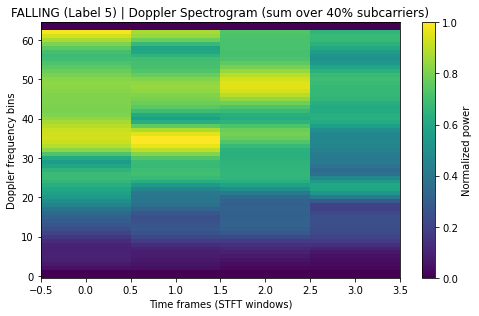

In [18]:
FALLING_LABEL = 5  # as per dataset order

# pick one FALLING file from test set
fall_idxs = np.where(y_test == FALLING_LABEL)[0]

if len(fall_idxs) == 0:
    print("No FALLING samples found in y_test!")
else:
    idx = fall_idxs[0]              # take the first falling sample
    fall_path = test_paths[idx]
    print("FALLING example file:", fall_path)

    plot_aggregated_spectrogram(fall_path, label_name="FALLING (Label 5)")


## Spectogram for jumping

JUMPING example file: D:\PROJECT\Dataset\csi_data2d\train\4\p2_d3_t27.mat


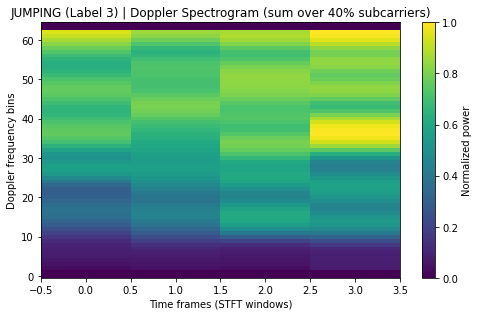

In [8]:
JUMPING_LABEL = 3  # dataset order

jump_idxs = np.where(y_test == JUMPING_LABEL)[0]

if len(jump_idxs) == 0:
    print("No JUMPING samples found in y_test!")
else:
    idx = jump_idxs[0]  # take first jumping sample
    jump_path = test_paths[idx]
    print("JUMPING example file:", jump_path)

    plot_aggregated_spectrogram(jump_path, label_name="JUMPING (Label 3)")


## Spectogram for waving using STFT

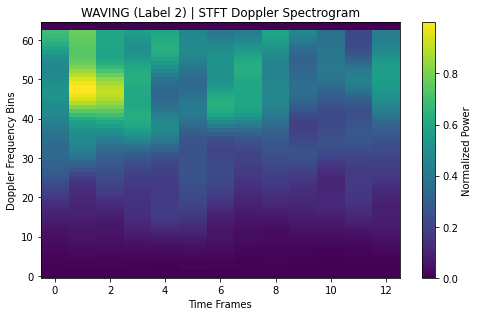

In [9]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft

# -------- STFT parameters --------
FS = 20           # sampling rate (same as before)
NFFT = 128
NPERSEG = 20      # try 20 for smoother result
HOP = 5
NOVERLAP = NPERSEG - HOP

WAVING_LABEL = 2

selected_subcarriers = np.load("selected_subcarriers_40.npy")

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]
    return csi[:, 0::2] + 1j * csi[:, 1::2]

def plot_stft_spectrogram(mat_path, label_name="WAVING"):
    csi = load_csi_complex(mat_path)
    
    # Phase → Phase difference
    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)   # (79,135)

    # Select 40% subcarriers
    pdiff_sel = pdiff[:, selected_subcarriers]

    # Aggregate STFT across subcarriers
    S_total = None

    for k in range(pdiff_sel.shape[1]):
        f, t, Zxx = stft(
            pdiff_sel[:, k],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None
        )
        
        P = np.abs(Zxx) ** 2  # Doppler power
        
        if S_total is None:
            S_total = P
        else:
            S_total += P

    # Remove DC and extreme bins for clarity
    S_total[:2, :] = 0
    S_total[-2:, :] = 0

    # Log + normalize for visualization
    S_total = np.log1p(5.0 * S_total)
    S_total = (S_total - S_total.min()) / (S_total.max() - S_total.min() + 1e-8)

    plt.figure(figsize=(7,4.5))
    plt.imshow(S_total, aspect="auto", origin="lower")
    plt.title(f"{label_name} | STFT Doppler Spectrogram")
    plt.xlabel("Time Frames")
    plt.ylabel("Doppler Frequency Bins")
    plt.colorbar(label="Normalized Power")
    plt.tight_layout()
    plt.show()


# Pick one WAVING sample
idx = np.where(y_test == WAVING_LABEL)[0][0]
wav_path = test_paths[idx]

plot_stft_spectrogram(wav_path, label_name="WAVING (Label 2)")


STFT frames (columns) = 4


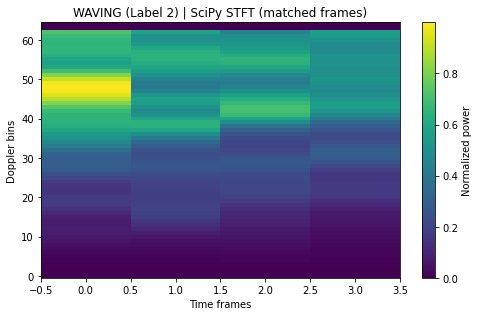

In [10]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft

# ---- set SAME params as your manual FFT-STFT ----
FS = 20
NFFT = 128
NPERSEG = 40    
HOP = 10         
NOVERLAP = NPERSEG - HOP

WAVING_LABEL = 2
selected_subcarriers = np.load("selected_subcarriers_40.npy")

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]
    return csi[:, 0::2] + 1j * csi[:, 1::2]

def plot_stft_same_frames(mat_path, label_name="WAVING"):
    csi = load_csi_complex(mat_path)
    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)  # (79,135)

    pdiff_sel = pdiff[:, selected_subcarriers]  # (79,S)

    S_total = None
    for k in range(pdiff_sel.shape[1]):
        f, t, Zxx = stft(
            pdiff_sel[:, k],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None,     # IMPORTANT: no padding at boundaries
            padded=False       # IMPORTANT: do not pad signal
        )
        P = np.abs(Zxx) ** 2  # (F,M)

        if S_total is None:
            S_total = P
        else:
            S_total += P

    # Remove DC & extreme bins (same as before)
    S_total[:2, :] = 0
    S_total[-2:, :] = 0

    # Log + normalize (same visual scaling)
    S_total = np.log1p(5.0 * S_total)
    S_total = (S_total - S_total.min()) / (S_total.max() - S_total.min() + 1e-8)

    print("STFT frames (columns) =", S_total.shape[1])

    plt.figure(figsize=(7,4.5))
    plt.imshow(S_total, aspect="auto", origin="lower")
    plt.title(f"{label_name} | SciPy STFT (matched frames)")
    plt.xlabel("Time frames")
    plt.ylabel("Doppler bins")
    plt.colorbar(label="Normalized power")
    plt.tight_layout()
    plt.show()

# Pick one waving sample from test set
idx = np.where(y_test == WAVING_LABEL)[0][0]
wav_path = test_paths[idx]

plot_stft_same_frames(wav_path, label_name="WAVING (Label 2)")


## Spectogram for Jumping using STFT

JUMPING example file: D:\PROJECT\Dataset\csi_data2d\train\4\p2_d3_t27.mat


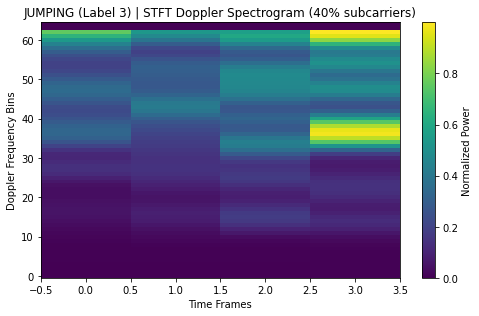

In [4]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft

# -------- STFT parameters (use same as your latest try) --------
FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
NOVERLAP = NPERSEG - HOP

JUMPING_LABEL = 3  # jumping

# load 40% selected subcarriers
selected_subcarriers = np.load("selected_subcarriers_40.npy")

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]
    return csi[:, 0::2] + 1j * csi[:, 1::2]

def plot_stft_spectrogram(mat_path, label_name="JUMPING"):
    csi = load_csi_complex(mat_path)

    # Phase → Phase difference
    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)  # (79,135)

    # Select subcarriers (40%)
    pdiff_sel = pdiff[:, selected_subcarriers]

    # Aggregate Doppler power across subcarriers
    S_total = None
    for k in range(pdiff_sel.shape[1]):
        f, t, Zxx = stft(
            pdiff_sel[:, k],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None,
            padded=False
        )
        P = np.abs(Zxx) ** 2

        if S_total is None:
            S_total = P
        else:
            S_total += P

    # Clean edges
    S_total[:2, :] = 0
    S_total[-2:, :] = 0

    # Log + normalize for visualization
    S_total = np.log1p(5.0 * S_total)
    S_total = (S_total - S_total.min()) / (S_total.max() - S_total.min() + 1e-8)

    plt.figure(figsize=(7,4.5))
    plt.imshow(S_total, aspect="auto", origin="lower")
    plt.title(f"{label_name} | STFT Doppler Spectrogram (40% subcarriers)")
    plt.xlabel("Time Frames")
    plt.ylabel("Doppler Frequency Bins")
    plt.colorbar(label="Normalized Power")
    plt.tight_layout()
    plt.show()

# Pick one JUMPING sample from test set
idx = np.where(y_test == JUMPING_LABEL)[0][0]
jump_path = test_paths[idx]
print("JUMPING example file:", jump_path)

plot_stft_spectrogram(jump_path, label_name="JUMPING (Label 3)")


## Spectogram for falling using STFT

FALLING example file: D:\PROJECT\Dataset\csi_data2d\train\6\p2_d7_t48.mat


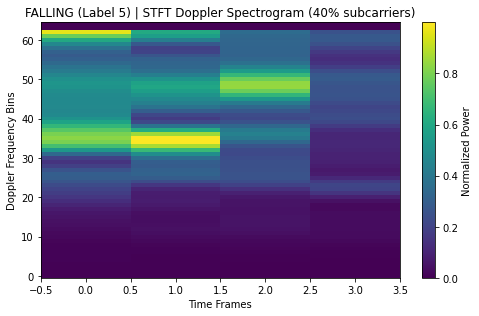

In [24]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft

# -------- STFT parameters (keep same for fair comparison) --------
FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
NOVERLAP = NPERSEG - HOP

FALLING_LABEL = 5  # falling

selected_subcarriers = np.load("selected_subcarriers_40.npy")

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]
    return csi[:, 0::2] + 1j * csi[:, 1::2]

def plot_stft_spectrogram(mat_path, label_name="FALLING"):
    csi = load_csi_complex(mat_path)

    # Phase - Phase difference
    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)  # (79,135)

    # Select 40% subcarriers
    pdiff_sel = pdiff[:, selected_subcarriers]

    # Aggregate STFT power across subcarriers
    S_total = None
    for k in range(pdiff_sel.shape[1]):
        f, t, Zxx = stft(
            pdiff_sel[:, k],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None,
            padded=False
        )

        P = np.abs(Zxx) ** 2  # Doppler power

        if S_total is None:
            S_total = P
        else:
            S_total += P

    # Remove extreme bins for clarity
    S_total[:2, :] = 0
    S_total[-2:, :] = 0

    # Log compression + normalization
    S_total = np.log1p(5.0 * S_total)
    S_total = (S_total - S_total.min()) / (S_total.max() - S_total.min() + 1e-8)

    plt.figure(figsize=(7,4.5))
    plt.imshow(S_total, aspect="auto", origin="lower")
    plt.title(f"{label_name} | STFT Doppler Spectrogram (40% subcarriers)")
    plt.xlabel("Time Frames")
    plt.ylabel("Doppler Frequency Bins")
    plt.colorbar(label="Normalized Power")
    plt.tight_layout()
    plt.show()

# Pick one FALLING sample from test set
idx = np.where(y_test == FALLING_LABEL)[0][0]
fall_path = test_paths[idx]
print("FALLING example file:", fall_path)

plot_stft_spectrogram(fall_path, label_name="FALLING (Label 5)")


## Spectogram for clapping using STFT

CLAPPING example file: D:\PROJECT\Dataset\csi_data2d\train\1\p1_d1_t46.mat


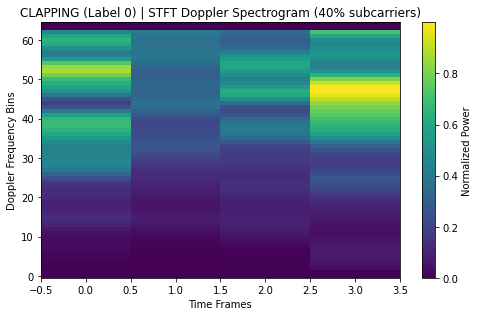

In [6]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft

# -------- STFT parameters (keep same for fair comparison) --------
FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
NOVERLAP = NPERSEG - HOP

CLAPPING_LABEL = 0  # clapping

selected_subcarriers = np.load("selected_subcarriers_40.npy")

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]
    return csi[:, 0::2] + 1j * csi[:, 1::2]

def plot_stft_spectrogram(mat_path, label_name="CLAPPING"):
    csi = load_csi_complex(mat_path)

    # Phase → Phase difference
    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)  # (79,135)

    # Select 40% subcarriers
    pdiff_sel = pdiff[:, selected_subcarriers]

    # Aggregate STFT power across subcarriers
    S_total = None
    for k in range(pdiff_sel.shape[1]):
        f, t, Zxx = stft(
            pdiff_sel[:, k],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None,
            padded=False
        )
        P = np.abs(Zxx) ** 2

        if S_total is None:
            S_total = P
        else:
            S_total += P

    # Clean extreme bins
    S_total[:2, :] = 0
    S_total[-2:, :] = 0

    # Log + normalize for visualization
    S_total = np.log1p(5.0 * S_total)
    S_total = (S_total - S_total.min()) / (S_total.max() - S_total.min() + 1e-8)

    plt.figure(figsize=(7,4.5))
    plt.imshow(S_total, aspect="auto", origin="lower")
    plt.title(f"{label_name} | STFT Doppler Spectrogram (40% subcarriers)")
    plt.xlabel("Time Frames")
    plt.ylabel("Doppler Frequency Bins")
    plt.colorbar(label="Normalized Power")
    plt.tight_layout()
    plt.show()

# Pick one CLAPPING sample from test set
idx = np.where(y_test == CLAPPING_LABEL)[0][0]
clap_path = test_paths[idx]
print("CLAPPING example file:", clap_path)

plot_stft_spectrogram(clap_path, label_name="CLAPPING (Label 0)")


## Spectogram for walking using STFT

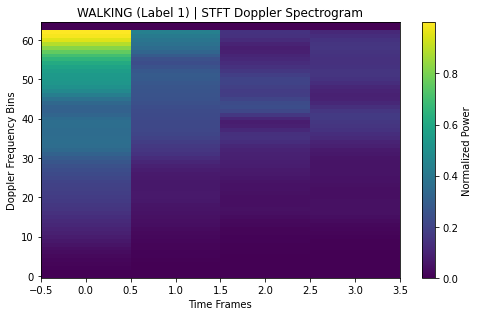

In [14]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft

# -------- STFT parameters (same as before) --------
FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
NOVERLAP = NPERSEG - HOP

WALKING_LABEL = 1
SITTING_LABEL = 4

selected_subcarriers = np.load("selected_subcarriers_40.npy")

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]
    return csi[:, 0::2] + 1j * csi[:, 1::2]

def compute_stft_spectrogram(mat_path):
    csi = load_csi_complex(mat_path)

    phase = np.unwrap(np.angle(csi), axis=0)
    pdiff = np.diff(phase, axis=0)

    pdiff_sel = pdiff[:, selected_subcarriers]

    S_total = None
    for k in range(pdiff_sel.shape[1]):
        f, t, Zxx = stft(
            pdiff_sel[:, k],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None,
            padded=False
        )
        P = np.abs(Zxx) ** 2

        if S_total is None:
            S_total = P
        else:
            S_total += P

    S_total[:2, :] = 0
    S_total[-2:, :] = 0

    S_total = np.log1p(5.0 * S_total)
    S_total = (S_total - S_total.min()) / (S_total.max() - S_total.min() + 1e-8)

    return S_total

def plot_spectrogram(S, title):
    plt.figure(figsize=(7,4.5))
    plt.imshow(S, aspect="auto", origin="lower")
    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Doppler Frequency Bins")
    plt.colorbar(label="Normalized Power")
    plt.tight_layout()
    plt.show()

# ----- WALKING -----
idx_walk = np.where(y_test == WALKING_LABEL)[0][4]
walk_path = test_paths[idx_walk]
S_walk = compute_stft_spectrogram(walk_path)
plot_spectrogram(S_walk, "WALKING (Label 1) | STFT Doppler Spectrogram")

## Spectogram for sitting using STFT

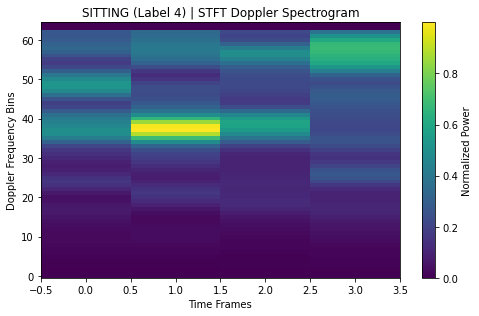

In [19]:
# ----- SITTING -----
idx_sit = np.where(y_test == SITTING_LABEL)[0][5]
sit_path = test_paths[idx_sit]
S_sit = compute_stft_spectrogram(sit_path)
plot_spectrogram(S_sit, "SITTING (Label 4) | STFT Doppler Spectrogram")

## using all subcarriers

WAVING example file: D:\PROJECT\Dataset\csi_data2d\train\3\p1_d1_t13.mat


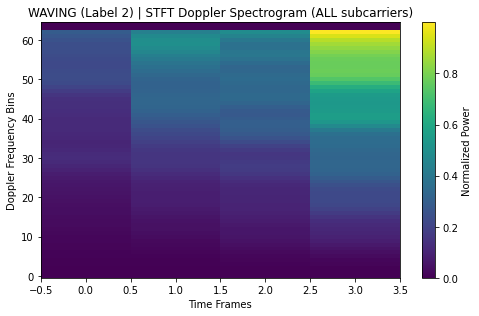

In [32]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft

# -------- STFT parameters (same as your code) --------
FS = 20
NFFT = 128
NPERSEG = 40
HOP = 10
NOVERLAP = NPERSEG - HOP

WAVING_LABEL = 2  # clapping(0), walking(1), waving(2), jumping(3), sitting(4), falling(5)

def load_csi_complex(mat_path):
    mat = sio.loadmat(mat_path)
    csi = mat["csi_1"]  # (80, 270) -> interleaved real/imag
    return csi[:, 0::2] + 1j * csi[:, 1::2]  # (80, 135)

def plot_stft_spectrogram_allsub(mat_path, label_name="WAVING"):
    csi = load_csi_complex(mat_path)

    # Phase -> unwrap along time -> phase difference
    phase = np.unwrap(np.angle(csi), axis=0)     # (80, 135)
    pdiff = np.diff(phase, axis=0)               # (79, 135)

    #  Use ALL subcarriers (no selection)
    pdiff_all = pdiff                              # (79, 135)

    # Aggregate STFT power across all subcarriers
    S_total = None
    for k in range(pdiff_all.shape[1]):
        f, t, Zxx = stft(
            pdiff_all[:, k],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None,
            padded=False
        )
        P = np.abs(Zxx) ** 2  # power

        if S_total is None:
            S_total = P
        else:
            S_total += P

    # Remove extreme bins for clarity (same as you did)
    S_total[:2, :] = 0
    S_total[-2:, :] = 0

    # Log compression + normalization (same as you did)
    S_total = np.log1p(5.0 * S_total)
    S_total = (S_total - S_total.min()) / (S_total.max() - S_total.min() + 1e-8)

    # Plot
    plt.figure(figsize=(7, 4.5))
    plt.imshow(S_total, aspect="auto", origin="lower")
    plt.title(f"{label_name} | STFT Doppler Spectrogram (ALL subcarriers)")
    plt.xlabel("Time Frames")
    plt.ylabel("Doppler Frequency Bins")
    plt.colorbar(label="Normalized Power")
    plt.tight_layout()
    plt.show()

# Pick one WAVING sample from test set (same style as your code)
idx = np.where(y_test == WAVING_LABEL)[0][3]
wave_path = test_paths[idx]
print("WAVING example file:", wave_path)

plot_stft_spectrogram_allsub(wave_path, label_name="WAVING (Label 2)")


## new code

In [2]:
from pathlib import Path

#  Step 1: Set dataset path
TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")

#  Check train folder exists
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TRAIN_DIR:", TRAIN_DIR)

#  List activity folders (should be 6)
activity_folders = sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir()])
print("\nFound folders:", len(activity_folders))

for i, folder in enumerate(activity_folders):
    mat_files = sorted(folder.glob("*.mat"))
    print(f"[{i}] {folder.name}  ->  {len(mat_files)} .mat files")


TRAIN_DIR exists: True
TRAIN_DIR: D:\PROJECT\Dataset\csi_data2d\train

Found folders: 6
[0] 1  ->  725 .mat files
[1] 2  ->  741 .mat files
[2] 3  ->  448 .mat files
[3] 4  ->  747 .mat files
[4] 5  ->  744 .mat files
[5] 6  ->  741 .mat files


In [1]:
from pathlib import Path

TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")
activity_folders = sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir()])

#  Change only these two to compare samples
ACTIVITY_FOLDER_INDEX = 2   # 0..5  (this chooses folder: 1..6)
SAMPLE_INDEX = 0            # 0..(num_files-1)

folder = activity_folders[ACTIVITY_FOLDER_INDEX]
mat_files = sorted(folder.glob("*.mat"))

print("Chosen folder:", folder.name)
print("Total .mat files in this folder:", len(mat_files))

mat_path = mat_files[SAMPLE_INDEX]
print("Chosen sample file:", mat_path)


Chosen folder: 3
Total .mat files in this folder: 448
Chosen sample file: D:\PROJECT\Dataset\csi_data2d\train\3\p1_d1_t1.mat


In [2]:
import scipy.io as sio

mat_path = r"D:\PROJECT\Dataset\csi_data2d\train\3\p1_d1_t1.mat"

# Load mat file
mat_data = sio.loadmat(mat_path)

# See what keys exist
print("Keys inside mat file:")
print(mat_data.keys())


Keys inside mat file:
dict_keys(['__header__', '__version__', '__globals__', 'csi_1'])


In [3]:
import numpy as np
import scipy.io as sio

mat_path = r"D:\PROJECT\Dataset\csi_data2d\train\3\p1_d1_t1.mat"

mat = sio.loadmat(mat_path)
csi_raw = mat["csi_1"]

print("Raw csi_1 shape:", csi_raw.shape)
print("Raw csi_1 dtype:", csi_raw.dtype)

# Convert interleaved real/imag -> complex
# (T, 270) -> (T, 135)
csi_complex = csi_raw[:, 0::2] + 1j * csi_raw[:, 1::2]

print("Complex CSI shape:", csi_complex.shape)
print("Complex CSI dtype:", csi_complex.dtype)

# quick sanity check
print("First element (complex):", csi_complex[0, 0])


Raw csi_1 shape: (80, 270)
Raw csi_1 dtype: float64
Complex CSI shape: (80, 135)
Complex CSI dtype: complex128
First element (complex): (43.41658669218482+47.51841748206689j)


##  spectogram for waving using doppler shift paper

Activity: jumping | Folder: 4
Sample index: 6
File: D:\PROJECT\Dataset\csi_data2d\train\4\p1_d1_t15.mat
Auto vmin/vmax: -54.44861930220297 -35.75828405575545
Total energy: 0.16314536815428882


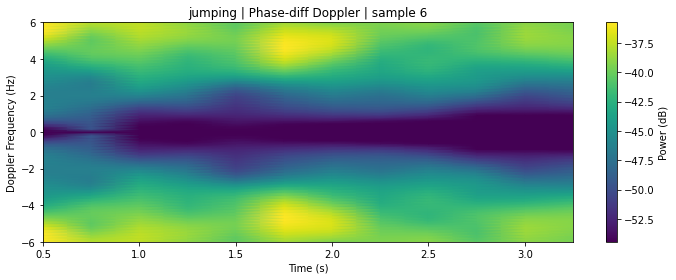

In [10]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft
from pathlib import Path

# ---------- Fixed params ----------
FS = 20
NFFT = 128

# (Better time detail for your short 80-packet signals)
NPERSEG = 20
HOP = 5
NOVERLAP = NPERSEG - HOP

TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")
LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

#  Change ONLY these two
ACTIVITY_LABEL = 3   # 3=jumping, 5=falling, 2=waving...
SAMPLE_INDEX = 6  # 0,1,2,...

# ---------- Pick file ----------
folder = TRAIN_DIR / str(ACTIVITY_LABEL + 1)   # folder "1..6"
mat_files = sorted(folder.glob("*.mat"))
mat_path = mat_files[SAMPLE_INDEX]

print("Activity:", LABELS[ACTIVITY_LABEL], "| Folder:", folder.name)
print("Sample index:", SAMPLE_INDEX)
print("File:", mat_path)

# ---------- Load CSI ----------
mat = sio.loadmat(mat_path)
csi_raw = mat["csi_1"]                          # (80,270)
csi = csi_raw[:, 0::2] + 1j * csi_raw[:, 1::2]  # (80,135)

# ---------- Phase-diff (motion focused) ----------
phase = np.unwrap(np.angle(csi), axis=0)        # (80,135)
pdiff = np.diff(phase, axis=0)                  # (79,135)

# ---------- STFT + average power over subcarriers ----------
S = None
for k in range(pdiff.shape[1]):  # all 135 subcarriers
    f, t, Z = stft(
        pdiff[:, k],
        fs=FS,
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
        boundary=None,
        padded=False,
        return_onesided=False
    )
    P = np.abs(Z) ** 2
    S = P if S is None else (S + P)

S = S / pdiff.shape[1]                 # average
S = np.fft.fftshift(S, axes=0)         # center 0 Hz
f = np.fft.fftshift(f)

#  Remove ONLY the exact 0-Hz bin (not +/- band)
zero_idx = np.argmin(np.abs(f))
S[zero_idx, :] = 0

# ---------- dB scale ----------
S_db = 10 * np.log10(S + 1e-12)

#  Auto contrast so it never becomes blank
vmin = np.percentile(S_db, 5)
vmax = np.percentile(S_db, 95)
print("Auto vmin/vmax:", vmin, vmax)
print("Total energy:", np.sum(S))

# ---------- Plot ----------
plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, S_db, shading="gouraud", cmap="viridis", vmin=vmin, vmax=vmax)
plt.title(f"{LABELS[ACTIVITY_LABEL]} | Phase-diff Doppler | sample {SAMPLE_INDEX}")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Frequency (Hz)")
plt.ylim(-6, 6)  # focus on human motion range
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

Activity: falling | Folder: 6
Sample index: 1
File: D:\PROJECT\Dataset\csi_data2d\train\6\p1_d1_t10.mat
Auto vmin/vmax: -53.528492422642586 -36.39634474795314
Total energy: 0.18877640097126136


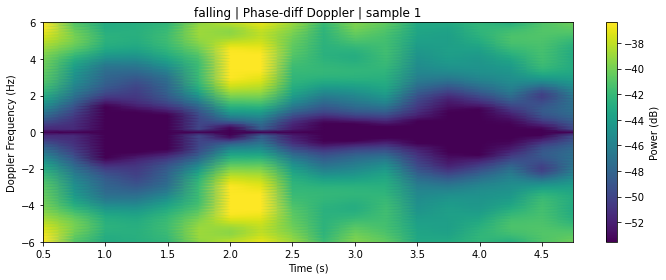

In [12]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft
from pathlib import Path

# ---------- Fixed params ----------
FS = 20
NFFT = 128

# (Better time detail for your short 80-packet signals)
NPERSEG = 20
HOP = 5
NOVERLAP = NPERSEG - HOP

TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")
LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

#  Change ONLY these two
ACTIVITY_LABEL = 5   # 3=jumping, 5=falling, 2=waving...
SAMPLE_INDEX = 1    # 0,1,2,...

# ---------- Pick file ----------
folder = TRAIN_DIR / str(ACTIVITY_LABEL + 1)   # folder "1..6"
mat_files = sorted(folder.glob("*.mat"))
mat_path = mat_files[SAMPLE_INDEX]

print("Activity:", LABELS[ACTIVITY_LABEL], "| Folder:", folder.name)
print("Sample index:", SAMPLE_INDEX)
print("File:", mat_path)

# ---------- Load CSI ----------
mat = sio.loadmat(mat_path)
csi_raw = mat["csi_1"]                          # (80,270)
csi = csi_raw[:, 0::2] + 1j * csi_raw[:, 1::2]  # (80,135)

# ---------- Phase-diff (motion focused) ----------
phase = np.unwrap(np.angle(csi), axis=0)        # (80,135)
pdiff = np.diff(phase, axis=0)                  # (79,135)

# ---------- STFT + average power over subcarriers ----------
S = None
for k in range(pdiff.shape[1]):  # all 135 subcarriers
    f, t, Z = stft(
        pdiff[:, k],
        fs=FS,
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
        boundary=None,
        padded=False,
        return_onesided=False
    )
    P = np.abs(Z) ** 2
    S = P if S is None else (S + P)

S = S / pdiff.shape[1]                 # average
S = np.fft.fftshift(S, axes=0)         # center 0 Hz
f = np.fft.fftshift(f)

# Remove ONLY the exact 0-Hz bin (not +/- band)
zero_idx = np.argmin(np.abs(f))
S[zero_idx, :] = 0

# ---------- dB scale ----------
S_db = 10 * np.log10(S + 1e-12)

# Auto contrast so it never becomes blank
vmin = np.percentile(S_db, 5)
vmax = np.percentile(S_db, 95)
print("Auto vmin/vmax:", vmin, vmax)
print("Total energy:", np.sum(S))

# ---------- Plot ----------
plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, S_db, shading="gouraud", cmap="viridis", vmin=vmin, vmax=vmax)
plt.title(f"{LABELS[ACTIVITY_LABEL]} | Phase-diff Doppler | sample {SAMPLE_INDEX}")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Frequency (Hz)")
plt.ylim(-6, 6)  # focus on human motion range
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

Activity: waving | Folder: 3
Sample index: 2
File: D:\PROJECT\Dataset\csi_data2d\train\3\p1_d1_t11.mat
Auto vmin/vmax: -54.89289931017312 -35.00563125542709
Total energy: 0.1661421812841335


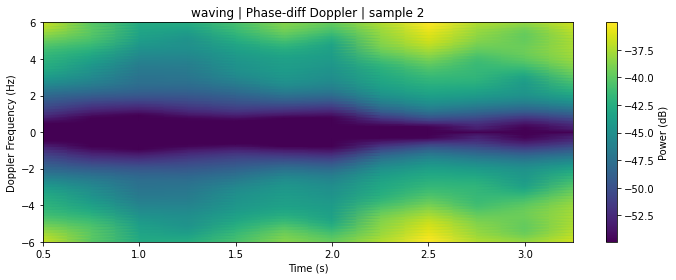

In [17]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft
from pathlib import Path

# ---------- Fixed params ----------
FS = 20
NFFT = 128

# (Better time detail for your short 80-packet signals)
NPERSEG = 20
HOP = 5
NOVERLAP = NPERSEG - HOP

TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")
LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

#  Change ONLY these two
ACTIVITY_LABEL = 2   # 3=jumping, 5=falling, 2=waving...
SAMPLE_INDEX = 2    # 0,1,2,...

# ---------- Pick file ----------
folder = TRAIN_DIR / str(ACTIVITY_LABEL + 1)   # folder "1..6"
mat_files = sorted(folder.glob("*.mat"))
mat_path = mat_files[SAMPLE_INDEX]

print("Activity:", LABELS[ACTIVITY_LABEL], "| Folder:", folder.name)
print("Sample index:", SAMPLE_INDEX)
print("File:", mat_path)

# ---------- Load CSI ----------
mat = sio.loadmat(mat_path)
csi_raw = mat["csi_1"]                          # (80,270)
csi = csi_raw[:, 0::2] + 1j * csi_raw[:, 1::2]  # (80,135)

# ---------- Phase-diff (motion focused) ----------
phase = np.unwrap(np.angle(csi), axis=0)        # (80,135)
pdiff = np.diff(phase, axis=0)                  # (79,135)

# ---------- STFT + average power over subcarriers ----------
S = None
for k in range(pdiff.shape[1]):  # all 135 subcarriers
    f, t, Z = stft(
        pdiff[:, k],
        fs=FS,
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
        boundary=None,
        padded=False,
        return_onesided=False
    )
    P = np.abs(Z) ** 2
    S = P if S is None else (S + P)

S = S / pdiff.shape[1]                 # average
S = np.fft.fftshift(S, axes=0)         # center 0 Hz
f = np.fft.fftshift(f)

# Remove ONLY the exact 0-Hz bin (not +/- band)
zero_idx = np.argmin(np.abs(f))
S[zero_idx, :] = 0

# ---------- dB scale ----------
S_db = 10 * np.log10(S + 1e-12)

# Auto contrast so it never becomes blank
vmin = np.percentile(S_db, 5)
vmax = np.percentile(S_db, 95)
print("Auto vmin/vmax:", vmin, vmax)
print("Total energy:", np.sum(S))

# ---------- Plot ----------
plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, S_db, shading="gouraud", cmap="viridis", vmin=vmin, vmax=vmax)
plt.title(f"{LABELS[ACTIVITY_LABEL]} | Phase-diff Doppler | sample {SAMPLE_INDEX}")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Frequency (Hz)")
plt.ylim(-6, 6)  # focus on human motion range
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

## After removing static components

Activity: waving | Folder: 3
Sample index: 2
File: D:\PROJECT\Dataset\csi_data2d\train\3\p1_d1_t11.mat
Max phase diff: 3.141580841181239
Auto vmin/vmax: -11.38057405815695 -5.65492281085078


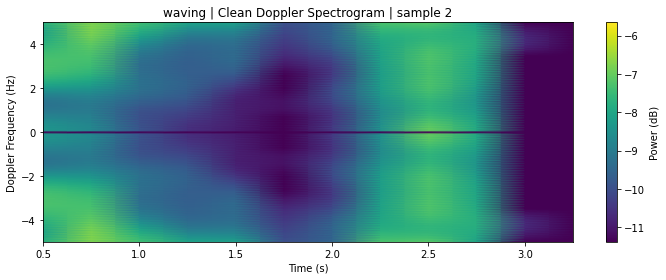

In [30]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft
from pathlib import Path

# ---------------- Fixed params ----------------
FS = 20

# Better time detail for your 80-packet signals
NPERSEG = 20
HOP = 5
NOVERLAP = NPERSEG - HOP

# Higher frequency resolution
NFFT = 256

TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")
LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

#  Change ONLY these two
ACTIVITY_LABEL = 2   # 0..5  (2=waving, 3=jumping, 5=falling)
SAMPLE_INDEX =  2   # 0,1,2,...

# ---------------- Pick file ----------------
folder = TRAIN_DIR / str(ACTIVITY_LABEL + 1)  # folder "1..6"
mat_files = sorted(folder.glob("*.mat"))

if len(mat_files) == 0:
    raise RuntimeError(f"No .mat files found in folder: {folder}")

if SAMPLE_INDEX >= len(mat_files):
    raise IndexError(f"SAMPLE_INDEX={SAMPLE_INDEX} out of range. Max = {len(mat_files)-1}")

mat_path = mat_files[SAMPLE_INDEX]

print("Activity:", LABELS[ACTIVITY_LABEL], "| Folder:", folder.name)
print("Sample index:", SAMPLE_INDEX)
print("File:", mat_path)

# ---------------- Load CSI and make complex ----------------
mat = sio.loadmat(mat_path)
csi_raw = mat["csi_1"]                          # (80,270)
csi = csi_raw[:, 0::2] + 1j * csi_raw[:, 1::2]  # (80,135)

# ---------------- (1) Remove static component (global) ----------------
# This removes static multipath across the whole sample
csi = csi - np.mean(csi, axis=0, keepdims=True)

# ---------------- (2) Phase -> unwrap -> diff (motion focused) ----------------
phase = np.unwrap(np.angle(csi), axis=0)     # (80,135)
pdiff = np.diff(phase, axis=0)               # (79,135)

print("Max phase diff:", np.max(np.abs(pdiff)))

# ---------------- (3) STFT + average power across subcarriers ----------------
S = None
for k in range(pdiff.shape[1]):  # all 135 subcarriers
    f, t, Z = stft(
        pdiff[:, k],
        fs=FS,
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
        return_onesided=False,
        boundary=None,
        padded=False
    )
    P = np.abs(Z) ** 2
    S = P if S is None else (S + P)

S = S / pdiff.shape[1]

# ---------------- (4) Center 0 Hz and remove ONLY exact DC bin ----------------
S = np.fft.fftshift(S, axes=0)
f = np.fft.fftshift(f)

zero_idx = np.argmin(np.abs(f))   # closest to 0 Hz
S[zero_idx, :] = 0

# ---------------- (5) Convert to dB + auto scaling ----------------
S_db = 10 * np.log10(S + 1e-10)

# Auto contrast so plots don’t look blank or all-yellow
vmin = np.percentile(S_db, 10)
vmax = np.percentile(S_db, 98)
print("Auto vmin/vmax:", vmin, vmax)

# ---------------- Plot ----------------
plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, S_db, shading="gouraud", cmap="viridis", vmin=vmin, vmax=vmax)

# Focus on typical human motion Doppler band
plt.ylim(-5, 5)

plt.title(f"{LABELS[ACTIVITY_LABEL]} | Clean Doppler Spectrogram | sample {SAMPLE_INDEX}")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Frequency (Hz)")
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

In [20]:
print("Max phase diff:", np.max(np.abs(pdiff)))

Max phase diff: 0.8960026425810987


Activity: jumping | Folder: 4
Sample index: 1
File: D:\PROJECT\Dataset\csi_data2d\train\4\p1_d1_t10.mat
Max phase diff: 3.141560800926916
Auto vmin/vmax: -8.470235828413253 -4.536925001659517


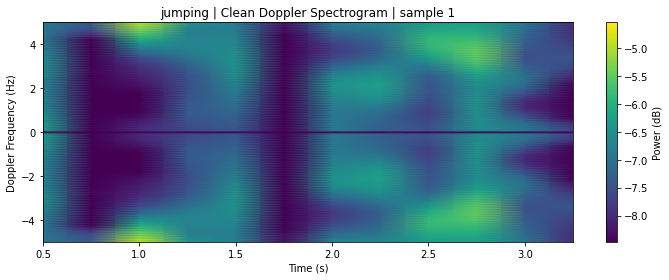

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft
from pathlib import Path

# ---------------- Fixed params ----------------
FS = 20

# Better time detail for your 80-packet signals
NPERSEG = 20
HOP = 5
NOVERLAP = NPERSEG - HOP

# Higher frequency resolution
NFFT = 256

TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")
LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

#  Change ONLY these two
ACTIVITY_LABEL = 3   # 0..5  (2=waving, 3=jumping, 5=falling)
SAMPLE_INDEX =  1   # 0,1,2,...

# ---------------- Pick file ----------------
folder = TRAIN_DIR / str(ACTIVITY_LABEL + 1)  # folder "1..6"
mat_files = sorted(folder.glob("*.mat"))

if len(mat_files) == 0:
    raise RuntimeError(f"No .mat files found in folder: {folder}")

if SAMPLE_INDEX >= len(mat_files):
    raise IndexError(f"SAMPLE_INDEX={SAMPLE_INDEX} out of range. Max = {len(mat_files)-1}")

mat_path = mat_files[SAMPLE_INDEX]

print("Activity:", LABELS[ACTIVITY_LABEL], "| Folder:", folder.name)
print("Sample index:", SAMPLE_INDEX)
print("File:", mat_path)

# ---------------- Load CSI and make complex ----------------
mat = sio.loadmat(mat_path)
csi_raw = mat["csi_1"]                          # (80,270)
csi = csi_raw[:, 0::2] + 1j * csi_raw[:, 1::2]  # (80,135)

# ---------------- (1) Remove static component (global) ----------------
# This removes static multipath across the whole sample
csi = csi - np.mean(csi, axis=0, keepdims=True)

# ---------------- (2) Phase -> unwrap -> diff (motion focused) ----------------
phase = np.unwrap(np.angle(csi), axis=0)     # (80,135)
pdiff = np.diff(phase, axis=0)               # (79,135)

print("Max phase diff:", np.max(np.abs(pdiff)))

# ---------------- (3) STFT + average power across subcarriers ----------------
S = None
for k in range(pdiff.shape[1]):  # all 135 subcarriers
    f, t, Z = stft(
        pdiff[:, k],
        fs=FS,
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
        return_onesided=False,
        boundary=None,
        padded=False
    )
    P = np.abs(Z) ** 2
    S = P if S is None else (S + P)

S = S / pdiff.shape[1]

# ---------------- (4) Center 0 Hz and remove ONLY exact DC bin ----------------
S = np.fft.fftshift(S, axes=0)
f = np.fft.fftshift(f)

zero_idx = np.argmin(np.abs(f))   # closest to 0 Hz
S[zero_idx, :] = 0

# ---------------- (5) Convert to dB + auto scaling ----------------
S_db = 10 * np.log10(S + 1e-10)

# Auto contrast so plots don’t look blank or all-yellow
vmin = np.percentile(S_db, 10)
vmax = np.percentile(S_db, 98)
print("Auto vmin/vmax:", vmin, vmax)

# ---------------- Plot ----------------
plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, S_db, shading="gouraud", cmap="viridis", vmin=vmin, vmax=vmax)

# Focus on typical human motion Doppler band
plt.ylim(-5, 5)

plt.title(f"{LABELS[ACTIVITY_LABEL]} | Clean Doppler Spectrogram | sample {SAMPLE_INDEX}")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Frequency (Hz)")
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

Activity: clapping | Folder: 1
Sample index: 5
File: D:\PROJECT\Dataset\csi_data2d\train\1\p1_d1_t14.mat
Max phase diff: 3.1415484466384838
Auto vmin/vmax: -7.929535224280383 -3.0138338860614344


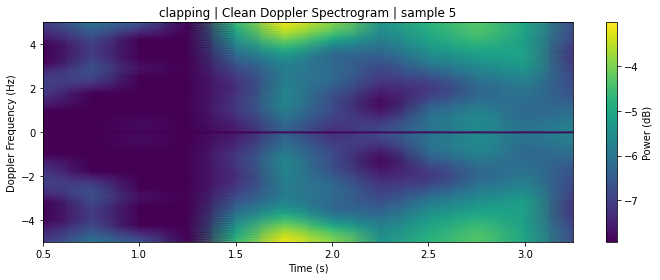

In [9]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft
from pathlib import Path

# ---------------- Fixed params ----------------
FS = 20

# Better time detail for your 80-packet signals
NPERSEG = 20
HOP = 5
NOVERLAP = NPERSEG - HOP

# Higher frequency resolution
NFFT = 256

TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")
LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

#  Change ONLY these two
ACTIVITY_LABEL = 0   # 0..5  (2=waving, 3=jumping, 5=falling)
SAMPLE_INDEX =  5  # 0,1,2,...

# ---------------- Pick file ----------------
folder = TRAIN_DIR / str(ACTIVITY_LABEL + 1)  # folder "1..6"
mat_files = sorted(folder.glob("*.mat"))

if len(mat_files) == 0:
    raise RuntimeError(f"No .mat files found in folder: {folder}")

if SAMPLE_INDEX >= len(mat_files):
    raise IndexError(f"SAMPLE_INDEX={SAMPLE_INDEX} out of range. Max = {len(mat_files)-1}")

mat_path = mat_files[SAMPLE_INDEX]

print("Activity:", LABELS[ACTIVITY_LABEL], "| Folder:", folder.name)
print("Sample index:", SAMPLE_INDEX)
print("File:", mat_path)

# ---------------- Load CSI and make complex ----------------
mat = sio.loadmat(mat_path)
csi_raw = mat["csi_1"]                          # (80,270)
csi = csi_raw[:, 0::2] + 1j * csi_raw[:, 1::2]  # (80,135)

# ---------------- (1) Remove static component (global) ----------------
# This removes static multipath across the whole sample
csi = csi - np.mean(csi, axis=0, keepdims=True)

# ---------------- (2) Phase -> unwrap -> diff (motion focused) ----------------
phase = np.unwrap(np.angle(csi), axis=0)     # (80,135)
pdiff = np.diff(phase, axis=0)               # (79,135)

print("Max phase diff:", np.max(np.abs(pdiff)))

# ---------------- (3) STFT + average power across subcarriers ----------------
S = None
for k in range(pdiff.shape[1]):  # all 135 subcarriers
    f, t, Z = stft(
        pdiff[:, k],
        fs=FS,
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
        return_onesided=False,
        boundary=None,
        padded=False
    )
    P = np.abs(Z) ** 2
    S = P if S is None else (S + P)

S = S / pdiff.shape[1]

# ---------------- (4) Center 0 Hz and remove ONLY exact DC bin ----------------
S = np.fft.fftshift(S, axes=0)
f = np.fft.fftshift(f)

zero_idx = np.argmin(np.abs(f))   # closest to 0 Hz
S[zero_idx, :] = 0

# ---------------- (5) Convert to dB + auto scaling ----------------
S_db = 10 * np.log10(S + 1e-10)

# Auto contrast so plots don’t look blank or all-yellow
vmin = np.percentile(S_db, 10)
vmax = np.percentile(S_db, 98)
print("Auto vmin/vmax:", vmin, vmax)

# ---------------- Plot ----------------
plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, S_db, shading="gouraud", cmap="viridis", vmin=vmin, vmax=vmax)

# Focus on typical human motion Doppler band
plt.ylim(-5, 5)

plt.title(f"{LABELS[ACTIVITY_LABEL]} | Clean Doppler Spectrogram | sample {SAMPLE_INDEX}")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Frequency (Hz)")
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

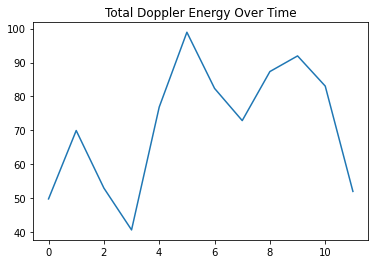

In [10]:
motion_energy = np.sum(S, axis=0)
plt.plot(motion_energy)
plt.title("Total Doppler Energy Over Time")
plt.show()

## different time range for different sample

Activity: waving | Folder: 3
Sample index: 4
File: D:\PROJECT\Dataset\csi_data2d\train\3\p1_d1_t13.mat
Max phase diff: 3.141258902558355
Auto time range: 0.95 s  to  2.30 s


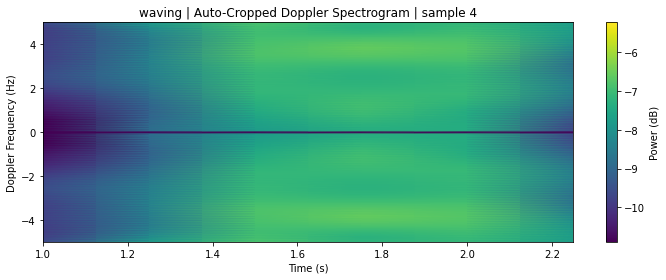

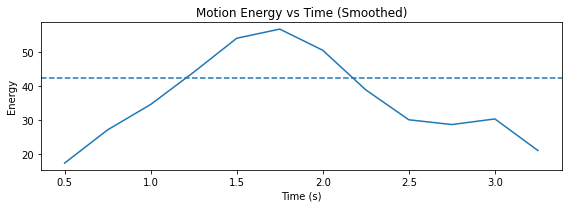

In [27]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft
from pathlib import Path

# ---------------- Dataset ----------------
TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")
LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

#  Change ONLY these
ACTIVITY_LABEL = 2   # 0..5  (2=waving, 3=jumping, 5=falling)
SAMPLE_INDEX = 4  # 0,1,2,...

# ---------------- STFT params (good for 80 packets) ----------------
FS = 20
NPERSEG = 20
HOP = 5
NOVERLAP = NPERSEG - HOP
NFFT = 256

# ---------------- Pick file ----------------
folder = TRAIN_DIR / str(ACTIVITY_LABEL + 1)  # folder "1..6"
mat_files = sorted(folder.glob("*.mat"))

if len(mat_files) == 0:
    raise RuntimeError(f"No .mat files found in folder: {folder}")

if SAMPLE_INDEX >= len(mat_files):
    raise IndexError(f"SAMPLE_INDEX={SAMPLE_INDEX} out of range. Max={len(mat_files)-1}")

mat_path = mat_files[SAMPLE_INDEX]

print("Activity:", LABELS[ACTIVITY_LABEL], "| Folder:", folder.name)
print("Sample index:", SAMPLE_INDEX)
print("File:", mat_path)

# ---------------- Load CSI ----------------
mat = sio.loadmat(mat_path)
csi_raw = mat["csi_1"]                          # (80,270)
csi = csi_raw[:, 0::2] + 1j * csi_raw[:, 1::2]  # (80,135)

# ---------------- (1) Remove static component ----------------
csi = csi - np.mean(csi, axis=0, keepdims=True)

# ---------------- (2) Phase -> unwrap -> diff ----------------
phase = np.unwrap(np.angle(csi), axis=0)        # (80,135)
pdiff = np.diff(phase, axis=0)                  # (79,135)

print("Max phase diff:", np.max(np.abs(pdiff)))

# ---------------- (3) STFT + average across subcarriers ----------------
S = None
for k in range(pdiff.shape[1]):
    f, t, Z = stft(
        pdiff[:, k],
        fs=FS,
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
        return_onesided=False,
        boundary=None,
        padded=False
    )
    P = np.abs(Z) ** 2
    S = P if S is None else (S + P)

S = S / pdiff.shape[1]

# ---------------- (4) Center 0 Hz + remove exact DC ----------------
S = np.fft.fftshift(S, axes=0)
f = np.fft.fftshift(f)

zero_idx = np.argmin(np.abs(f))
S[zero_idx, :] = 0

# ---------------- (5) dB scale + auto contrast ----------------
S_db = 10 * np.log10(S + 1e-10)
vmin = np.percentile(S_db, 10)
vmax = np.percentile(S_db, 98)

# ---------------- (6) Auto-detect motion time range ----------------
motion_energy = np.sum(S, axis=0)

# Smooth energy curve a little
motion_energy_smooth = np.convolve(motion_energy, np.ones(3)/3, mode="same")

# Threshold for "active motion"
thr = np.mean(motion_energy_smooth) + 0.5 * np.std(motion_energy_smooth)
active = motion_energy_smooth > thr

if not np.any(active):
    t_min, t_max = t[0], t[-1]
else:
    idxs = np.where(active)[0]
    t_min, t_max = t[idxs[0]], t[idxs[-1]]

# Add padding
pad = 0.3
t_min = max(t[0], t_min - pad)
t_max = min(t[-1], t_max + pad)

print(f"Auto time range: {t_min:.2f} s  to  {t_max:.2f} s")

# Crop spectrogram
time_mask = (t >= t_min) & (t <= t_max)
t_crop = t[time_mask]
S_crop = S_db[:, time_mask]

# ---------------- Plot auto-cropped spectrogram ----------------
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_crop, f, S_crop, shading="gouraud", cmap="viridis", vmin=vmin, vmax=vmax)
plt.ylim(-5, 5)
plt.title(f"{LABELS[ACTIVITY_LABEL]} | Auto-Cropped Doppler Spectrogram | sample {SAMPLE_INDEX}")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Frequency (Hz)")
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

# ---------------- (Optional) Plot motion energy curve too ----------------
plt.figure(figsize=(8, 3))
plt.plot(t, motion_energy_smooth)
plt.axhline(thr, linestyle="--")
plt.title("Motion Energy vs Time (Smoothed)")
plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

Activity: jumping | Folder: 4
Sample index: 3
File: D:\PROJECT\Dataset\csi_data2d\train\4\p1_d1_t12.mat
Max phase diff: 3.14113881577046
Auto time range: 1.95 s  to  3.25 s


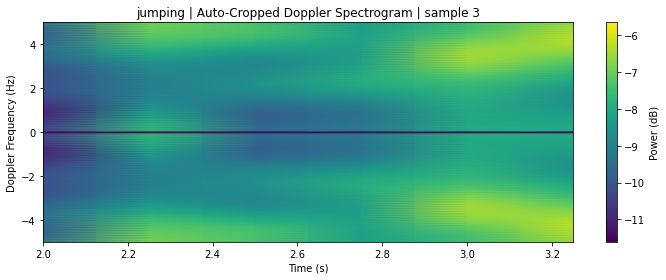

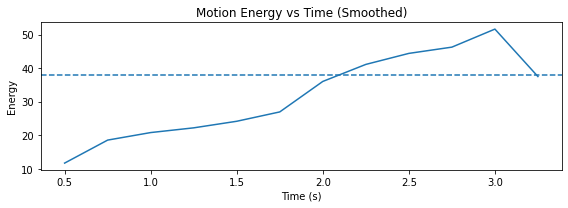

In [23]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import stft
from pathlib import Path

# ---------------- Dataset ----------------
TRAIN_DIR = Path(r"D:\PROJECT\Dataset\csi_data2d\train")
LABELS = ["clapping", "walking", "waving", "jumping", "sitting", "falling"]

#  Change ONLY these
ACTIVITY_LABEL = 3   # 0..5  (2=waving, 3=jumping, 5=falling)
SAMPLE_INDEX = 3    # 0,1,2,...

# ---------------- STFT params (good for 80 packets) ----------------
FS = 20
NPERSEG = 20
HOP = 5
NOVERLAP = NPERSEG - HOP
NFFT = 256

# ---------------- Pick file ----------------
folder = TRAIN_DIR / str(ACTIVITY_LABEL + 1)  # folder "1..6"
mat_files = sorted(folder.glob("*.mat"))

if len(mat_files) == 0:
    raise RuntimeError(f"No .mat files found in folder: {folder}")

if SAMPLE_INDEX >= len(mat_files):
    raise IndexError(f"SAMPLE_INDEX={SAMPLE_INDEX} out of range. Max={len(mat_files)-1}")

mat_path = mat_files[SAMPLE_INDEX]

print("Activity:", LABELS[ACTIVITY_LABEL], "| Folder:", folder.name)
print("Sample index:", SAMPLE_INDEX)
print("File:", mat_path)

# ---------------- Load CSI ----------------
mat = sio.loadmat(mat_path)
csi_raw = mat["csi_1"]                          # (80,270)
csi = csi_raw[:, 0::2] + 1j * csi_raw[:, 1::2]  # (80,135)

# ---------------- (1) Remove static component ----------------
csi = csi - np.mean(csi, axis=0, keepdims=True)

# ---------------- (2) Phase -> unwrap -> diff ----------------
phase = np.unwrap(np.angle(csi), axis=0)        # (80,135)
pdiff = np.diff(phase, axis=0)                  # (79,135)

print("Max phase diff:", np.max(np.abs(pdiff)))

# ---------------- (3) STFT + average across subcarriers ----------------
S = None
for k in range(pdiff.shape[1]):
    f, t, Z = stft(
        pdiff[:, k],
        fs=FS,
        nperseg=NPERSEG,
        noverlap=NOVERLAP,
        nfft=NFFT,
        return_onesided=False,
        boundary=None,
        padded=False
    )
    P = np.abs(Z) ** 2
    S = P if S is None else (S + P)

S = S / pdiff.shape[1]

# ---------------- (4) Center 0 Hz + remove exact DC ----------------
S = np.fft.fftshift(S, axes=0)
f = np.fft.fftshift(f)

zero_idx = np.argmin(np.abs(f))
S[zero_idx, :] = 0

# ---------------- (5) dB scale + auto contrast ----------------
S_db = 10 * np.log10(S + 1e-10)
vmin = np.percentile(S_db, 10)
vmax = np.percentile(S_db, 98)

# ---------------- (6) Auto-detect motion time range ----------------
motion_energy = np.sum(S, axis=0)

# Smooth energy curve a little
motion_energy_smooth = np.convolve(motion_energy, np.ones(3)/3, mode="same")

# Threshold for "active motion"
thr = np.mean(motion_energy_smooth) + 0.5 * np.std(motion_energy_smooth)
active = motion_energy_smooth > thr

if not np.any(active):
    t_min, t_max = t[0], t[-1]
else:
    idxs = np.where(active)[0]
    t_min, t_max = t[idxs[0]], t[idxs[-1]]

# Add padding
pad = 0.3
t_min = max(t[0], t_min - pad)
t_max = min(t[-1], t_max + pad)

print(f"Auto time range: {t_min:.2f} s  to  {t_max:.2f} s")

# Crop spectrogram
time_mask = (t >= t_min) & (t <= t_max)
t_crop = t[time_mask]
S_crop = S_db[:, time_mask]

# ---------------- Plot auto-cropped spectrogram ----------------
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_crop, f, S_crop, shading="gouraud", cmap="viridis", vmin=vmin, vmax=vmax)
plt.ylim(-5, 5)
plt.title(f"{LABELS[ACTIVITY_LABEL]} | Auto-Cropped Doppler Spectrogram | sample {SAMPLE_INDEX}")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Frequency (Hz)")
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

# ---------------- (Optional) Plot motion energy curve too ----------------
plt.figure(figsize=(8, 3))
plt.plot(t, motion_energy_smooth)
plt.axhline(thr, linestyle="--")
plt.title("Motion Energy vs Time (Smoothed)")
plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

## own experiment

In [2]:
import os
import numpy as np
from scipy.io import savemat

# Input dataset folder
input_folder = r"D:/PROJECT/Dataset/wifi dataset own"

# Output folder for .mat files
#output_folder = os.path.join(input_folder, "mat_files")
output_folder = r"D:/PROJECT/Dataset/wifi_dataset_own_mat"

os.makedirs(output_folder, exist_ok=True)

def read_dat_file(filepath):
    with open(filepath, "rb") as f:
        data = np.fromfile(f, dtype=np.uint8)
    return data

# Convert all .dat files
for file in os.listdir(input_folder):
    
    if file.endswith(".dat"):
        
        dat_path = os.path.join(input_folder, file)
        print("Converting:", file)

        data = read_dat_file(dat_path)

        mat_name = file.replace(".dat", ".mat")
        mat_path = os.path.join(output_folder, mat_name)

        savemat(mat_path, {"csi_raw": data})

print("All files converted successfully!")

Converting: clap_p1_t1.dat
Converting: clap_p1_t2.dat
Converting: clap_p1_t3.dat
Converting: clap_p1_t4.dat
Converting: clap_p1_t5.dat
Converting: clap_p2_t1.dat
Converting: clap_p2_t2.dat
Converting: clap_p2_t3.dat
Converting: clap_p2_t4.dat
Converting: clap_p2_t5.dat
Converting: jump_p1_t1.dat
Converting: jump_p1_t2.dat
Converting: jump_p1_t3.dat
Converting: jump_p1_t4.dat
Converting: jump_p1_t5.dat
Converting: jump_p2_t1.dat
Converting: jump_p2_t2.dat
Converting: jump_p2_t3.dat
Converting: jump_p2_t4.dat
Converting: jump_p2_t5.dat
Converting: sit_p1_t1.dat
Converting: sit_p1_t2.dat
Converting: sit_p1_t3.dat
Converting: sit_p1_t4.dat
Converting: sit_p1_t5.dat
Converting: sit_p2_t1.dat
Converting: sit_p2_t2.dat
Converting: sit_p2_t3.dat
Converting: sit_p2_t4.dat
Converting: sit_p2_t5.dat
Converting: walk_p1_t1.dat
Converting: walk_p1_t2.dat
Converting: walk_p1_t3.dat
Converting: walk_p1_t4.dat
Converting: walk_p1_t5.dat
Converting: walk_p2_t1.dat
Converting: walk_p2_t2.dat
Converting:

In [3]:
from scipy.io import loadmat

data = loadmat(r"D:/PROJECT/Dataset/wifi_dataset_own_mat/clap_p1_t1.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'csi_raw'])


In [4]:
csi = data['csi_raw']
print(csi.shape)

(1, 25300)


In [5]:
print(type(data['csi_raw']))
print(data['csi_raw'].shape)

<class 'numpy.ndarray'>
(1, 25300)


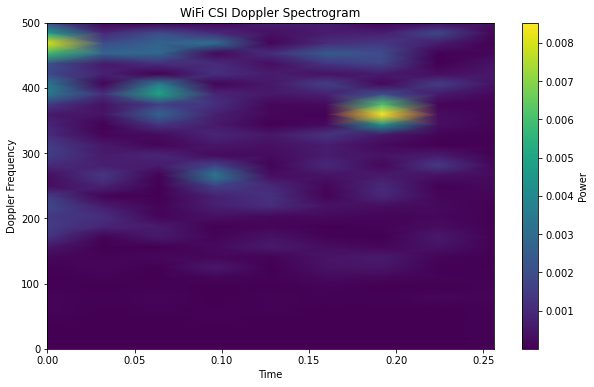

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# path to your dat file
file_path = r"D:/PROJECT/Dataset/wifi_dataset_own_mat/clap_p1_t1.mat"
# read raw bytes
with open(file_path, "rb") as f:
    raw = np.frombuffer(f.read(), dtype=np.uint8)

# convert bytes to pseudo CSI packets (simple grouping)
packet_size = 100   # approximate packet grouping
num_packets = len(raw) // packet_size

raw = raw[:num_packets * packet_size]
packets = raw.reshape(num_packets, packet_size)

# simulate subcarriers (30 typical for Intel 5300)
subcarriers = 30
csi_matrix = packets[:, :subcarriers]

# convert to complex signal
real = csi_matrix[:, ::2]
imag = csi_matrix[:, 1::2]

min_len = min(real.shape[1], imag.shape[1])
complex_csi = real[:, :min_len] + 1j * imag[:, :min_len]

# extract phase
phase = np.angle(complex_csi)

# remove phase wrapping
phase = np.unwrap(phase, axis=0)

# compute phase difference (Doppler sensitive)
phase_diff = np.diff(phase, axis=0)

# collapse subcarriers
doppler_signal = np.mean(phase_diff, axis=1)

# STFT
f, t, Zxx = stft(doppler_signal, fs=1000, nperseg=64)

spectrogram = np.abs(Zxx)**2

# plot
plt.figure(figsize=(10,6))
plt.pcolormesh(t, f, spectrogram, shading='gouraud')
plt.title("WiFi CSI Doppler Spectrogram")
plt.ylabel("Doppler Frequency")
plt.xlabel("Time")
plt.colorbar(label="Power")
plt.show()

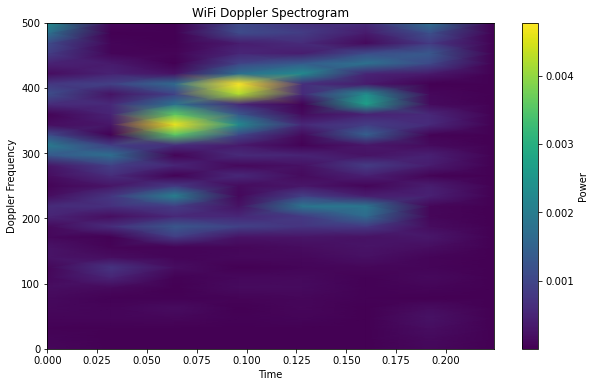

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# Load raw dat file
file_path = r"D:\PROJECT\Dataset\wifi dataset own\clap_p1_t1.dat"

with open(file_path, "rb") as f:
    raw = np.frombuffer(f.read(), dtype=np.uint8)

# approximate packet grouping
packet_len = 128
num_packets = len(raw) // packet_len

raw = raw[:num_packets * packet_len]
packets = raw.reshape(num_packets, packet_len)

# select first 30 values as subcarriers
csi = packets[:, :30]

# convert to complex CSI
real = csi[:, ::2]
imag = csi[:, 1::2]

min_len = min(real.shape[1], imag.shape[1])
csi_complex = real[:, :min_len] + 1j * imag[:, :min_len]

# extract phase
phase = np.angle(csi_complex)

# unwrap phase
phase = np.unwrap(phase, axis=0)

# phase difference
phase_diff = np.diff(phase, axis=0)

# combine subcarriers
signal = np.mean(phase_diff, axis=1)

# STFT
f, t, Z = stft(signal, fs=1000, nperseg=64)

doppler = np.abs(Z)**2

plt.figure(figsize=(10,6))
plt.pcolormesh(t, f, doppler, shading='gouraud')
plt.title("WiFi Doppler Spectrogram")
plt.xlabel("Time")
plt.ylabel("Doppler Frequency")
plt.colorbar(label="Power")
plt.show()

## after converting .dat to .mat using MATLAB

In [1]:
from scipy.io import loadmat
import numpy as np

data = loadmat(r"D:\PROJECT\Dataset\wifi_data_own_matlab\clap_p1_t1.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'csi_trace'])


## extract CSI matrix from packets

In [4]:
# csi_trace = data['csi_trace'][0]

# print(len(csi_trace))

csi_trace = data['csi_trace'][0,0]

print(type(csi_trace))
print(len(csi_trace))

<class 'numpy.ndarray'>
1


In [5]:
print(csi_trace.dtype)

[('timestamp_low', 'O'), ('bfee_count', 'O'), ('Nrx', 'O'), ('Ntx', 'O'), ('rssi_a', 'O'), ('rssi_b', 'O'), ('rssi_c', 'O'), ('noise', 'O'), ('agc', 'O'), ('perm', 'O'), ('rate', 'O'), ('csi', 'O')]


In [7]:
# packet = csi_trace[0]

# csi = packet['csi'][0,0]

# print(csi.shape)
packet = csi_trace[0]

csi = packet['csi']

print(type(csi))
print(np.shape(csi))

<class 'numpy.ndarray'>
(1,)


In [8]:
csi_matrix = csi[0]

print(type(csi_matrix))
print(csi_matrix.shape)

<class 'numpy.ndarray'>
(3, 3, 30)


## compute CSI amplitude

In [9]:
csi_amp = np.abs(csi_matrix)

print(csi_amp.shape)

(3, 3, 30)


## extract CSI amplitude across all packets

In [10]:
num_packets = len(csi_trace)

csi_amplitude = []

for i in range(num_packets):
    pkt = csi_trace[i]
    csi = pkt['csi'][0]
    
    amp = np.abs(csi)
    
    # choose antenna pair (Rx1, Tx1)
    csi_amplitude.append(amp[0,0,:])

csi_amplitude = np.array(csi_amplitude)

print(csi_amplitude.shape)

(1, 30)


In [12]:
print(type(csi_trace))
print(csi_trace.shape)
print(csi_trace)

<class 'numpy.ndarray'>
(1, 1)
[[(array([[2.74799658e+09]]), array([[7511]], dtype=uint16), array([[3]], dtype=uint8), array([[3]], dtype=uint8), array([[38]], dtype=uint8), array([[37]], dtype=uint8), array([[39]], dtype=uint8), array([[-84]], dtype=int16), array([[18]], dtype=uint8), array([[1, 3, 2]], dtype=uint8), array([[8471]], dtype=uint16), array([[[-42.+14.j, -27.+43.j,   8.+57.j,  45.+42.j,  64. +6.j,
            57.-33.j,  28.-62.j, -10.-69.j, -46.-53.j, -69.-20.j,
           -70.+20.j, -48.+55.j, -12.+74.j,  30.+71.j,  49.+60.j,
            75.+25.j,  75.-19.j,  56.-57.j,  18.-78.j, -28.-74.j,
           -65.-49.j, -81. -5.j, -72.+40.j, -35.+75.j,  16.+82.j,
            63.+55.j,  78. +5.j,  60.-44.j,  14.-66.j,  -8.-61.j],
          [  7. +1.j,   8. -4.j,   3. -8.j,  -2. -8.j,  -7. -4.j,
            -8. -1.j,  -8. +3.j,  -6. +6.j,  -4. +8.j,   1.+10.j,
             6.+10.j,  11. +6.j,  15. -1.j,  13.-10.j,  10.-13.j,
             1.-19.j,  -9.-18.j, -19.-11.j, -24. +2.j, -

In [13]:
import os
from scipy.io import loadmat

folder = r"D:\PROJECT\Dataset\wifi_data_own_matlab"

for file in os.listdir(folder):
    if file.endswith(".mat"):
        data = loadmat(os.path.join(folder, file))
        csi_trace = data['csi_trace']
        packets = csi_trace.size
        
        print(file, "-> packets:", packets)

clap_p1_t1.mat -> packets: 44
clap_p1_t2.mat -> packets: 45
clap_p1_t3.mat -> packets: 48
clap_p1_t4.mat -> packets: 40
clap_p1_t5.mat -> packets: 48
clap_p2_t1.mat -> packets: 44
clap_p2_t2.mat -> packets: 44
clap_p2_t3.mat -> packets: 52
clap_p2_t4.mat -> packets: 30
clap_p2_t5.mat -> packets: 45
jump_p1_t1.mat -> packets: 56
jump_p1_t2.mat -> packets: 53
jump_p1_t3.mat -> packets: 62
jump_p1_t4.mat -> packets: 21
jump_p1_t5.mat -> packets: 60
jump_p2_t1.mat -> packets: 42
jump_p2_t2.mat -> packets: 57
jump_p2_t3.mat -> packets: 44
jump_p2_t4.mat -> packets: 53
jump_p2_t5.mat -> packets: 49
sit_p1_t1.mat -> packets: 52
sit_p1_t2.mat -> packets: 39
sit_p1_t3.mat -> packets: 37
sit_p1_t4.mat -> packets: 35
sit_p1_t5.mat -> packets: 65
sit_p2_t1.mat -> packets: 49
sit_p2_t2.mat -> packets: 45
sit_p2_t3.mat -> packets: 50
sit_p2_t4.mat -> packets: 43
sit_p2_t5.mat -> packets: 61
walk_p1_t1.mat -> packets: 68
walk_p1_t2.mat -> packets: 65
walk_p1_t3.mat -> packets: 39
walk_p1_t4.mat -> pa

## Extract CSI amplitude correctly from all packets

In [17]:
print(type(data['csi_trace']))
print(data['csi_trace'].shape)
print(type(data['csi_trace'][0,0]))
print(len(data['csi_trace'][0,0]))

<class 'numpy.ndarray'>
(44, 1)
<class 'numpy.ndarray'>
1


In [24]:
print(csi_amp.shape)

(3, 3, 30)


In [25]:
from scipy.io import loadmat
import numpy as np

data = loadmat(r"D:\PROJECT\Dataset\wifi_data_own_matlab\clap_p1_t1.mat")

packets = data['csi_trace'][:,0]

csi_series = []

for pkt in packets:
    
    csi = pkt['csi']
    
    while isinstance(csi, np.ndarray) and csi.dtype == object:
        csi = csi[0]
    
    amp = np.abs(csi)
    
    # choose Rx1 Tx1 across all 30 subcarriers
    csi_series.append(amp[0,0,:])

csi_series = np.array(csi_series)

print(csi_series.shape)

(44, 30)


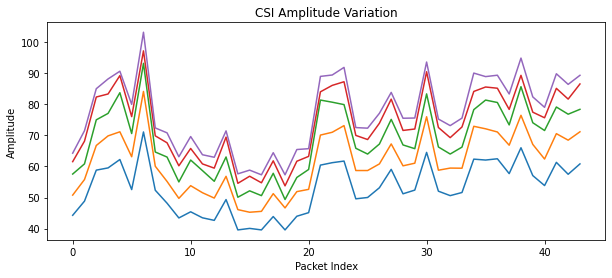

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for sc in range(5):   # plot first 5 subcarriers
    plt.plot(csi_series[:, sc])

plt.title("CSI Amplitude Variation")
plt.xlabel("Packet Index")
plt.ylabel("Amplitude")
plt.show()

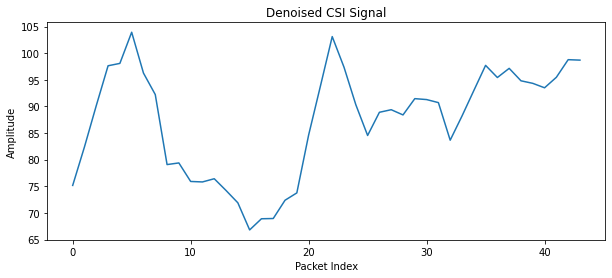

In [27]:
from scipy.ndimage import uniform_filter1d

denoised_signal = uniform_filter1d(csi_series[:,10], size=3)

plt.figure(figsize=(10,4))
plt.plot(denoised_signal)
plt.title("Denoised CSI Signal")
plt.xlabel("Packet Index")
plt.ylabel("Amplitude")
plt.show()

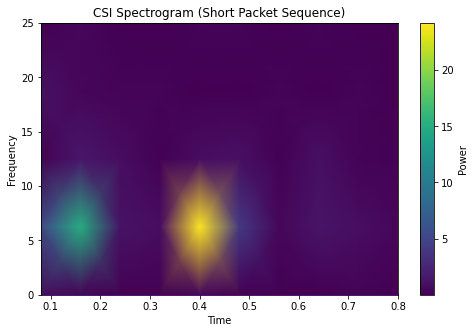

In [28]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

signal = denoised_signal

f, t, Sxx = spectrogram(
    signal,
    fs=50,        # sampling rate approximation
    nperseg=8,    # small window (important)
    noverlap=4
)

plt.figure(figsize=(8,5))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel("Frequency")
plt.xlabel("Time")
plt.title("CSI Spectrogram (Short Packet Sequence)")
plt.colorbar(label="Power")
plt.show()

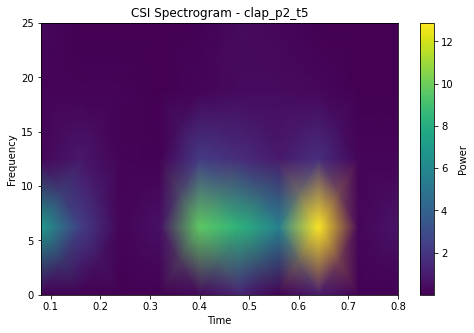

In [41]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy.signal import spectrogram

# ===== CHANGE ONLY THIS =====
trial = "clap_p2_t5"   
# ============================

file_path = rf"D:\PROJECT\Dataset\wifi_data_own_matlab\{trial}.mat"

data = loadmat(file_path)

packets = data['csi_trace'][:,0]

csi_series = []

for pkt in packets:
    
    csi = pkt['csi']
    
    while isinstance(csi, np.ndarray) and csi.dtype == object:
        csi = csi[0]
    
    amp = np.abs(csi)
    
    csi_series.append(amp[0,0,:])   # Rx1 Tx1

csi_series = np.array(csi_series)

# choose one subcarrier
signal = csi_series[:,10]

# denoise
signal = uniform_filter1d(signal, size=3)

# spectrogram
f, t, Sxx = spectrogram(
    signal,
    fs=50,
    nperseg=8,
    noverlap=4
)

plt.figure(figsize=(8,5))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel("Frequency")
plt.xlabel("Time")
plt.title(f"CSI Spectrogram - {trial}")
plt.colorbar(label="Power")
plt.show()

## Jump

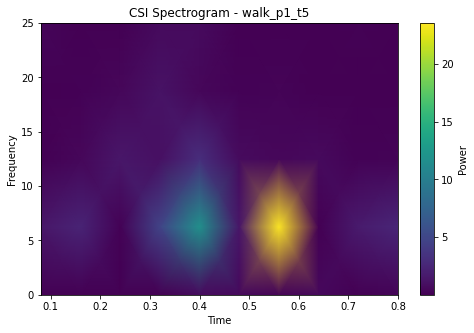

In [16]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy.signal import spectrogram

# ===== CHANGE ONLY THIS =====
trial = "walk_p1_t5"   
# ============================

file_path = rf"D:\PROJECT\Dataset\wifi_data_own_matlab\{trial}.mat"

data = loadmat(file_path)

packets = data['csi_trace'][:,0]

csi_series = []

for pkt in packets:
    
    csi = pkt['csi']
    
    while isinstance(csi, np.ndarray) and csi.dtype == object:
        csi = csi[0]
    
    amp = np.abs(csi)
    
    csi_series.append(amp[0,0,:])   # Rx1 Tx1

csi_series = np.array(csi_series)

# choose one subcarrier
signal = csi_series[:,10]

# denoise
signal = uniform_filter1d(signal, size=3)

# spectrogram
f, t, Sxx = spectrogram(
    signal,
    fs=50,
    nperseg=8,
    noverlap=4
)

plt.figure(figsize=(8,5))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel("Frequency")
plt.xlabel("Time")
plt.title(f"CSI Spectrogram - {trial}")
plt.colorbar(label="Power")
plt.show()   

## with phase extraction
## walk

CSI matrix shape: (68, 30)


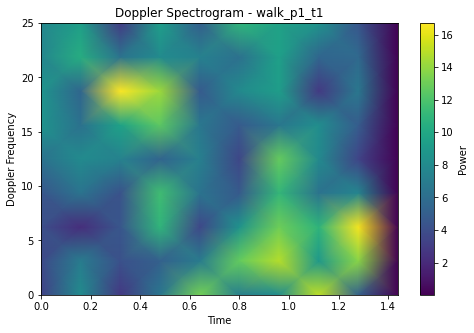

In [17]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# ===== CHANGE ONLY THIS =====
trial = "walk_p1_t1"
# ============================

file_path = rf"D:\PROJECT\Dataset\wifi_data_own_matlab\{trial}.mat"

data = loadmat(file_path)
packets = data['csi_trace'][:,0]

csi_series = []

# --------------------------------
# Step 1 — Build CSI matrix
# --------------------------------
for pkt in packets:

    csi = pkt['csi']

    while isinstance(csi, np.ndarray) and csi.dtype == object:
        csi = csi[0]

    csi_series.append(csi[0,0,:])   # choose Rx1–Tx1 antenna pair

csi_series = np.array(csi_series)

print("CSI matrix shape:", csi_series.shape)

# --------------------------------
# Step 2 — Extract phase
# --------------------------------
phase = np.angle(csi_series)

# --------------------------------
# Step 3 — Phase unwrap
# --------------------------------
phase_unwrapped = np.unwrap(phase, axis=0)

# --------------------------------
# Step 4 — Phase difference (important for Doppler)
# --------------------------------
phase_diff = np.diff(phase_unwrapped, axis=0)

# --------------------------------
# Step 5 — Remove static component
# --------------------------------
phase_dynamic = phase_diff - np.mean(phase_diff, axis=0)

# --------------------------------
# Step 6 — STFT for each subcarrier
# --------------------------------
doppler_matrix = []

for sc in range(phase_dynamic.shape[1]):

    signal = phase_dynamic[:, sc]

    f, t, Zxx = stft(signal, fs=50, nperseg=16)

    power = np.abs(Zxx)**2

    doppler_matrix.append(power)

doppler_matrix = np.array(doppler_matrix)

# --------------------------------
# Step 7 — Doppler phase shift vector
# (sum across subcarriers)
# --------------------------------
doppler_vector = np.sum(doppler_matrix, axis=0)

# --------------------------------
# Step 8 — Plot Doppler spectrogram
# --------------------------------
plt.figure(figsize=(8,5))

plt.pcolormesh(t, f, doppler_vector, shading='gouraud')

plt.xlabel("Time")
plt.ylabel("Doppler Frequency")
plt.title(f"Doppler Spectrogram - {trial}")

plt.colorbar(label="Power")

plt.show()

## jump

CSI matrix shape: (53, 30)


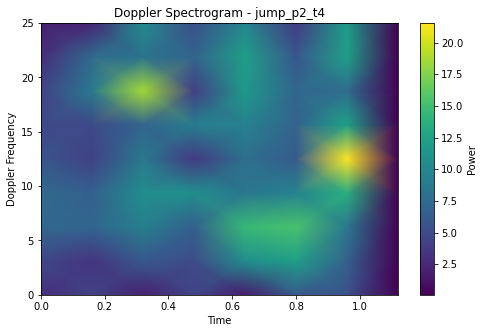

In [14]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# ===== CHANGE ONLY THIS =====
trial = "jump_p2_t4"
# ============================

file_path = rf"D:\PROJECT\Dataset\wifi_data_own_matlab\{trial}.mat"

data = loadmat(file_path)
packets = data['csi_trace'][:,0]

csi_series = []

# --------------------------------
# Step 1 — Build CSI matrix
# --------------------------------
for pkt in packets:

    csi = pkt['csi']

    while isinstance(csi, np.ndarray) and csi.dtype == object:
        csi = csi[0]

    csi_series.append(csi[0,0,:])   # choose Rx1–Tx1 antenna pair

csi_series = np.array(csi_series)

print("CSI matrix shape:", csi_series.shape)

# --------------------------------
# Step 2 — Extract phase
# --------------------------------
phase = np.angle(csi_series)

# --------------------------------
# Step 3 — Phase unwrap
# --------------------------------
phase_unwrapped = np.unwrap(phase, axis=0)

# --------------------------------
# Step 4 — Phase difference (important for Doppler)
# --------------------------------
phase_diff = np.diff(phase_unwrapped, axis=0)

# --------------------------------
# Step 5 — Remove static component
# --------------------------------
phase_dynamic = phase_diff - np.mean(phase_diff, axis=0)

# --------------------------------
# Step 6 — STFT for each subcarrier
# --------------------------------
doppler_matrix = []

for sc in range(phase_dynamic.shape[1]):

    signal = phase_dynamic[:, sc]

    f, t, Zxx = stft(signal, fs=50, nperseg=16)

    power = np.abs(Zxx)**2

    doppler_matrix.append(power)

doppler_matrix = np.array(doppler_matrix)

# --------------------------------
# Step 7 — Doppler phase shift vector
# (sum across subcarriers)
# --------------------------------
doppler_vector = np.sum(doppler_matrix, axis=0)

# --------------------------------
# Step 8 — Plot Doppler spectrogram
# --------------------------------
plt.figure(figsize=(8,5))

plt.pcolormesh(t, f, doppler_vector, shading='gouraud')

plt.xlabel("Time")
plt.ylabel("Doppler Frequency")
plt.title(f"Doppler Spectrogram - {trial}")

plt.colorbar(label="Power")

plt.show()

## clap

CSI matrix shape: (44, 30)


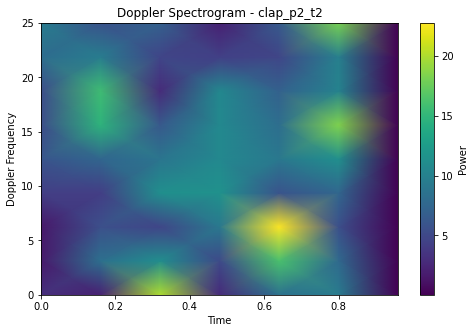

In [3]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# ===== CHANGE ONLY THIS =====
trial = "clap_p2_t2"
# ============================

file_path = rf"D:\PROJECT\Dataset\wifi_data_own_matlab\{trial}.mat"

data = loadmat(file_path)
packets = data['csi_trace'][:,0]

csi_series = []

# --------------------------------
# Step 1 — Build CSI matrix
# --------------------------------
for pkt in packets:

    csi = pkt['csi']

    while isinstance(csi, np.ndarray) and csi.dtype == object:
        csi = csi[0]

    csi_series.append(csi[0,0,:])   # choose Rx1–Tx1 antenna pair

csi_series = np.array(csi_series)

print("CSI matrix shape:", csi_series.shape)

# --------------------------------
# Step 2 — Extract phase
# --------------------------------
phase = np.angle(csi_series)

# --------------------------------
# Step 3 — Phase unwrap
# --------------------------------
phase_unwrapped = np.unwrap(phase, axis=0)

# --------------------------------
# Step 4 — Phase difference (important for Doppler)
# --------------------------------
phase_diff = np.diff(phase_unwrapped, axis=0)

# --------------------------------
# Step 5 — Remove static component
# --------------------------------
phase_dynamic = phase_diff - np.mean(phase_diff, axis=0)

# --------------------------------
# Step 6 — STFT for each subcarrier
# --------------------------------
doppler_matrix = []

for sc in range(phase_dynamic.shape[1]):

    signal = phase_dynamic[:, sc]

    f, t, Zxx = stft(signal, fs=50, nperseg=16)

    power = np.abs(Zxx)**2

    doppler_matrix.append(power)

doppler_matrix = np.array(doppler_matrix)

# --------------------------------
# Step 7 — Doppler phase shift vector
# (sum across subcarriers)
# --------------------------------
doppler_vector = np.sum(doppler_matrix, axis=0)

# --------------------------------
# Step 8 — Plot Doppler spectrogram
# --------------------------------
plt.figure(figsize=(8,5))

plt.pcolormesh(t, f, doppler_vector, shading='gouraud')

plt.xlabel("Time")
plt.ylabel("Doppler Frequency")
plt.title(f"Doppler Spectrogram - {trial}")

plt.colorbar(label="Power")

plt.show()

## sit

CSI matrix shape: (35, 30)


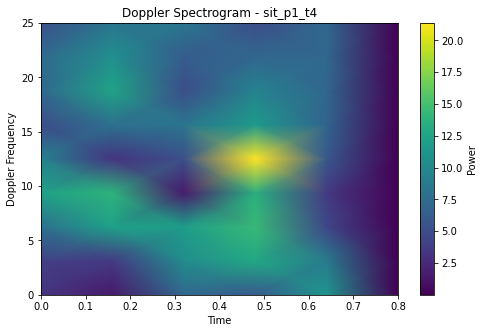

In [11]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# ===== CHANGE ONLY THIS =====
trial = "sit_p1_t4"
# ============================

file_path = rf"D:\PROJECT\Dataset\wifi_data_own_matlab\{trial}.mat"

data = loadmat(file_path)
packets = data['csi_trace'][:,0]

csi_series = []

# --------------------------------
# Step 1 — Build CSI matrix
# --------------------------------
for pkt in packets:

    csi = pkt['csi']

    while isinstance(csi, np.ndarray) and csi.dtype == object:
        csi = csi[0]

    csi_series.append(csi[0,0,:])   # choose Rx1–Tx1 antenna pair

csi_series = np.array(csi_series)

print("CSI matrix shape:", csi_series.shape)

# --------------------------------
# Step 2 — Extract phase
# --------------------------------
phase = np.angle(csi_series)

# --------------------------------
# Step 3 — Phase unwrap
# --------------------------------
phase_unwrapped = np.unwrap(phase, axis=0)

# --------------------------------
# Step 4 — Phase difference (important for Doppler)
# --------------------------------
phase_diff = np.diff(phase_unwrapped, axis=0)

# --------------------------------
# Step 5 — Remove static component
# --------------------------------
phase_dynamic = phase_diff - np.mean(phase_diff, axis=0)

# --------------------------------
# Step 6 — STFT for each subcarrier
# --------------------------------
doppler_matrix = []

for sc in range(phase_dynamic.shape[1]):

    signal = phase_dynamic[:, sc]

    f, t, Zxx = stft(signal, fs=50, nperseg=16)

    power = np.abs(Zxx)**2

    doppler_matrix.append(power)

doppler_matrix = np.array(doppler_matrix)

# --------------------------------
# Step 7 — Doppler phase shift vector
# (sum across subcarriers)
# --------------------------------
doppler_vector = np.sum(doppler_matrix, axis=0)

# --------------------------------
# Step 8 — Plot Doppler spectrogram
# --------------------------------
plt.figure(figsize=(8,5))

plt.pcolormesh(t, f, doppler_vector, shading='gouraud')

plt.xlabel("Time")
plt.ylabel("Doppler Frequency")
plt.title(f"Doppler Spectrogram - {trial}")

plt.colorbar(label="Power")

plt.show()